# 시나리오 롤링 파이프라인 — AR → CatBoost / TFT 3-way 비교

**목표**: AR 점예측을 기준으로 (1) **AR**, (2) **AR+CatBoost**(잔차 보정), (3) **AR+TFT**(Temporal Fusion Transformer, 잔차 보정) 세 가지의 12개월 예측 성능을 전체 5개의 롤링 윈도우에서 비교한다.

**TFT 변수 설계 (매우 중요)**
- 학습 단위(group)는 **Header 식별자(구·동·단지명·평형) + 롤링 원점**으로 잡아 매물별 잔차 궤적을 하나의 series로 구성한다.
- TFT의 **Variable Selection Network(VSN)** 가 나머지 feature(거시·지역 depth 수치, 정적 범주)들의 **상관성**을 학습하도록 변수를 배치한다.
  - `static_categoricals` = Header(구·동·단지명·평형) + Static 범주피처
  - `time_varying_known_reals` = h_step · base_drift · 원점추세 + 실현시점 거시/지역 depth 수치
  - `target` = `resid_target` (AR h스텝 로그오차) — CatBoost와 동일 잔차 타깃으로 공정 비교
- 캐시(`output/module0_cache`, `output/AR_vs_catboost`)를 재사용해 데이터 적재·잔차 학습세트 빌드를 가속한다.


In [2]:
# --- [Windows/인코딩 필수 설정 — 다른 import 보다 먼저] ---
import os
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")
os.environ.setdefault("PYTHONUTF8", "1")
os.environ.setdefault("PYTHONIOENCODING", "utf-8:replace")
os.environ.setdefault("PYTHONWARNINGS", "ignore")

import re
import sys
import glob
import json
import time
import warnings
from dataclasses import dataclass, field, asdict
from pathlib import Path
from typing import Dict, List, Optional, Tuple

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from scipy import stats

import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams["font.family"] = "Malgun Gothic"
matplotlib.rcParams["axes.unicode_minus"] = False

from catboost import CatBoostRegressor, Pool


def detect_catboost_task_type() -> str:
    """CatBoost GPU(CUDA) 가용 여부 자동 감지. CUDA GPU가 보이면 'GPU', 아니면 'CPU'."""
    try:
        from catboost.utils import get_gpu_device_count
        n = get_gpu_device_count()
        return "GPU" if n and n > 0 else "CPU"
    except Exception:
        return "CPU"


CATBOOST_TASK_TYPE = detect_catboost_task_type()
print(f"[env] python={sys.version.split()[0]}  numpy={np.__version__}  pandas={pd.__version__}")
print(f"[env] CatBoost task_type = {CATBOOST_TASK_TYPE}"
      + ("  (CUDA GPU 감지됨)" if CATBOOST_TASK_TYPE == "GPU" else "  (CUDA 없음 → CPU)"))


# ===== TFT / Lightning 추가 임포트 =====
import torch
import lightning.pytorch as pl
from lightning.pytorch.callbacks import EarlyStopping
from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer
from pytorch_forecasting.data import GroupNormalizer
from pytorch_forecasting.data.encoders import NaNLabelEncoder
from pytorch_forecasting.metrics import RMSE as TFT_RMSE

TFT_ACCELERATOR = "gpu" if torch.cuda.is_available() else "cpu"
try:
    pl.seed_everything(42, workers=True)
except Exception:
    pass
print(f"[env] torch={torch.__version__}  CUDA={torch.cuda.is_available()}  TFT_ACCELERATOR={TFT_ACCELERATOR}")


[env] python=3.11.3  numpy=2.4.6  pandas=2.3.3
[env] CatBoost task_type = CPU  (CUDA 없음 → CPU)


Seed set to 42


[env] torch=2.4.1+cpu  CUDA=False  TFT_ACCELERATOR=cpu


## 설정 — GlobalConfig + AR 고정 + TFT 하이퍼파라미터

In [3]:
# 워크스페이스 루트 자동 탐지 (노트북 cwd가 ml_pipeline/final/ 이어도 동작)
def _find_workspace_root() -> str:
    p = Path.cwd().resolve()
    for cand in [p, *p.parents]:
        if (cand / "meta_ml" / "output").exists():
            return str(cand)
    return str(p)


WORKSPACE_ROOT = _find_workspace_root()


@dataclass
class GlobalConfig:
    # ---- 경로 ----
    PANEL_ROOT: str = os.path.join(WORKSPACE_ROOT, "meta_ml", "output", "서울특별시")   # 전체 단지 패널 루트
    OUT_ROOT: str = os.path.join(WORKSPACE_ROOT, "ml_pipeline", "final", "output_final")  # 모든 단계 산출물 저장 루트
    CACHE_SRC: str = os.path.join(WORKSPACE_ROOT, "ml_pipeline", "final", "output", "module0_cache")  # 기존 패널 캐시 재사용원

    # ---- 롤링 윈도우 (예측창 시작월; 각 8년 학습 → 12개월 예측) ----
    # "뒷구간 96개월 학습" = 예측창 직전 8년을 학습구간으로.
    BT_STARTS: tuple = ("2025-06-01", "2024-06-01", "2023-06-01", "2022-06-01", "2021-06-01")
    TRAIN_YEARS: int = 8          # 96개월
    HORIZON: int = 12             # 예측 12개월(1년)

    # ---- 데이터 가드 ----
    MIN_TRAIN_MONTHS: int = 36    # 36개월 미만이면 시계열/계절성 추정 불안정 → 드롭

    # ---- 타깃 변환 ----
    LOG_TARGET: bool = True       # 로그공간: 이분산 완화 + 음수가격 차단

    # ---- AR (베이스라인 후보 & B* 점예측) ----
    AR_MAX_LAG: int = 12          # 월 데이터 → 1년 상한. 과대차수는 분산팽창
    AR_IC: str = "aic"            # 차수 선택: 'aic'(예측지향)
    SEASONAL_PERIOD: int = 12     # 월별 계절 주기

    # ---- CatBoost (전역 잔차 학습) — Phase 3 튜닝 결과 반영 ----
    CB_ITERATIONS: int = 3000     # [Phase3 튜닝확정] 부스팅 라운드(early stopping과 함께 상한). 작은 lr 보완
    CB_LEARNING_RATE: float = 0.03  # [Phase3 튜닝확정] + 많은 iter = 일반화 안정
    CB_DEPTH: int = 8             # 트리 깊이. 횡단면 상호작용 포착(6→8 상향)
    CB_L2_LEAF_REG: float = 3.0   # [Phase3 튜닝확정] 정규화(과적합 억제)
    CB_EARLY_STOP: int = 80       # 검증 손실 정체 라운드
    CB_RANDOM_SEED: int = 42
    CB_BORDER_COUNT: int = 254    # 수치 분할 경계 수(정밀도)
    CB_BAGGING_TEMPERATURE: float = 1.0  # 베이esian bagging 다양성
    CB_RANDOM_STRENGTH: float = 1.0      # 분할 점수 잡음(과적합 억제)
    PANEL_AR_MAX_LAG: int = 6     # 전역 패널 잔차 산출용 AR 최대차수
    ORIGIN_STRIDE: int = 12       # h스텝 오차 학습: 롤링 예측원점 간격(개월)
    INCLUDE_HSTEP_FEATURE: bool = True  # 예측지평 h를 피처로 추가
    AR_FORECAST_GUARD: float = 3.0   # AR 외삽 안정 가드(로그 ±3.0 초과 발산 원점 제외)
    ERR_CLIP_LOG: float = 1.0        # h스텝 로그오차 |e|>1.0(≈±172%) 이상치 제외

    # ---- BAR-X (Bayesian AR-X + Minnesota prior) ----
    BARX_MAX_LAG: int = 4
    MINNESOTA_LAMBDA: float = 0.2
    MINNESOTA_THETA: float = 0.5
    BARX_FREEZE_EXOG: bool = True

    # ---- 부트스트랩 (밴드 — 파이프라인 마지막) ----
    N_BOOTSTRAP: int = 1000
    BLOCK_SIZE: int = 3           # 블록 길이(개월) — 자기상관 보존
    QUANTILES: tuple = (0.1, 0.5, 0.9)
    BOOTSTRAP_SEED: int = 42
    PI_ALPHA: float = 0.2         # 80% 예측구간 → α=0.2 (Interval Score용)

    # ---- Fat-tail (Student-t 꼬리) + 이항 시나리오 자동산정 ----
    FAT_TAIL: bool = True
    T_DF_INIT: float = 5.0
    TAIL_PROB: float = 0.05
    EXTREME_QUANTILE: float = 0.98
    EXTREME_K_MIN: int = 30
    CONFIDENCE: float = 0.99
    HARD_FLOOR_N: int = 200

    # ---- 현실성 필터 ----
    REALISM_MAX_MOM: float = 0.25
    REALISM_DROP: bool = True

    # ---- SHAP ----
    SHAP_PER_GU: int = 500        # 구별 표집 수 → 25구 × 500 = 12,500 point

    # ---- 피처 선택 ----
    FEATURE_DROP_THRESHOLD: float = 0.005

    # ---- Phase 3 튜닝 목표 ----
    CATBOOST_WAPE_GAIN_TARGET: float = 0.10  # B*+CatBoost 가 B* 대비 평균 WAPE 10%↑ 우수

    # ---- 식별자(피처 아님) ----
    HEADER_COLS: tuple = ("Header_시", "Header_구", "Header_동", "Header_Timestamp", "Header_단지명", "Header_평형")
    TARGET_COL: str = "target"
    TIME_COL: str = "Header_Timestamp"


CFG = GlobalConfig()


def log_dir(name: str) -> str:
    """단계·모델명 폴더 생성 후 절대경로 반환 (중간결과 로그 저장용)."""
    d = os.path.join(CFG.OUT_ROOT, name)
    os.makedirs(d, exist_ok=True)
    return d


# 윈도우 객체 생성 (예측창 시작월 → 8년 학습 + 12개월 예측)
def _mk_window(bt_start: str, train_years: int = None, bt_months: int = None) -> dict:
    train_years = CFG.TRAIN_YEARS if train_years is None else train_years
    bt_months = CFG.HORIZON if bt_months is None else bt_months
    bs = pd.Timestamp(bt_start)
    w = {"name": f"BT@{bs:%Y-%m}",
         "tr_start": bs - pd.DateOffset(years=train_years),
         "tr_end":   bs - pd.DateOffset(months=1),
         "bt_start": bs,
         "bt_end":   bs + pd.DateOffset(months=bt_months - 1)}
    w["label"] = f"{w['tr_start']:%Y-%m}~{w['tr_end']:%Y-%m} → {w['bt_start']:%Y-%m}~{w['bt_end']:%Y-%m}"
    return w


BT_WINDOWS = [_mk_window(s) for s in CFG.BT_STARTS]
for i, _m in enumerate(["module0_cache", "baseline", "shap", "viz"]):
    log_dir(_m)

print("[cfg] 롤링 윈도우 (8년 학습 → 12개월 예측):")
for i, w in enumerate(BT_WINDOWS, 1):
    print(f"  BT{i}: {w['label']}")
print(f"[cfg] 산출물 루트: {CFG.OUT_ROOT}")
print(f"[cfg] CatBoost task_type: {CATBOOST_TASK_TYPE}")


# ===== AR 고정 + TFT 하이퍼파라미터 (이 노트북 전용) =====
B_STAR = "AR"                       # 이 노트북은 베이스라인을 AR로 고정 (AR → CatBoost / TFT 비교)
GROUP_KEYS = ["Header_구", "Header_동", "Header_단지명", "Header_평형"]

# TFT 설정 (CPU 학습 고려한 경량 기본값)
CFG.TFT_MAX_EPOCHS = 20
CFG.TFT_HIDDEN = 16
CFG.TFT_ATTN_HEADS = 2
CFG.TFT_DROPOUT = 0.1
CFG.TFT_HIDDEN_CONT = 8
CFG.TFT_LR = 0.02
CFG.TFT_BATCH = 128
CFG.TFT_MAX_TRAIN_SERIES = 1500     # CPU 속도 위해 윈도우당 학습 series 상한
CFG.TFT_EARLY_STOP = 4
CFG.TFT_SEED = 42

# 평가 대상 / 해석(SHAP·VSN) 설정
CFG.EVAL_MAX_GROUPS = None          # 백테스트 평가 대상 단지×평형 상한 (None=전체). 빠른 시험 시 정수 지정
CFG.SHAP_SAMPLE_ROWS = 20000        # CatBoost SHAP 계산 표본 행수(윈도우별)
CFG.VSN_SAMPLE_SERIES = 2000        # TFT VSN 해석 표본 series 수(윈도우별)

print(f"[cfg] B* 고정 = {B_STAR}  | TFT epochs={CFG.TFT_MAX_EPOCHS} hidden={CFG.TFT_HIDDEN} "
      f"max_series={CFG.TFT_MAX_TRAIN_SERIES}")


[cfg] 롤링 윈도우 (8년 학습 → 12개월 예측):
  BT1: 2017-06~2025-05 → 2025-06~2026-05
  BT2: 2016-06~2024-05 → 2024-06~2025-05
  BT3: 2015-06~2023-05 → 2023-06~2024-05
  BT4: 2014-06~2022-05 → 2022-06~2023-05
  BT5: 2013-06~2021-05 → 2021-06~2022-05
[cfg] 산출물 루트: C:\Users\equip\Desktop\homework\apartment_prediction2\ml_pipeline\final\output_final
[cfg] CatBoost task_type: CPU
[cfg] B* 고정 = AR  | TFT epochs=20 hidden=16 max_series=1500


## depth 라벨 파싱 — 피처 그룹화

In [4]:
DEPTH_PATTERNS = {
    "D1_Macro":    re.compile(r"^depth1__"),
    "D2_Region":   re.compile(r"^depth2__"),
    "D3_RegionGu": re.compile(r"^depth3__"),
    "Static":      re.compile(r"^Static__"),
}


def group_columns(columns: List[str]) -> Dict[str, List[str]]:
    """컬럼명을 의미 그룹으로 분류. Header_/target 은 어디에도 넣지 않는다."""
    groups: Dict[str, List[str]] = {k: [] for k in DEPTH_PATTERNS}
    groups["Header"] = []; groups["Target"] = []
    for c in columns:
        if c == CFG.TARGET_COL:
            groups["Target"].append(c); continue
        if c.startswith("Header_"):
            groups["Header"].append(c); continue
        matched = False
        for g, pat in DEPTH_PATTERNS.items():
            if pat.match(c):
                groups[g].append(c); matched = True; break
        if not matched:
            groups.setdefault("Other", []).append(c)
    return groups


def feature_columns(columns: List[str]) -> Tuple[List[str], List[str]]:
    """CatBoost 입력용 (수치피처=D1+D2+D3, 범주피처=Static). Header/target 제외."""
    g = group_columns(columns)
    numeric = g["D1_Macro"] + g["D2_Region"] + g["D3_RegionGu"]
    categorical = g["Static"]
    return numeric, categorical


# Static 중 본래 수치형(역세권수·호재수)은 numeric으로 처리
STATIC_NUMERIC_HINT = {"Static__역세권수", "Static__호재수"}
print("[parse] depth 그룹 정규식 준비:", list(DEPTH_PATTERNS.keys()))


[parse] depth 그룹 정규식 준비: ['D1_Macro', 'D2_Region', 'D3_RegionGu', 'Static']


## 데이터 라우팅 — KB 선도 50 패널 + 전역 패널 (캐시 재사용)

In [5]:
# ===== 데이터 라우팅 — 보유 전체 아파트×평형 패널 (KB 선도 50 필터 제거) =====
# [요청 2] 선도 50단지가 아닌, 가지고 있는 전체 아파트+평형 데이터를 백테스트 대상으로 사용한다.
def load_all_panel(cutoff_end=None) -> pd.DataFrame:
    """meta_ml 전체 단지×평형 패널 적재. cutoff_end 지정 시 Header_Timestamp <= cutoff 만."""
    paths = glob.glob(os.path.join(CFG.PANEL_ROOT, "*", "*", "*.csv"))
    frames = []
    cutoff = pd.to_datetime(cutoff_end) if cutoff_end else None
    for p in paths:
        try:
            d = pd.read_csv(p, encoding="utf-8-sig")
        except Exception:
            continue
        if len(d) == 0 or CFG.TIME_COL not in d.columns or CFG.TARGET_COL not in d.columns:
            continue
        d[CFG.TIME_COL] = pd.to_datetime(d[CFG.TIME_COL])
        if cutoff is not None:
            d = d[d[CFG.TIME_COL] <= cutoff]
        if len(d):
            frames.append(d)
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()


_cache = log_dir("module0_cache")  # output_final/module0_cache
# 전체 패널(모든 아파트×평형, 전체 기간). 기존 output/module0_cache 캐시가 있으면 재사용.
_all_cache = os.path.join(_cache, "panel_all_full.pkl")
_legacy_full = os.path.join(CFG.CACHE_SRC, "global_panel_full.pkl")
if os.path.exists(_all_cache):
    panel_all = pd.read_pickle(_all_cache)
    print(f"[route] 전체 패널 캐시 로드: {panel_all.shape[0]:,}행")
elif os.path.exists(_legacy_full):
    panel_all = pd.read_pickle(_legacy_full)
    panel_all[CFG.TIME_COL] = pd.to_datetime(panel_all[CFG.TIME_COL])
    panel_all.to_pickle(_all_cache)
    print(f"[route] 기존 output 전체 패널 재사용 → output_final 캐시: {panel_all.shape[0]:,}행")
else:
    panel_all = load_all_panel(None)
    panel_all.to_pickle(_all_cache)
    print(f"[route] 전체 패널 적재·캐시: {panel_all.shape[0]:,}행")

_n_apt = panel_all[["Header_구", "Header_동", "Header_단지명"]].drop_duplicates().shape[0]
_n_pyeong = panel_all[GROUP_KEYS].drop_duplicates().shape[0]
print(f"[route] 전체: 단지 {_n_apt:,}개 · 단지×평형 {_n_pyeong:,}개 · "
      f"기간 {panel_all[CFG.TIME_COL].min().date()}~{panel_all[CFG.TIME_COL].max().date()}")
print(f"[route] 예상 분석 수 ≈ 단지×평형({_n_pyeong:,}) × {len(BT_WINDOWS)}윈도우 = "
      f"{_n_pyeong*len(BT_WINDOWS):,} (드롭 전)")

# 학습용 전역 패널 = 전체 패널에서 최대 tr_end 이하 (누수 차단)
_max_tr_end = max(w["tr_end"] for w in BT_WINDOWS)
panel_full = panel_all[panel_all[CFG.TIME_COL] <= _max_tr_end].reset_index(drop=True)
print(f"[route] 학습용 전역 패널(≤{_max_tr_end:%Y-%m}): {panel_full.shape[0]:,}행")


[route] 전체 패널 캐시 로드: 2,046,245행
[route] 전체: 단지 2,558개 · 단지×평형 11,302개 · 기간 2010-01-01~2026-05-01
[route] 예상 분석 수 ≈ 단지×평형(11,302) × 5윈도우 = 56,510 (드롭 전)
[route] 학습용 전역 패널(≤2025-05): 1,897,274행


## AR 베이스라인 · 지표 · 로그공간 변환

In [6]:
from statsmodels.tsa.ar_model import AutoReg

# ---- 점예측 지표 (원단위 만원) ----
def rmse(y_true, y_pred) -> float:
    y_true, y_pred = np.asarray(y_true, float), np.asarray(y_pred, float)
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))


def wape(y_true, y_pred) -> float:
    y_true, y_pred = np.asarray(y_true, float), np.asarray(y_pred, float)
    denom = np.sum(np.abs(y_true))
    return float(np.sum(np.abs(y_true - y_pred)) / denom) if denom > 0 else np.nan


# ---- 로그공간 변환 ----
def to_model_space(y):
    y = np.asarray(y, float); return np.log(y) if CFG.LOG_TARGET else y


def to_price_space(z):
    z = np.asarray(z, float); return np.exp(z) if CFG.LOG_TARGET else z


def get_target_series(df: pd.DataFrame) -> pd.Series:
    return df.set_index(CFG.TIME_COL)[CFG.TARGET_COL].astype(float).sort_index()


# ---- 거시 외생(BAR-X 용) ----
EXOG_COLS = ["depth1__ecos__base_rate", "depth1__ecos__cd_91d_rate", "depth1__ecos__cpi_housing",
             "depth1__ecos__m2_avg", "depth1__ecos__mortgage_rate_new", "depth1__ecos__unemployment_rate"]


def get_exog_array(df: pd.DataFrame) -> np.ndarray:
    return (df.sort_values(CFG.TIME_COL)[EXOG_COLS]
            .apply(pd.to_numeric, errors="coerce").ffill().bfill().fillna(0.0).values)


# ---- AR 차수 선택 / 예측 ----
def fit_select_ar(train_z: np.ndarray, max_lag: int, ic: str):
    n = len(train_z); usable_max = min(max_lag, n // 3)
    best_p, best_ic, scores = 1, np.inf, {}
    for p in range(1, max(2, usable_max + 1)):
        try:
            res = AutoReg(train_z, lags=p, old_names=False).fit()
            val = res.aic if ic == "aic" else res.bic
            scores[p] = val
            if val < best_ic:
                best_ic, best_p = val, p
        except Exception:
            continue
    return best_p, scores


def forecast_ar(train_z, p, horizon):
    res = AutoReg(train_z, lags=p, old_names=False).fit()
    return np.asarray(res.predict(start=len(train_z), end=len(train_z) + horizon - 1), float)


def forecast_seasonal_naive(train_z, horizon, m):
    out = np.empty(horizon)
    for h in range(horizon):
        idx = len(train_z) - m + (h % m)
        out[h] = train_z[idx] if idx >= 0 else train_z[-1]
    return out


# ---- BAR / BAR-X : Bayesian AR(-X) + Minnesota prior (Theil mixed) ----
def _barx_design(z, Xex, p):
    n = len(z); rows = n - p; cols = 1 + p + Xex.shape[1]
    X = np.empty((rows, cols)); X[:, 0] = 1.0
    for i in range(1, p + 1):
        X[:, i] = z[p - i: n - i]
    X[:, 1 + p:] = Xex[p:]
    return X, z[p:]


def fit_barx_minnesota(z, Xex, p, lam, theta):
    X, y = _barx_design(z, Xex, p); k = X.shape[1]
    beta_ols, *_ = np.linalg.lstsq(X, y, rcond=None)
    sigma2 = float(np.mean((y - X @ beta_ols) ** 2)) or 1e-6
    m = np.zeros(k); m[1] = 1.0
    V = np.empty(k); V[0] = 1e6 * sigma2
    for i in range(1, p + 1):
        V[i] = (lam / i) ** 2
    if Xex.shape[1] > 0:
        sx = Xex[p:].std(axis=0); sx[sx == 0] = 1.0
        V[1 + p:] = (lam * theta) ** 2 * sigma2 / (sx ** 2)
    Dinv = np.diag(1.0 / V)
    A = X.T @ X + sigma2 * Dinv
    b = X.T @ y + sigma2 * (Dinv @ m)
    return np.linalg.solve(A, b), float(sigma2), y - X @ np.linalg.solve(A, b)


def forecast_barx(beta, z_hist, x_frozen, p, H):
    c = beta[0]; phi = beta[1:1 + p]; bx = beta[1 + p:]
    hist = list(z_hist[-p:])
    exog_term = float(bx @ x_frozen) if len(bx) else 0.0
    out = []
    for _ in range(H):
        zf = c + exog_term + sum(phi[i] * hist[-1 - i] for i in range(p))
        out.append(zf); hist.append(zf)
    return np.asarray(out, float)


BASELINE_MODELS = ["RandomWalk", "SeasonalNaive", "AR"]


def _guard_clip(fc, last):
    g = CFG.AR_FORECAST_GUARD
    return np.clip(np.asarray(fc, float), last - g, last + g)


def base_forecast_log(name, z_tr, horizon, exog_tr=None, p_ar=None):
    """단일 베이스라인의 horizon-스텝 로그 점예측(가드 클립)."""
    last = z_tr[-1]
    if name == "RandomWalk":
        return np.repeat(last, horizon)
    if name == "SeasonalNaive":
        return forecast_seasonal_naive(z_tr, horizon, CFG.SEASONAL_PERIOD)
    if name == "AR":
        p = min(p_ar if p_ar else 1, max(1, len(z_tr) // 3))
        try:
            return _guard_clip(forecast_ar(z_tr, p, horizon), last)
        except Exception:
            return np.repeat(last, horizon)
    if name in ("BAR", "BAR-X"):
        p = min(CFG.BARX_MAX_LAG, max(1, len(z_tr) // 3))
        if name == "BAR":
            Xex = np.zeros((len(z_tr), 0)); xf = np.zeros(0)
        else:
            Xex = exog_tr; xf = exog_tr[-1]
        try:
            beta, _, _ = fit_barx_minnesota(z_tr, Xex, p, CFG.MINNESOTA_LAMBDA, CFG.MINNESOTA_THETA)
            return _guard_clip(forecast_barx(beta, z_tr, xf, p, horizon), last)
        except Exception:
            return np.repeat(last, horizon)
    raise ValueError(f"unknown baseline: {name}")


print("[phase1] 지표/변환/베이스라인 3종 준비:", BASELINE_MODELS)


[phase1] 지표/변환/베이스라인 3종 준비: ['RandomWalk', 'SeasonalNaive', 'AR']


## Phase 1-B. 베이스라인 3종 평가 (RandomWalk · SeasonalNaive · AR)

`scenario_rolling_pipeline.ipynb` 와 동일하게, 보유 **전체 아파트×평형 × 5 롤링 윈도우**에서 생성된 **모든 시나리오**에 대해
세 가지를 함께 보고한다.
1. **평균 WAPE·RMSE** : 분석 케이스 전체 단순평균(평균적으로 얼마나 정확한가).
2. **우위 카운트** : 윈도우×단지·평형 조합별 승자(지표 최소)를 세어 합산(몇 번 이겼나).
3. **step별 거리 우위** : 모든 분석의 모든 step(월)에서 3종 중 실제값과 가장 가까운 모델을 카운트(어느 step에서 우위인가).


[phase1-B] 11,302개 단지·평형 × 5윈도우 평가 완료 → 153,801행

=== (1) 분석 케이스 전체 평균 RMSE·WAPE (총 51,267 윈도우×단지·평형) ===
  RandomWalk      평균RMSE      7,267.1   평균WAPE   0.0420
  SeasonalNaive   평균RMSE     11,844.6   평균WAPE   0.0751
  AR              평균RMSE     10,656.5   평균WAPE   0.0688

=== (2) 우위 카운트 (윈도우×단지·평형 조합별 승자, 총 51,267) ===
  RandomWalk      WAPE우위 33,100 (64.6%)   RMSE우위 32,374 (63.1%)
  SeasonalNaive   WAPE우위    575 ( 1.1%)   RMSE우위    791 ( 1.5%)
  AR              WAPE우위 17,592 (34.3%)   RMSE우위 18,102 (35.3%)

=== (2-b) 윈도우별 WAPE 우위 카운트 ===
  BT@2025-06: RandomWalk 3,903 | SeasonalNaive 48 | AR 6,608
  BT@2024-06: RandomWalk 5,865 | SeasonalNaive 152 | AR 4,405
  BT@2023-06: RandomWalk 8,633 | SeasonalNaive 145 | AR 1,496
  BT@2022-06: RandomWalk 9,676 | SeasonalNaive 226 | AR 249
  BT@2021-06: RandomWalk 5,023 | SeasonalNaive 4 | AR 4,834

=== (3) step별 거리 우위 (모든 분석의 모든 월에서 실제값 최근접 모델, 총 615,204 step) ===
  RandomWalk       403,011 step (65.5%)
  SeasonalNaive     18,755 step ( 3.0%)


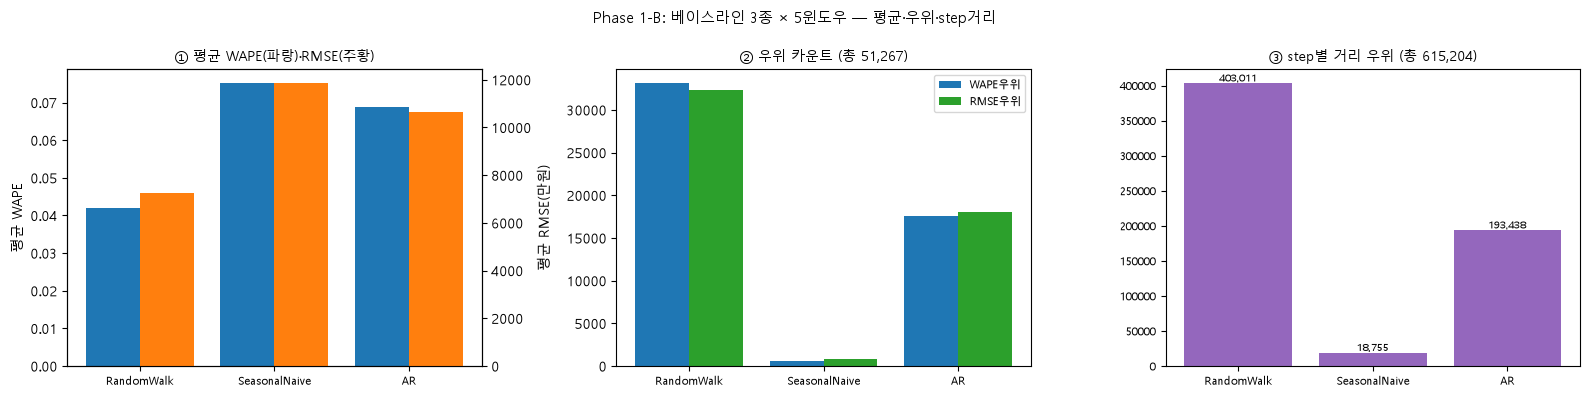

[phase1-B] 저장: C:\Users\equip\Desktop\homework\apartment_prediction2\ml_pipeline\final\output_final\baseline


In [7]:
# ===== Phase 1-B. 전체 아파트×평형 × 5 롤링 윈도우 베이스라인 3종 평가 =====
_BASE_DIR = log_dir("baseline")


def evaluate_baselines_windows(panel: pd.DataFrame, max_groups=None):
    """전체 단지×평형 × 5윈도우. 각 윈도우: 8년 train 적합 → H개월 단일원점 예측 → RMSE/WAPE.
    동시에 모든 step(월)에서 3종 중 실제값과 가장 가까운 모델(거리우위)을 카운트.
    반환: (long_df[윈도우·단지·모델·RMSE·WAPE], stepwise_wins{모델:점수}, total_steps, n_groups)."""
    rows = []
    stepwise_wins = {m: 0 for m in BASELINE_MODELS}
    total_steps = 0
    n_groups = 0
    BT = CFG.HORIZON
    for keyvals, g in panel.groupby(GROUP_KEYS, sort=False):
        if max_groups is not None and n_groups >= max_groups:
            break
        n_groups += 1
        g = g.sort_values(CFG.TIME_COL)
        t = g[CFG.TIME_COL]
        gid = "|".join(str(x) for x in keyvals)
        for w in BT_WINDOWS:
            tr = g[(t >= w["tr_start"]) & (t <= w["tr_end"])]
            bt = g[(t >= w["bt_start"]) & (t <= w["bt_end"])]
            ytr = tr[CFG.TARGET_COL].astype(float).values
            ybt = bt[CFG.TARGET_COL].astype(float).values
            if len(tr) < CFG.MIN_TRAIN_MONTHS or len(bt) < BT:
                continue
            if np.any(ytr <= 0) or np.any(ybt <= 0):
                continue
            z_tr = np.log(ytr) if CFG.LOG_TARGET else ytr
            exog_tr = get_exog_array(tr)
            y_true = ybt[:BT]
            try:
                p_star = fit_select_ar(z_tr, CFG.AR_MAX_LAG, CFG.AR_IC)[0]
            except Exception:
                p_star = 1
            preds = {}
            for m in BASELINE_MODELS:
                try:
                    zp = base_forecast_log(m, z_tr, BT, exog_tr=exog_tr, p_ar=p_star)
                except Exception:
                    continue
                yp = to_price_space(zp)
                preds[m] = yp
                rows.append({"윈도우": w["name"], "단지": gid, "모델": m,
                             "RMSE": rmse(y_true, yp), "WAPE": wape(y_true, yp)})
            # --- step별 거리 우위: 각 월에서 |실제-예측| 최소 모델 +1 ---
            if len(preds) == len(BASELINE_MODELS):
                dist = np.vstack([np.abs(y_true - preds[m]) for m in BASELINE_MODELS])  # (3, H)
                for wi in np.argmin(dist, axis=0):
                    stepwise_wins[BASELINE_MODELS[wi]] += 1
                total_steps += len(y_true)
    return pd.DataFrame(rows), stepwise_wins, total_steps, n_groups


def win_counts_keyed(df_long, metric, keys):
    wins = {}
    for _, gg in df_long.groupby(keys):
        w = gg.loc[gg[metric].idxmin(), "모델"]
        wins[w] = wins.get(w, 0) + 1
    return wins


base_df, stepwise_wins, total_steps, _ng = evaluate_baselines_windows(panel_all, CFG.EVAL_MAX_GROUPS)
base_df.to_csv(os.path.join(_BASE_DIR, "baseline_windows_all.csv"), index=False, encoding="utf-8-sig")
print(f"[phase1-B] {_ng:,}개 단지·평형 × {len(BT_WINDOWS)}윈도우 평가 완료 → {len(base_df):,}행")

# --- (1) 전체 평균 RMSE·WAPE ---
_finite = base_df.replace([np.inf, -np.inf], np.nan)
avg_table = _finite.groupby("모델")[["RMSE", "WAPE"]].mean().reindex(BASELINE_MODELS)
n_cases = base_df.groupby(["윈도우", "단지"]).ngroups
print(f"\n=== (1) 분석 케이스 전체 평균 RMSE·WAPE (총 {n_cases:,} 윈도우×단지·평형) ===")
for m in BASELINE_MODELS:
    print(f"  {m:14s}  평균RMSE {avg_table.loc[m,'RMSE']:>12,.1f}   평균WAPE {avg_table.loc[m,'WAPE']:>8.4f}")

# --- (2) 우위 카운트 (WAPE·RMSE; 윈도우×단지 조합별 승자) ---
wins_wape = win_counts_keyed(base_df, "WAPE", ["윈도우", "단지"])
wins_rmse = win_counts_keyed(base_df, "RMSE", ["윈도우", "단지"])
print(f"\n=== (2) 우위 카운트 (윈도우×단지·평형 조합별 승자, 총 {n_cases:,}) ===")
for m in BASELINE_MODELS:
    print(f"  {m:14s}  WAPE우위 {wins_wape.get(m,0):>6,} ({wins_wape.get(m,0)/max(n_cases,1):5.1%})   "
          f"RMSE우위 {wins_rmse.get(m,0):>6,} ({wins_rmse.get(m,0)/max(n_cases,1):5.1%})")

# --- (2-b) 윈도우별 WAPE 우위 카운트 ---
print(f"\n=== (2-b) 윈도우별 WAPE 우위 카운트 ===")
win_rows = []
for w in BT_WINDOWS:
    sub = base_df[base_df["윈도우"] == w["name"]]
    wc = win_counts_keyed(sub, "WAPE", ["단지"]) if len(sub) else {}
    row = {"윈도우": w["name"], **{m: wc.get(m, 0) for m in BASELINE_MODELS}}
    win_rows.append(row)
    print(f"  {w['name']}: " + " | ".join(f"{m} {wc.get(m,0):,}" for m in BASELINE_MODELS))
pd.DataFrame(win_rows).to_csv(os.path.join(_BASE_DIR, "baseline_win_counts_by_window.csv"),
                              index=False, encoding="utf-8-sig")

# --- (3) step별 거리 우위 ---
print(f"\n=== (3) step별 거리 우위 (모든 분석의 모든 월에서 실제값 최근접 모델, 총 {total_steps:,} step) ===")
for m in BASELINE_MODELS:
    print(f"  {m:14s}  {stepwise_wins.get(m,0):>8,} step ({stepwise_wins.get(m,0)/max(total_steps,1):5.1%})")

_best_wape = max(BASELINE_MODELS, key=lambda m: (wins_wape.get(m, 0), -avg_table.loc[m, "WAPE"]))
print(f"\n[phase1-B] WAPE 우위 최다 베이스라인 = {_best_wape}  (B*는 AR로 고정)")

# --- 로그/지표 저장 ---
avg_table.to_csv(os.path.join(_BASE_DIR, "baseline_avg_metrics.csv"), encoding="utf-8-sig")
pd.DataFrame({"모델": BASELINE_MODELS,
              "WAPE우위": [wins_wape.get(m, 0) for m in BASELINE_MODELS],
              "RMSE우위": [wins_rmse.get(m, 0) for m in BASELINE_MODELS],
              "step거리우위": [stepwise_wins.get(m, 0) for m in BASELINE_MODELS]}).to_csv(
    os.path.join(_BASE_DIR, "baseline_win_counts.csv"), index=False, encoding="utf-8-sig")

# --- 시각화 (① 평균 WAPE/RMSE · ② 우위 카운트 · ③ step 거리 우위) ---
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
xp = np.arange(len(BASELINE_MODELS))
axr = ax[0].twinx()
ax[0].bar(xp - 0.2, [avg_table.loc[m, "WAPE"] for m in BASELINE_MODELS], 0.4, color="tab:blue", label="WAPE")
axr.bar(xp + 0.2, [avg_table.loc[m, "RMSE"] for m in BASELINE_MODELS], 0.4, color="tab:orange", label="RMSE")
ax[0].set_xticks(xp); ax[0].set_xticklabels(BASELINE_MODELS, fontsize=8)
ax[0].set_ylabel("평균 WAPE"); axr.set_ylabel("평균 RMSE(만원)")
ax[0].set_title("① 평균 WAPE(파랑)·RMSE(주황)", fontsize=10)
ax[1].bar(xp - 0.2, [wins_wape.get(m, 0) for m in BASELINE_MODELS], 0.4, color="tab:blue", label="WAPE우위")
ax[1].bar(xp + 0.2, [wins_rmse.get(m, 0) for m in BASELINE_MODELS], 0.4, color="tab:green", label="RMSE우위")
ax[1].set_xticks(xp); ax[1].set_xticklabels(BASELINE_MODELS, fontsize=8)
ax[1].set_title(f"② 우위 카운트 (총 {n_cases:,})", fontsize=10); ax[1].legend(fontsize=8)
ax[2].bar(BASELINE_MODELS, [stepwise_wins.get(m, 0) for m in BASELINE_MODELS], color="tab:purple")
ax[2].set_title(f"③ step별 거리 우위 (총 {total_steps:,})", fontsize=10)
ax[2].tick_params(labelsize=8)
for r in ax[2].patches:
    ax[2].text(r.get_x() + r.get_width()/2, r.get_height(), f"{int(r.get_height()):,}",
               ha="center", va="bottom", fontsize=7)
plt.suptitle(f"Phase 1-B: 베이스라인 3종 × {len(BT_WINDOWS)}윈도우 — 평균·우위·step거리", fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(_BASE_DIR, "baseline_selection.png"), dpi=110, bbox_inches="tight")
plt.show()
print(f"[phase1-B] 저장: {_BASE_DIR}")


## 피처 정의 + h스텝 잔차 학습세트 빌더 + CatBoost

In [8]:
# ===== Phase 2-A. 피처 정의 + h스텝 오차 학습세트 빌더 =====
HSTEP_COL = "h_step"
ORIGIN_FEATS = ["base_drift", "origin_last", "origin_mom3", "origin_mom6", "origin_mom12"]


def split_features(columns: List[str]) -> Tuple[List[str], List[str]]:
    num, cat = feature_columns(columns)
    cat_final = [c for c in cat if c not in STATIC_NUMERIC_HINT]
    num_final = num + [c for c in cat if c in STATIC_NUMERIC_HINT]
    return num_final, cat_final


_num0, CAT_FEATS = split_features(list(panel_all.columns))
NUM_FEATS = _num0 + ([HSTEP_COL] if CFG.INCLUDE_HSTEP_FEATURE else []) + ORIGIN_FEATS
print(f"[feat] 수치피처 {len(NUM_FEATS)}개  | 범주피처 {len(CAT_FEATS)}개: {CAT_FEATS}")


def build_hstep_trainset(panel: pd.DataFrame, b_star: str) -> pd.DataFrame:
    """패널 각 단지×평형에서 롤링 원점 B* → h스텝 예측오차를 타깃으로. 피처=실현시점 거시/정적+h_step+원점추세."""
    out_frames = []
    n_groups = n_used = 0
    H = CFG.HORIZON
    for _, g in panel.groupby(GROUP_KEYS, sort=False):
        n_groups += 1
        g = g.sort_values(CFG.TIME_COL).reset_index(drop=True)
        y = g[CFG.TARGET_COL].astype(float).values
        n = len(g)
        if n < CFG.MIN_TRAIN_MONTHS + 1 or np.any(y <= 0):
            continue
        z = np.log(y) if CFG.LOG_TARGET else y
        Xex_g = get_exog_array(g)
        p_c = fit_select_ar(z, CFG.PANEL_AR_MAX_LAG, CFG.AR_IC)[0] if b_star == "AR" else None
        used_this = False
        for t0 in range(CFG.MIN_TRAIN_MONTHS, n - 1, CFG.ORIGIN_STRIDE):
            z_tr = z[:t0]
            hmax = min(H, n - 1 - t0)
            if hmax < 1:
                continue
            try:
                fc = base_forecast_log(b_star, z_tr, hmax, exog_tr=Xex_g[:t0], p_ar=p_c)
            except Exception:
                continue
            fc = np.asarray(fc, float)
            if not np.all(np.isfinite(fc)):
                continue
            if np.max(np.abs(fc - z_tr[-1])) > CFG.AR_FORECAST_GUARD:
                continue
            idx_future = np.arange(t0, t0 + hmax)
            err = z[idx_future] - fc
            drift = fc - z_tr[-1]
            keep = np.abs(err) <= CFG.ERR_CLIP_LOG
            if not np.any(keep):
                continue
            idx_future, err, drift = idx_future[keep], err[keep], drift[keep]
            rows = g.iloc[idx_future].copy()
            rows[HSTEP_COL] = (idx_future - t0 + 1)
            rows["resid_target"] = err
            last = z_tr[-1]
            rows["base_drift"]   = drift
            rows["origin_last"]  = last
            rows["origin_mom3"]  = (last - z_tr[-4])  if len(z_tr) >= 4  else 0.0
            rows["origin_mom6"]  = (last - z_tr[-7])  if len(z_tr) >= 7  else 0.0
            rows["origin_mom12"] = (last - z_tr[-13]) if len(z_tr) >= 13 else 0.0
            out_frames.append(rows)
            used_this = True
        if used_this:
            n_used += 1
    res_df = pd.concat(out_frames, ignore_index=True) if out_frames else pd.DataFrame()
    print(f"    [resid] B*={b_star} | 그룹 {n_groups:,}개 중 {n_used:,}개 사용 → h스텝 오차샘플 {len(res_df):,}")
    return res_df


def _prep_features(df: pd.DataFrame) -> pd.DataFrame:
    """CatBoost 입력 정리: categorical=문자열+결측'NA', numeric=float."""
    X = df[NUM_FEATS + CAT_FEATS].copy()
    for c in CAT_FEATS:
        X[c] = X[c].astype("object").where(X[c].notna(), "NA").astype(str)
    for c in NUM_FEATS:
        X[c] = pd.to_numeric(X[c], errors="coerce")
    return X


def make_catboost() -> CatBoostRegressor:
    """현재 CFG.CB_* 로 CatBoostRegressor 생성 (Phase 3 튜닝과 공유)."""
    return CatBoostRegressor(
        iterations=CFG.CB_ITERATIONS, learning_rate=CFG.CB_LEARNING_RATE, depth=CFG.CB_DEPTH,
        l2_leaf_reg=CFG.CB_L2_LEAF_REG, border_count=CFG.CB_BORDER_COUNT,
        bagging_temperature=CFG.CB_BAGGING_TEMPERATURE, random_strength=CFG.CB_RANDOM_STRENGTH,
        loss_function="RMSE", random_seed=CFG.CB_RANDOM_SEED, task_type=CATBOOST_TASK_TYPE,
        od_type="Iter", od_wait=CFG.CB_EARLY_STOP, verbose=False)


def train_catboost(ts: pd.DataFrame, verbose=False):
    """h스텝 학습세트 → 시간기반 hold-out(마지막 12개월) early stopping → (모델, X_va, y_va, mask)."""
    _cut = ts[CFG.TIME_COL].max() - pd.DateOffset(months=12)
    m = ts[CFG.TIME_COL] <= _cut
    Xtr = _prep_features(ts[m]);  ytr = ts.loc[m, "resid_target"].values
    Xva = _prep_features(ts[~m]); yva = ts.loc[~m, "resid_target"].values
    ci = [Xtr.columns.get_loc(c) for c in CAT_FEATS]
    cb = make_catboost()
    if verbose:
        cb.set_params(verbose=200)
    cb.fit(Pool(Xtr, ytr, cat_features=ci), eval_set=Pool(Xva, yva, cat_features=ci), use_best_model=True)
    return cb, Xva, yva, ~m


print("[phase2] 빌더 준비: build_hstep_trainset, _prep_features, make_catboost, train_catboost")


[feat] 수치피처 24개  | 범주피처 5개: ['Static__준공구분', 'Static__세대수구분', 'Static__평수구분', 'Static__건설사등급', 'Static__초품아여부']
[phase2] 빌더 준비: build_hstep_trainset, _prep_features, make_catboost, train_catboost


## Phase 3. 윈도우별 precompute (AR 점예측 + 피처)

In [9]:
# ===== Phase 3-A. precompute(AR 기준): 윈도우별 h스텝 학습세트 + 전체 아파트 AR 점예측·피처 =====
# 학습세트(누수차단)는 output_final/AR_vs_catboost 에 캐시(H 변경 시 자동 재빌드).
_bstar_tag = B_STAR.replace("-", "").replace("/", "")
_VS_DIR = log_dir(f"{_bstar_tag}_vs_catboost")
_TARGET, _TIME = CFG.TARGET_COL, CFG.TIME_COL


def build_window_trainset(tr_end):
    """tr_end 이하 전역 패널 → h스텝 학습세트(캐시). 누수 없음."""
    cache = os.path.join(_VS_DIR, f"hstep_trainset_{_bstar_tag}_{tr_end:%Y-%m}.pkl")
    if os.path.exists(cache):
        ts = pd.read_pickle(cache)
        print(f"    [resid] 캐시 로드 ≤{tr_end:%Y-%m}: {len(ts):,}행")
        return ts
    sub = panel_full[panel_full[_TIME] <= tr_end]
    ts = build_hstep_trainset(sub, B_STAR)
    ts.to_pickle(cache)
    return ts


def precompute_window(panel, w, max_groups=None):
    """전체 단지×평형: 윈도우 w의 AR 점예측 + CatBoost 입력 피처(Xprep) + TFT용 원본피처(feat_raw)."""
    H = CFG.HORIZON
    tr_lo, tr_hi = w["tr_start"], w["tr_end"]
    te_lo, te_hi = w["bt_start"], w["bt_end"]
    items = []
    n_seen = 0
    for keyvals, g in panel.groupby(GROUP_KEYS, sort=False):
        if max_groups is not None and n_seen >= max_groups:
            break
        n_seen += 1
        g = g.sort_values(_TIME).reset_index(drop=True)
        t = g[_TIME]
        tr = g[(t >= tr_lo) & (t <= tr_hi)]
        te = g[(t >= te_lo) & (t <= te_hi)].head(H)
        ytr = tr[_TARGET].astype(float).values
        yte = te[_TARGET].astype(float).values
        if len(tr) < CFG.MIN_TRAIN_MONTHS or len(te) < H or np.any(ytr <= 0) or np.any(yte <= 0):
            continue
        z_tr = np.log(ytr) if CFG.LOG_TARGET else ytr
        last = z_tr[-1]
        exog_tr = get_exog_array(tr)
        try:
            p_c = fit_select_ar(z_tr, CFG.AR_MAX_LAG, CFG.AR_IC)[0] if B_STAR == "AR" else None
            base_log = base_forecast_log(B_STAR, z_tr, H, exog_tr=exog_tr, p_ar=p_c)
        except Exception:
            continue
        if not np.all(np.isfinite(base_log)):
            continue
        feat = te.copy()
        feat[HSTEP_COL]      = np.arange(1, H + 1)
        feat["base_drift"]   = base_log - last
        feat["origin_last"]  = last
        feat["origin_mom3"]  = (last - z_tr[-4])  if len(z_tr) >= 4  else 0.0
        feat["origin_mom6"]  = (last - z_tr[-7])  if len(z_tr) >= 7  else 0.0
        feat["origin_mom12"] = (last - z_tr[-13]) if len(z_tr) >= 13 else 0.0
        items.append({
            "윈도우": w["name"], "단지": "|".join(str(x) for x in keyvals),
            "Xprep": _prep_features(feat), "feat_raw": feat.reset_index(drop=True),
            "base_log": base_log, "last": last,
            "yte": yte, "dates": pd.to_datetime(te[_TIME].values),
            "before_price": to_price_space(base_log),
        })
    return items


WIN_TRAINSETS = {}
WIN_ITEMS = {}
for w in BT_WINDOWS:
    print(f"[phase3-A] {w['name']}  {w['label']}")
    WIN_TRAINSETS[w["name"]] = build_window_trainset(w["tr_end"])
    WIN_ITEMS[w["name"]] = precompute_window(panel_all, w, max_groups=CFG.EVAL_MAX_GROUPS)
    print(f"    → 분석 케이스 {len(WIN_ITEMS[w['name']]):,}개")

_n_total = sum(len(v) for v in WIN_ITEMS.values())
before_wape = np.mean([wape(it["yte"], it["before_price"]) for v in WIN_ITEMS.values() for it in v])
before_rmse = np.mean([rmse(it["yte"], it["before_price"]) for v in WIN_ITEMS.values() for it in v])
print(f"\n[phase3-A] 분석 케이스 총 {_n_total:,}개  |  AR 평균 WAPE={before_wape:.4f}  RMSE={before_rmse:,.1f}")

# 베이스라인(AR) 윈도우별 지표 저장
_base_rows = [{"윈도우": w["name"], "분석수": len(WIN_ITEMS[w["name"]]),
               "AR_WAPE": np.mean([wape(it["yte"], it["before_price"]) for it in WIN_ITEMS[w["name"]]]) if WIN_ITEMS[w["name"]] else np.nan,
               "AR_RMSE": np.mean([rmse(it["yte"], it["before_price"]) for it in WIN_ITEMS[w["name"]]]) if WIN_ITEMS[w["name"]] else np.nan}
              for w in BT_WINDOWS]
pd.DataFrame(_base_rows).to_csv(os.path.join(log_dir("baseline"), "ar_baseline_by_window.csv"),
                                index=False, encoding="utf-8-sig")
print(f"[phase3-A] AR 베이스라인 지표 저장: {log_dir('baseline')}")


[phase3-A] BT@2025-06  2017-06~2025-05 → 2025-06~2026-05
    [resid] B*=AR | 그룹 11,104개 중 10,537개 사용 → h스텝 오차샘플 1,498,203
    → 분석 케이스 10,559개
[phase3-A] BT@2024-06  2016-06~2024-05 → 2024-06~2025-05
    [resid] 캐시 로드 ≤2024-05: 1,359,873행
    → 분석 케이스 10,422개
[phase3-A] BT@2023-06  2015-06~2023-05 → 2023-06~2024-05
    [resid] 캐시 로드 ≤2023-05: 1,223,790행
    → 분석 케이스 10,274개
[phase3-A] BT@2022-06  2014-06~2022-05 → 2022-06~2023-05
    [resid] 캐시 로드 ≤2022-05: 1,089,309행
    → 분석 케이스 10,151개
[phase3-A] BT@2021-06  2013-06~2021-05 → 2021-06~2022-05
    [resid] 캐시 로드 ≤2021-05: 957,788행
    → 분석 케이스 9,861개

[phase3-A] 분석 케이스 총 51,267개  |  AR 평균 WAPE=0.0688  RMSE=10,656.5
[phase3-A] AR 베이스라인 지표 저장: C:\Users\equip\Desktop\homework\apartment_prediction2\ml_pipeline\final\output_final\baseline


In [16]:
# ===== Phase 3-B. 윈도우별 CatBoost (캐시 재사용, 누수 차단) → AR / AR+CatBoost 점예측 =====
# 저장된 .cbm 캐시가 있으면 재학습하지 않고 로드한다(전체 재학습 회피). FORCE_RETRAIN_CB=True 로 강제 재학습.
_CB_DIR = log_dir(f"{_bstar_tag}_catboost")
FORCE_RETRAIN_CB = False
CB_BY_WINDOW = {}
for w in BT_WINDOWS:
    wn = w["name"]
    ts = WIN_TRAINSETS[wn]
    _cb_path = os.path.join(_CB_DIR, f"catboost_{_bstar_tag}_{wn}.cbm")
    if (not FORCE_RETRAIN_CB) and os.path.exists(_cb_path):
        cb_w = make_catboost(); cb_w.load_model(_cb_path)
        print(f"[phase3-B] {wn} CatBoost 캐시 로드: {os.path.basename(_cb_path)}")
    else:
        cb_w, _, _, _ = train_catboost(ts, verbose=False)
        cb_w.save_model(_cb_path)
        print(f"[phase3-B] {wn} CatBoost 재학습 best_iter={cb_w.get_best_iteration()} (학습 {len(ts):,}행)")
    CB_BY_WINDOW[wn] = cb_w

# 점예측: 윈도우별로 전체 아이템 Xprep 을 한 번에 배치 predict (속도)
for w in BT_WINDOWS:
    cb_w = CB_BY_WINDOW[w["name"]]
    items = WIN_ITEMS[w["name"]]
    if not items:
        continue
    big = pd.concat([it["Xprep"] for it in items], ignore_index=True)
    resid_hat = cb_w.predict(big)
    H = CFG.HORIZON
    for k, it in enumerate(items):
        rh = resid_hat[k * H:(k + 1) * H]
        it["pred_AR"] = it["before_price"]
        it["pred_ARCB"] = to_price_space(it["base_log"] + rh)
print(f"[phase3-B] AR · AR+CatBoost 점예측 저장 완료 · 모델: {_CB_DIR}")


[phase3-B] BT@2025-06 CatBoost 캐시 로드: catboost_AR_BT@2025-06.cbm
[phase3-B] BT@2024-06 CatBoost 캐시 로드: catboost_AR_BT@2024-06.cbm
[phase3-B] BT@2023-06 CatBoost 캐시 로드: catboost_AR_BT@2023-06.cbm
[phase3-B] BT@2022-06 CatBoost 캐시 로드: catboost_AR_BT@2022-06.cbm
[phase3-B] BT@2021-06 CatBoost 캐시 로드: catboost_AR_BT@2021-06.cbm
[phase3-B] AR · AR+CatBoost 점예측 저장 완료 · 모델: C:\Users\equip\Desktop\homework\apartment_prediction2\ml_pipeline\final\output_final\AR_catboost


## Phase 4. AR + TFT (Temporal Fusion Transformer) — Header 기준 그룹 학습

TFT는 AR의 h스텝 잔차(`resid_target`)를 예측한다(= CatBoost와 **동일 타깃**으로 공정 비교). 각 (Header 식별자, 롤링 원점) 궤적을 하나의 series로 구성하고, 윈도우별로 **별도 학습(누수 차단)** 한다. VSN(Variable Selection Network)이 거시·지역·정적 feature 간 **상관성**을 학습한다.


In [15]:
# ===== Phase 4-A. TFT 변수 설정 + 데이터셋/학습/예측 빌더 =====
# [매우 중요] 학습은 "Header(구·동·단지명·평형) 식별자" 기준으로 그룹핑하고,
#  나머지 feature(거시·지역 depth 수치 + 정적 범주)들의 상관성을 TFT의
#  Variable Selection Network(VSN)가 학습하도록 변수를 배치한다.
#   - group_ids               : Header 식별자 + 롤링 원점 → 매물 단위 잔차 궤적(series)
#   - static_categoricals     : Header 구·동·단지명·평형 + Static 범주피처
#   - time_varying_known_reals: h_step · base_drift · 원점추세 + 실현시점 거시/지역 depth 수치
#   - target                  : resid_target (AR h스텝 로그오차)
MACRO_REALS = [c for c in NUM_FEATS if c != HSTEP_COL and c not in ORIGIN_FEATS]
TFT_STATIC_CAT = ["Header_구", "Header_동", "Header_단지명", "Header_평형"] + CAT_FEATS
TFT_KNOWN_REALS = [HSTEP_COL, "base_drift", "origin_last", "origin_mom3", "origin_mom6",
                   "origin_mom12"] + MACRO_REALS
print(f"[tft] group=Header+원점 | static_cat {len(TFT_STATIC_CAT)}개 | "
      f"known_reals {len(TFT_KNOWN_REALS)}개 (거시/지역 {len(MACRO_REALS)})")


def _coerce_tft(df):
    """TFT 입력 정리: 범주=문자열(결측 'NA'), 수치=float(결측 0), target=float."""
    for c in TFT_STATIC_CAT:
        df[c] = df[c].astype("object").where(df[c].notna(), "NA").astype(str)
    for c in TFT_KNOWN_REALS:
        df[c] = pd.to_numeric(df[c], errors="coerce").astype(float).fillna(0.0)
    df["resid_target"] = pd.to_numeric(df["resid_target"], errors="coerce").astype(float).fillna(0.0)
    df["time_idx"] = df["time_idx"].astype(int)
    return df


def make_tft_train_df(ts):
    """h스텝 잔차 학습세트 → (Header|원점) series + 앵커행(time_idx=0, resid=0)."""
    d = ts.copy()
    d["h_step"] = d[HSTEP_COL].astype(int)
    realized = pd.to_datetime(d[CFG.TIME_COL]).dt.to_period("M")
    origin = (realized - d["h_step"]).astype(str)
    gid = d[GROUP_KEYS].astype(str).agg("|".join, axis=1)
    d["series_id"] = gid + "|" + origin
    d["time_idx"] = d["h_step"].astype(int)
    cols = ["series_id", "time_idx", "resid_target"] + TFT_STATIC_CAT + TFT_KNOWN_REALS
    base = d[cols].copy()
    anc = base.sort_values("time_idx").groupby("series_id", as_index=False).first()
    anc["time_idx"] = 0
    anc["resid_target"] = 0.0
    anc[HSTEP_COL] = 0.0
    anc["base_drift"] = 0.0
    out = pd.concat([anc, base], ignore_index=True)
    return _coerce_tft(out)


def make_tft_predict_df(items):
    """KB50 윈도우 아이템 → 예측용 series (time_idx 0..H, 길이 H+1)."""
    frames = []
    for it in items:
        f = it["feat_raw"].copy()
        f["h_step"] = f[HSTEP_COL].astype(int)
        f["time_idx"] = f["h_step"].astype(int)
        f["resid_target"] = 0.0
        f["series_id"] = it["단지"] + "@" + it["윈도우"]
        cols = ["series_id", "time_idx", "resid_target"] + TFT_STATIC_CAT + TFT_KNOWN_REALS
        base = f[cols].copy()
        anc = base.sort_values("time_idx").head(1).copy()
        anc["time_idx"] = 0
        anc["resid_target"] = 0.0
        anc[HSTEP_COL] = 0.0
        anc["base_drift"] = 0.0
        frames.append(pd.concat([anc, base], ignore_index=True))
    return _coerce_tft(pd.concat(frames, ignore_index=True))


def _new_tft_model(training):
    """현재 CFG.TFT_* 로 TFT architecture 생성 (학습/캐시로드 공유)."""
    return TemporalFusionTransformer.from_dataset(
        training, hidden_size=CFG.TFT_HIDDEN, attention_head_size=CFG.TFT_ATTN_HEADS,
        dropout=CFG.TFT_DROPOUT, hidden_continuous_size=CFG.TFT_HIDDEN_CONT, output_size=1,
        loss=TFT_RMSE(), learning_rate=CFG.TFT_LR, log_interval=0, reduce_on_plateau_patience=3)


def build_tft_training(ts):
    """train_tft 와 동일한 학습 데이터셋(TimeSeriesDataSet)을 결정적으로 재현(학습 없음).
    캐시(.pt) 로드 시 동일 encoder/embedding 구조를 맞추기 위해 사용."""
    df = make_tft_train_df(ts)
    sids = df["series_id"].unique()
    if len(sids) > CFG.TFT_MAX_TRAIN_SERIES:
        rng = np.random.default_rng(CFG.TFT_SEED)
        keep = set(rng.choice(sids, CFG.TFT_MAX_TRAIN_SERIES, replace=False))
        df = df[df["series_id"].isin(keep)].copy()
        sids = df["series_id"].unique()
    rng = np.random.default_rng(CFG.TFT_SEED + 1)
    val_ids = set(rng.choice(sids, max(1, int(0.2 * len(sids))), replace=False))
    tr_df = df[~df["series_id"].isin(val_ids)].copy()
    va_df = df[df["series_id"].isin(val_ids)].copy()
    cat_enc = {k: NaNLabelEncoder(add_nan=True) for k in ["series_id", *TFT_STATIC_CAT]}
    training = TimeSeriesDataSet(
        tr_df, time_idx="time_idx", target="resid_target", group_ids=["series_id"],
        max_encoder_length=1, min_encoder_length=1,
        max_prediction_length=CFG.HORIZON, min_prediction_length=1,
        static_categoricals=TFT_STATIC_CAT,
        time_varying_known_reals=TFT_KNOWN_REALS,
        time_varying_unknown_reals=["resid_target"],
        target_normalizer=GroupNormalizer(groups=[]),
        categorical_encoders=cat_enc,
        add_relative_time_idx=True, add_target_scales=True, allow_missing_timesteps=True)
    return training, va_df, len(sids), len(val_ids)


def train_tft(ts, wname):
    """윈도우 잔차 학습세트로 TFT 1개 학습 (series 상한 샘플링 + 20% 검증 early stopping)."""
    training, va_df, n_sids, n_val = build_tft_training(ts)
    validation = TimeSeriesDataSet.from_dataset(training, va_df, predict=False, stop_randomization=True)
    tr_dl = training.to_dataloader(train=True, batch_size=CFG.TFT_BATCH, num_workers=0)
    va_dl = validation.to_dataloader(train=False, batch_size=CFG.TFT_BATCH, num_workers=0)
    model = _new_tft_model(training)
    trainer = pl.Trainer(
        max_epochs=CFG.TFT_MAX_EPOCHS, accelerator=TFT_ACCELERATOR, devices=1,
        enable_progress_bar=False, enable_checkpointing=False, logger=False,
        gradient_clip_val=0.1,
        callbacks=[EarlyStopping(monitor="val_loss", patience=CFG.TFT_EARLY_STOP)])
    trainer.fit(model, train_dataloaders=tr_dl, val_dataloaders=va_dl)
    print(f"[tft] {wname} 학습완료 series={n_sids:,} (val {n_val:,})")
    return model, training


def load_tft(ts, wname, path):
    """캐시된 가중치(.pt)를 동일 데이터셋으로 재현한 모델에 로드(학습 생략). 구조 불일치 시 예외."""
    training, _, n_sids, _ = build_tft_training(ts)
    model = _new_tft_model(training)
    model.load_state_dict(torch.load(path, map_location="cpu"))
    model.eval()
    print(f"[tft] {wname} 캐시 로드 series={n_sids:,}: {os.path.basename(path)}")
    return model, training


def predict_tft(model, training, items):
    """KB50 아이템들의 잔차 예측 → {series_id: resid_hat(H,)}."""
    pdf = make_tft_predict_df(items)
    pred_ds = TimeSeriesDataSet.from_dataset(training, pdf, predict=True, stop_randomization=True)
    pred_dl = pred_ds.to_dataloader(train=False, batch_size=256, num_workers=0)
    out = model.predict(pred_dl, mode="prediction", return_index=True)
    preds = np.asarray(out.output)
    idx = out.index.reset_index(drop=True)
    return {str(s): preds[i] for i, s in enumerate(idx["series_id"].astype(str))}


print("[phase4-A] 빌더 준비: make_tft_train_df, make_tft_predict_df, build_tft_training, "
      "train_tft, load_tft, predict_tft")


[tft] group=Header+원점 | static_cat 9개 | known_reals 24개 (거시/지역 18)
[phase4-A] 빌더 준비: make_tft_train_df, make_tft_predict_df, build_tft_training, train_tft, load_tft, predict_tft


In [17]:
# ===== Phase 4-B. 윈도우별 TFT (캐시 재사용, 누수 차단) → AR+TFT 점예측 =====
# 저장된 .pt 가중치가 있으면 동일 데이터셋으로 재현한 모델에 로드하여 재학습을 생략한다.
# 캐시 로드 실패(구조/버전 불일치) 시에만 해당 윈도우를 재학습한다. FORCE_RETRAIN_TFT=True 로 강제 재학습.
_TFT_DIR = log_dir(f"{_bstar_tag}_tft")
FORCE_RETRAIN_TFT = False
TFT_BY_WINDOW = {}
H = CFG.HORIZON
for w in BT_WINDOWS:
    wn = w["name"]
    _tft_path = os.path.join(_TFT_DIR, f"tft_{_bstar_tag}_{wn}.pt")
    model = tds = None
    if (not FORCE_RETRAIN_TFT) and os.path.exists(_tft_path):
        try:
            model, tds = load_tft(WIN_TRAINSETS[wn], wn, _tft_path)
        except Exception as e:
            print(f"[phase4-B] {wn} TFT 캐시 로드 실패({type(e).__name__}) → 재학습")
            model = tds = None
    if model is None:
        model, tds = train_tft(WIN_TRAINSETS[wn], wn)
        torch.save(model.state_dict(), _tft_path)
    TFT_BY_WINDOW[wn] = (model, tds)
    sid2pred = predict_tft(model, tds, WIN_ITEMS[wn])
    n_ok = 0
    for it in WIN_ITEMS[wn]:
        sid = it["단지"] + "@" + it["윈도우"]
        rhat = sid2pred.get(sid)
        rhat = None if rhat is None else np.asarray(rhat, float).ravel()
        if rhat is None or rhat.size != H or not np.all(np.isfinite(rhat)):
            it["pred_ARTFT"] = it["pred_AR"]          # 예측 실패 시 AR로 폴백
        else:
            it["pred_ARTFT"] = to_price_space(it["base_log"] + rhat)
            n_ok += 1
    print(f"[phase4-B] {wn} AR+TFT 점예측 저장 ({n_ok:,}/{len(WIN_ITEMS[wn]):,}건 TFT 적용)")
print(f"[phase4-B] TFT 모델 처리 완료: {_TFT_DIR}")


[tft] BT@2025-06 캐시 로드 series=1,500: tft_AR_BT@2025-06.pt


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


[phase4-B] BT@2025-06 AR+TFT 점예측 저장 (10,559/10,559건 TFT 적용)
[tft] BT@2024-06 캐시 로드 series=1,500: tft_AR_BT@2024-06.pt


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


[phase4-B] BT@2024-06 AR+TFT 점예측 저장 (10,422/10,422건 TFT 적용)
[tft] BT@2023-06 캐시 로드 series=1,500: tft_AR_BT@2023-06.pt


...

[phase4-B] BT@2023-06 AR+TFT 점예측 저장 (10,274/10,274건 TFT 적용)
[tft] BT@2022-06 캐시 로드 series=1,500: tft_AR_BT@2022-06.pt


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


[phase4-B] BT@2022-06 AR+TFT 점예측 저장 (10,151/10,151건 TFT 적용)
[tft] BT@2021-06 캐시 로드 series=1,500: tft_AR_BT@2021-06.pt


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


[phase4-B] BT@2021-06 AR+TFT 점예측 저장 (9,861/9,861건 TFT 적용)
[phase4-B] TFT 모델 처리 완료: C:\Users\equip\Desktop\homework\apartment_prediction2\ml_pipeline\final\output_final\AR_tft


## Phase 4.5 — 순수 5종 베이스라인 비교 (Baseline 주입 없음)

부트스트랩 이전에, **AR 점예측을 주입하지 않은** 순수 모델들의 12개월 점예측 성능을 먼저 비교한다.

- **5종**: `SeasonalNaive` · `RandomWalk` · `AR` · **`PureCatBoost`** · **`PureTFT`**
- `PureCatBoost`/`PureTFT` 는 AR 잔차가 아니라 **원점 대비 로그성장**(`log(y_{t0+h}) − log(y_{t0})`)을 직접 학습한다(= `base_drift` 등 AR 주입 피처 제외).
- 점예측 = `exp(원점로그 + 성장예측)`. 학습세트·아이템은 상위 셀(`WIN_TRAINSETS`, `WIN_ITEMS`)을 **재사용**(재적재·재계산 없음, panel 직접접근은 SeasonalNaive 산출용 `.indices` 1회만).
- 보고: ① 평균 WAPE·RMSE  ② 분석단위 우위 카운트  ③ step별 거리 우위 — Phase 1-B / Phase 5 와 동일 양식.

이어지는 **Phase 5** 는 현재와 동일하게 **AR 주입 후 CatBoost·TFT(잔차 보정)** 3종을 비교한다.


In [20]:
# ===== Phase 4.5-A. Baseline 주입 없는 순수 모델 학습 (Pure CatBoost / Pure TFT) =====
# AR 점예측을 주입하지 않고 "원점 대비 로그성장" g_h = log(y_{t0+h}) - log(y_{t0}) 를 직접 학습한다.
# 점예측 = exp(원점로그 + g_hat). 학습세트/아이템은 상위 셀(WIN_TRAINSETS, WIN_ITEMS)을 재사용(재적재 없음).
# 캐시(.cbm/.pt)가 있으면 순수 모델도 재학습하지 않고 로드한다. FORCE_RETRAIN_PURE=True 로 강제 재학습.
import gc

FORCE_RETRAIN_PURE = False

PURE_NUM_FEATS = [c for c in NUM_FEATS if c != "base_drift"]            # AR drift(base_drift) 제외
PURE_KNOWN_REALS = [c for c in TFT_KNOWN_REALS if c != "base_drift"]
print(f"[phase4.5-A] 순수모델 수치피처 {len(PURE_NUM_FEATS)}개 (base_drift 제외) | "
      f"TFT known_reals {len(PURE_KNOWN_REALS)}개")


# ---- 잔차 증분 풀 유틸(Phase 7-A 와 동일 정의; 셀 실행순서 의존 제거를 위해 여기서도 선언) ----
if "error_increment_pool" not in globals():
    def error_increment_pool(resid_df: pd.DataFrame, post_err: np.ndarray) -> np.ndarray:
        """보정 후 h스텝 오차의 origin별 1스텝 증분 풀(벡터화 groupby-diff). 평균 0 중심화."""
        tmp = resid_df[GROUP_KEYS + [HSTEP_COL]].copy()
        realized = resid_df[CFG.TIME_COL].dt.to_period("M")
        tmp["origin"] = (realized - resid_df[HSTEP_COL].astype(int)).astype(str)
        tmp["post"] = np.asarray(post_err, float)
        tmp = tmp.sort_values(GROUP_KEYS + ["origin", HSTEP_COL])
        grp = tmp.groupby(GROUP_KEYS + ["origin"], sort=False)["post"]
        d = grp.diff()
        first = grp.cumcount() == 0
        d = d.to_numpy()
        d[first.to_numpy()] = tmp["post"].to_numpy()[first.to_numpy()]
        return d - np.nanmean(d)


def _pure_growth_target(ts):
    """원점 대비 로그성장: log(target) - origin_last (LOG_TARGET=False면 단순 차)."""
    yf = ts["target"].astype(float).values
    zf = np.log(yf) if CFG.LOG_TARGET else yf
    return zf - ts["origin_last"].astype(float).values


def _prep_pure(df):
    """순수 CatBoost 입력 정리: base_drift 제외. categorical=문자열('NA'), numeric=float."""
    X = df[PURE_NUM_FEATS + CAT_FEATS].copy()
    for c in CAT_FEATS:
        X[c] = X[c].astype("object").where(X[c].notna(), "NA").astype(str)
    for c in PURE_NUM_FEATS:
        X[c] = pd.to_numeric(X[c], errors="coerce")
    return X


def train_catboost_pure(ts):
    """원점대비 로그성장을 타깃으로 순수 CatBoost 학습 (시간기반 hold-out early stopping)."""
    y = _pure_growth_target(ts)
    cut = ts[CFG.TIME_COL].max() - pd.DateOffset(months=12)
    m = (ts[CFG.TIME_COL] <= cut).values
    Xtr = _prep_pure(ts[m]); Xva = _prep_pure(ts[~m])
    ci = [Xtr.columns.get_loc(c) for c in CAT_FEATS]
    cb = make_catboost()
    cb.fit(Pool(Xtr, y[m], cat_features=ci), eval_set=Pool(Xva, y[~m], cat_features=ci), use_best_model=True)
    return cb


# ---- 순수 TFT 빌더 (target = 원점대비 로그성장, base_drift 제외) ----
def _coerce_tft_pure(df):
    for c in TFT_STATIC_CAT:
        df[c] = df[c].astype("object").where(df[c].notna(), "NA").astype(str)
    for c in PURE_KNOWN_REALS:
        df[c] = pd.to_numeric(df[c], errors="coerce").astype(float).fillna(0.0)
    df["pure_target"] = pd.to_numeric(df["pure_target"], errors="coerce").astype(float).fillna(0.0)
    df["time_idx"] = df["time_idx"].astype(int)
    return df


def make_tft_train_df_pure(ts):
    d = ts.copy()
    d["pure_target"] = _pure_growth_target(d)
    d["h_step"] = d[HSTEP_COL].astype(int)
    realized = pd.to_datetime(d[CFG.TIME_COL]).dt.to_period("M")
    origin = (realized - d["h_step"]).astype(str)
    gid = d[GROUP_KEYS].astype(str).agg("|".join, axis=1)
    d["series_id"] = gid + "|" + origin
    d["time_idx"] = d["h_step"].astype(int)
    cols = ["series_id", "time_idx", "pure_target"] + TFT_STATIC_CAT + PURE_KNOWN_REALS
    base = d[cols].copy()
    anc = base.sort_values("time_idx").groupby("series_id", as_index=False).first()
    anc["time_idx"] = 0; anc["pure_target"] = 0.0; anc[HSTEP_COL] = 0.0
    return _coerce_tft_pure(pd.concat([anc, base], ignore_index=True))


def make_tft_predict_df_pure(items):
    frames = []
    for it in items:
        f = it["feat_raw"].copy()
        f["h_step"] = f[HSTEP_COL].astype(int)
        f["time_idx"] = f["h_step"].astype(int)
        f["pure_target"] = 0.0
        f["series_id"] = it["단지"] + "@" + it["윈도우"]
        cols = ["series_id", "time_idx", "pure_target"] + TFT_STATIC_CAT + PURE_KNOWN_REALS
        base = f[cols].copy()
        anc = base.sort_values("time_idx").head(1).copy()
        anc["time_idx"] = 0; anc["pure_target"] = 0.0; anc[HSTEP_COL] = 0.0
        frames.append(pd.concat([anc, base], ignore_index=True))
    return _coerce_tft_pure(pd.concat(frames, ignore_index=True))


def build_tft_pure_training(ts):
    """train_tft_pure 와 동일한 학습 데이터셋을 결정적으로 재현(학습 없음). 캐시(.pt) 로드용."""
    df = make_tft_train_df_pure(ts)
    sids = df["series_id"].unique()
    if len(sids) > CFG.TFT_MAX_TRAIN_SERIES:
        rng = np.random.default_rng(CFG.TFT_SEED)
        keep = set(rng.choice(sids, CFG.TFT_MAX_TRAIN_SERIES, replace=False))
        df = df[df["series_id"].isin(keep)].copy(); sids = df["series_id"].unique()
    rng = np.random.default_rng(CFG.TFT_SEED + 1)
    val_ids = set(rng.choice(sids, max(1, int(0.2 * len(sids))), replace=False))
    tr_df = df[~df["series_id"].isin(val_ids)].copy()
    va_df = df[df["series_id"].isin(val_ids)].copy()
    cat_enc = {k: NaNLabelEncoder(add_nan=True) for k in ["series_id", *TFT_STATIC_CAT]}
    training = TimeSeriesDataSet(
        tr_df, time_idx="time_idx", target="pure_target", group_ids=["series_id"],
        max_encoder_length=1, min_encoder_length=1,
        max_prediction_length=CFG.HORIZON, min_prediction_length=1,
        static_categoricals=TFT_STATIC_CAT,
        time_varying_known_reals=PURE_KNOWN_REALS,
        time_varying_unknown_reals=["pure_target"],
        target_normalizer=GroupNormalizer(groups=[]),
        categorical_encoders=cat_enc,
        add_relative_time_idx=True, add_target_scales=True, allow_missing_timesteps=True)
    return training, va_df, len(sids), len(val_ids)


def train_tft_pure(ts, wname):
    training, va_df, n_sids, n_val = build_tft_pure_training(ts)
    validation = TimeSeriesDataSet.from_dataset(training, va_df, predict=False, stop_randomization=True)
    tr_dl = training.to_dataloader(train=True, batch_size=CFG.TFT_BATCH, num_workers=0)
    va_dl = validation.to_dataloader(train=False, batch_size=CFG.TFT_BATCH, num_workers=0)
    model = _new_tft_model(training)
    trainer = pl.Trainer(
        max_epochs=CFG.TFT_MAX_EPOCHS, accelerator=TFT_ACCELERATOR, devices=1,
        enable_progress_bar=False, enable_checkpointing=False, logger=False, gradient_clip_val=0.1,
        callbacks=[EarlyStopping(monitor="val_loss", patience=CFG.TFT_EARLY_STOP)])
    trainer.fit(model, train_dataloaders=tr_dl, val_dataloaders=va_dl)
    print(f"[tft-pure] {wname} 학습완료 series={n_sids:,} (val {n_val:,})")
    return model, training


def load_tft_pure(ts, wname, path):
    """캐시된 순수 TFT 가중치(.pt)를 동일 데이터셋으로 재현한 모델에 로드(학습 생략)."""
    training, _, n_sids, _ = build_tft_pure_training(ts)
    model = _new_tft_model(training)
    model.load_state_dict(torch.load(path, map_location="cpu"))
    model.eval()
    print(f"[tft-pure] {wname} 캐시 로드 series={n_sids:,}: {os.path.basename(path)}")
    return model, training


def predict_tft_pure(model, training, items):
    pdf = make_tft_predict_df_pure(items)
    pred_ds = TimeSeriesDataSet.from_dataset(training, pdf, predict=True, stop_randomization=True)
    pred_dl = pred_ds.to_dataloader(train=False, batch_size=256, num_workers=0)
    out = model.predict(pred_dl, mode="prediction", return_index=True)
    preds = np.asarray(out.output)
    idx = out.index.reset_index(drop=True)
    return {str(s): preds[i] for i, s in enumerate(idx["series_id"].astype(str))}


def _tft_pure_trainset_pool(model, training, ts, wname, cap=600):
    """순수 TFT 학습세트 잔차(pure_target − 순수TFT예측)의 1스텝 증분 풀. 실패 시 None.
    7-B① _tft_trainset_pool 의 순수버전(타깃=원점대비 로그성장 pure_target)."""
    d = ts.copy()
    d[HSTEP_COL] = d[HSTEP_COL].astype(int)
    d["pure_target"] = _pure_growth_target(d)
    realized = pd.to_datetime(d[CFG.TIME_COL]).dt.to_period("M")
    d["_origin"] = (realized - d[HSTEP_COL]).astype(str)
    d["_gid"] = d[GROUP_KEYS].astype(str).agg("|".join, axis=1)
    metas = [(gid, origin, feat.sort_values(HSTEP_COL))
             for (gid, origin), feat in d.groupby(["_gid", "_origin"], sort=False)]
    if len(metas) > cap:
        sel = np.random.default_rng(CFG.BOOTSTRAP_SEED).choice(len(metas), cap, replace=False)
        metas = [metas[i] for i in sel]
    items = [{"단지": f"{gid}@@{origin}", "윈도우": wname, "feat_raw": feat.reset_index(drop=True)}
             for (gid, origin, feat) in metas]
    sid2g = predict_tft_pure(model, training, items)
    parts = []
    for (gid, origin, feat) in metas:
        ghat = sid2g.get(f"{gid}@@{origin}@{wname}")
        if ghat is None:
            continue
        ghat = np.asarray(ghat, float).ravel()
        hs = feat[HSTEP_COL].astype(int).values
        pr = np.array([ghat[h - 1] if 0 <= h - 1 < len(ghat) else np.nan for h in hs])
        f2 = feat.copy()
        f2["_post"] = feat["pure_target"].values - pr
        parts.append(f2)
    if not parts:
        return None
    post_df = pd.concat(parts, ignore_index=True)
    post_df = post_df[np.isfinite(post_df["_post"].values)]
    if len(post_df) < 10:
        return None
    return error_increment_pool(post_df, post_df["_post"].values)


# ---- 윈도우별: 순수 CatBoost / 순수 TFT (캐시 재사용) → WIN_ITEMS 점예측 + PURE_POOLS 잔차풀 저장 ----
#   PURE_POOLS[wn] = {"CatBoost": 증분풀, "TFT": 증분풀} — 모델 학습잔차로 산출(점예측은 1회 predict).
H = CFG.HORIZON
_PCB_DIR = log_dir(f"{_bstar_tag}_catboost")
_PTFT_DIR = log_dir(f"{_bstar_tag}_tft")
PURE_POOLS = {}
for w in BT_WINDOWS:
    wn = w["name"]; items = WIN_ITEMS[wn]; ts = WIN_TRAINSETS[wn]
    PURE_POOLS[wn] = {}
    # ----- 순수 CatBoost (캐시 재사용) -----
    _pcb_path = os.path.join(_PCB_DIR, f"pure_catboost_{_bstar_tag}_{wn}.cbm")
    if (not FORCE_RETRAIN_PURE) and os.path.exists(_pcb_path):
        cb_p = make_catboost(); cb_p.load_model(_pcb_path)
        print(f"[phase4.5-A] {wn} 순수 CatBoost 캐시 로드: {os.path.basename(_pcb_path)}")
    else:
        cb_p = train_catboost_pure(ts); cb_p.save_model(_pcb_path)
    if items:
        big = pd.concat([_prep_pure(it["feat_raw"]) for it in items], ignore_index=True)
        g_hat = cb_p.predict(big)
        for k, it in enumerate(items):
            it["pred_pureCB"] = to_price_space(it["last"] + g_hat[k * H:(k + 1) * H])
    # 순수 CatBoost 밴드풀(거의 공짜: 학습세트 1회 예측)
    post_pure_cb = _pure_growth_target(ts) - cb_p.predict(_prep_pure(ts))
    PURE_POOLS[wn]["CatBoost"] = error_increment_pool(ts, post_pure_cb)
    del cb_p; gc.collect()
    # ----- 순수 TFT (캐시 재사용) -----
    _ptft_path = os.path.join(_PTFT_DIR, f"pure_tft_{_bstar_tag}_{wn}.pt")
    model_p = tds_p = None
    if (not FORCE_RETRAIN_PURE) and os.path.exists(_ptft_path):
        try:
            model_p, tds_p = load_tft_pure(ts, wn, _ptft_path)
        except Exception as e:
            print(f"[phase4.5-A] {wn} 순수 TFT 캐시 로드 실패({type(e).__name__}) → 재학습")
            model_p = tds_p = None
    if model_p is None:
        model_p, tds_p = train_tft_pure(ts, wn); torch.save(model_p.state_dict(), _ptft_path)
    sid2g = predict_tft_pure(model_p, tds_p, items)
    n_ok = 0
    for it in items:
        gh = sid2g.get(it["단지"] + "@" + it["윈도우"])
        gh = None if gh is None else np.asarray(gh, float).ravel()
        if gh is None or gh.size != H or not np.all(np.isfinite(gh)):
            it["pred_pureTFT"] = it["pred_pureCB"]          # 예측 실패 시 순수 CatBoost로 폴백
        else:
            it["pred_pureTFT"] = to_price_space(it["last"] + gh); n_ok += 1
    # 순수 TFT 밴드풀(학습세트 예측 → 잔차). 실패 시 순수 CatBoost 풀로 폴백
    _ptft = _tft_pure_trainset_pool(model_p, tds_p, ts, wn)
    PURE_POOLS[wn]["TFT"] = _ptft if _ptft is not None else PURE_POOLS[wn]["CatBoost"]
    del model_p, tds_p; gc.collect()
    print(f"[phase4.5-A] {wn} 순수 CatBoost/TFT 점예측+밴드풀 완료 "
          f"(TFT점예측 {n_ok:,}/{len(items):,} | CB풀 {len(PURE_POOLS[wn]['CatBoost']):,} "
          f"TFT풀 {len(PURE_POOLS[wn]['TFT']):,})")

print("[phase4.5-A] 순수모델 점예측+밴드풀 저장 완료: WIN_ITEMS['pred_pureCB'/'pred_pureTFT'], PURE_POOLS")


[phase4.5-A] 순수모델 수치피처 23개 (base_drift 제외) | TFT known_reals 23개
[phase4.5-A] BT@2025-06 순수 CatBoost 캐시 로드: pure_catboost_AR_BT@2025-06.cbm


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

   | Name                               | Type                            | Params | Mode 
------------------------------------------------------------------------------------------------
0  | loss                               | RMSE                            | 0      | train
1  | logging_metrics                    | ModuleList                      | 0      | train
2  | input_embeddings                   | MultiEmbedding                  | 24.4 K | train
3  | prescalers                         | ModuleDict                      | 432    | train
4  | static_variable_selection          | VariableSelectionNetwork        | 3.0 K  | train
5  | encoder_variable_selection         | VariableSelectionNetwork        | 17.9 K | train
6  | decoder_variable_selection         | VariableSelectionNetwork        | 17.2 K | train
7  | static_context_variable_selection  | GatedResidualNetwork 

[tft-pure] BT@2025-06 학습완료 series=1,500 (val 300)


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


[phase4.5-A] BT@2025-06 순수 CatBoost/TFT 점예측+밴드풀 완료 (TFT점예측 10,559/10,559 | CB풀 1,498,203 TFT풀 3,726)


...

[phase4.5-A] BT@2022-06 순수 CatBoost/TFT 점예측+밴드풀 완료 (TFT점예측 10,151/10,151 | CB풀 1,089,309 TFT풀 3,247)


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

   | Name                               | Type                            | Params | Mode 
------------------------------------------------------------------------------------------------
0  | loss                               | RMSE                            | 0      | train
1  | logging_metrics                    | ModuleList                      | 0      | train
2  | input_embeddings                   | MultiEmbedding                  | 23.4 K | train
3  | prescalers                         | ModuleDict                      | 432    | train
4  | static_variable_selection          | VariableSelectionNetwork        | 2.9 K  | train
5  | encoder_variable_selection         | VariableSelectionNetwork        | 17.9 K | train
6  | decoder_variable_selection         | VariableSelectionNetwork        | 17.2 K | train
7  | static_context_variable_selection  | GatedResidualNetwork 

[tft-pure] BT@2021-06 학습완료 series=1,500 (val 300)


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


[phase4.5-A] BT@2021-06 순수 CatBoost/TFT 점예측+밴드풀 완료 (TFT점예측 9,861/9,861 | CB풀 957,788 TFT풀 3,296)
[phase4.5-A] 순수모델 점예측+밴드풀 저장 완료: WIN_ITEMS['pred_pureCB'/'pred_pureTFT'], PURE_POOLS


[phase4.5-B] SeasonalNaive 점예측 산출: 51,267 / 51,267 케이스
[phase4.5-B] 비교 케이스 51,267개 (5종 공통)

① 순수 5종 평균 점예측 지표
           모델  평균WAPE      평균RMSE
SeasonalNaive  0.0751 11,845.2097
   RandomWalk  0.0420  7,267.0716
           AR  0.0688 10,656.5145
 PureCatBoost  0.0547  8,582.3049
      PureTFT  0.0476  7,721.5219

② 분석 단위 우위 카운트 (총 51,267개, 5종 중 최저)
           모델  WAPE우위  RMSE우위
SeasonalNaive    6157    5825
   RandomWalk   18574   17367
           AR    9448   10306
 PureCatBoost    5676    5519
      PureTFT   11412   12250

③ step별 거리 우위 (총 615,204 step)
           모델  step거리우위    비율
SeasonalNaive    173887 0.283
   RandomWalk    149361 0.243
           AR    100171 0.163
 PureCatBoost     79169 0.129
      PureTFT    112616 0.183


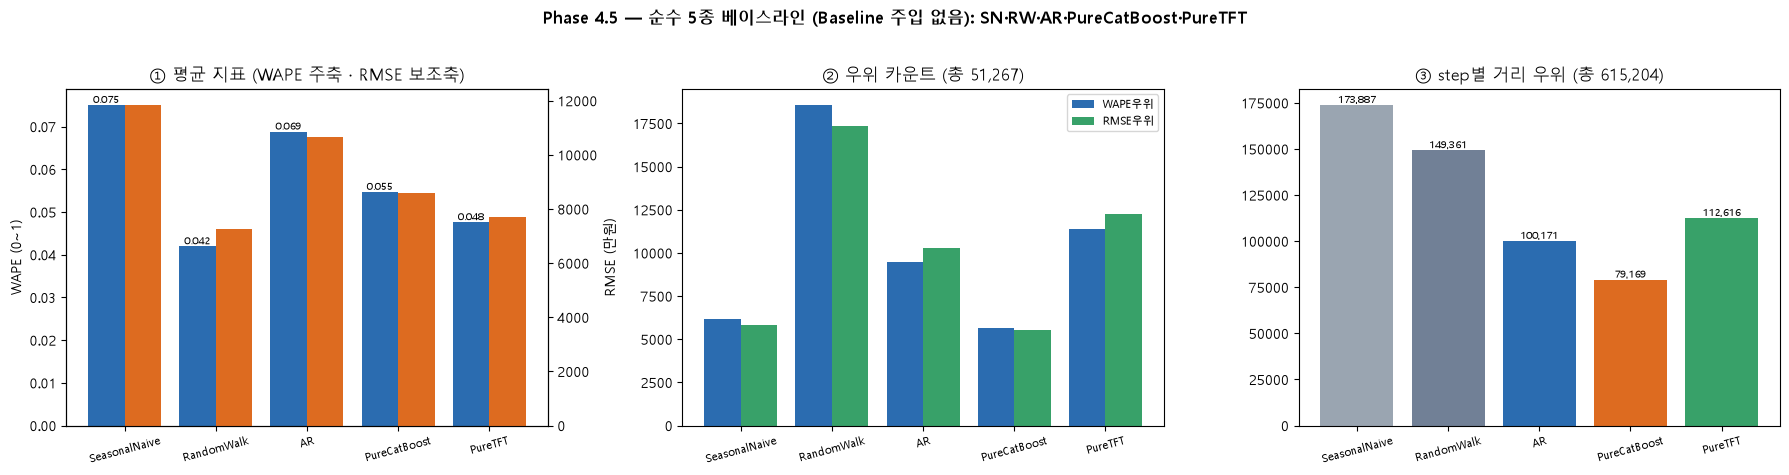

[phase4.5-B] 저장: C:\Users\equip\Desktop\homework\apartment_prediction2\ml_pipeline\final\output_final\pure_baseline_5way


In [21]:
# ===== Phase 4.5-B. 순수 5종 베이스라인 점예측 성능 비교 =====
# 5종(모두 Baseline 주입 없음): SeasonalNaive · RandomWalk · AR · 순수 CatBoost · 순수 TFT
#  - RW = 원점값 반복, AR = 상위셀 pred_AR 재사용, 순수CB/TFT = Phase 4.5-A 결과
#  - SN = panel_full 1회 패스(.indices, 메모리 안전)로 (윈도우,단지)별 점예측 산출
_PURE_DIR = log_dir("pure_baseline_5way")
H = CFG.HORIZON

# WIN_ITEMS의 (윈도우, 단지) 평가 키 집합
_eval_keys = {(it["윈도우"], it["단지"]) for v in WIN_ITEMS.values() for it in v}


def _seasonal_naive_prices(eval_keys):
    """panel_full에서 (윈도우,단지)별 SeasonalNaive 점예측(가격). .indices로 메모리 안전."""
    m = CFG.SEASONAL_PERIOD
    need_gids = {gid for (_, gid) in eval_keys}
    tcol = panel_full[CFG.TIME_COL].values
    yall = pd.to_numeric(panel_full[CFG.TARGET_COL], errors="coerce").astype(float).values
    gidx = panel_full.groupby(GROUP_KEYS, sort=False).indices
    tends = [(w["name"], np.datetime64(pd.Timestamp(w["tr_end"]))) for w in BT_WINDOWS]
    out = {}
    for keyvals, pos in gidx.items():
        gid = "|".join(str(x) for x in (keyvals if isinstance(keyvals, tuple) else (keyvals,)))
        if gid not in need_gids:
            continue
        t = tcol[pos]; y = yall[pos]
        order = np.argsort(t, kind="stable"); t = t[order]; y = y[order]
        for wn, tend in tends:
            if (wn, gid) not in eval_keys:
                continue
            yw = y[t <= tend]
            if len(yw) < CFG.MIN_TRAIN_MONTHS or np.any(yw <= 0):
                continue
            z = np.log(yw) if CFG.LOG_TARGET else yw
            out[(wn, gid)] = to_price_space(forecast_seasonal_naive(z, H, m))
    return out


_SN_PRICES = _seasonal_naive_prices(_eval_keys)
print(f"[phase4.5-B] SeasonalNaive 점예측 산출: {len(_SN_PRICES):,} / {len(_eval_keys):,} 케이스")

MODELS5 = ["SeasonalNaive", "RandomWalk", "AR", "PureCatBoost", "PureTFT"]


def _preds5(it):
    sn = _SN_PRICES.get((it["윈도우"], it["단지"]))
    if sn is None or "pred_pureCB" not in it or "pred_pureTFT" not in it:
        return None
    return {
        "SeasonalNaive": sn,
        "RandomWalk":    to_price_space(np.repeat(it["last"], H)),
        "AR":            it["pred_AR"],
        "PureCatBoost":  it["pred_pureCB"],
        "PureTFT":       it["pred_pureTFT"],
    }


# 분석 단위 지표 + step별 거리 우위 동시 집계
_rows = []
_sw5 = {m: 0 for m in MODELS5}
_sw_total = 0
for v in WIN_ITEMS.values():
    for it in v:
        preds = _preds5(it)
        if preds is None:
            continue
        y = it["yte"]
        r = {"윈도우": it["윈도우"], "단지": it["단지"]}
        for m in MODELS5:
            r[f"WAPE_{m}"] = wape(y, preds[m])
            r[f"RMSE_{m}"] = rmse(y, preds[m])
        _rows.append(r)
        dist = np.vstack([np.abs(y - preds[m]) for m in MODELS5])
        for wi in np.argmin(dist, axis=0):
            _sw5[MODELS5[wi]] += 1
        _sw_total += len(y)
pure_df = pd.DataFrame(_rows)
n_cases = len(pure_df)
print(f"[phase4.5-B] 비교 케이스 {n_cases:,}개 (5종 공통)")

# ① 평균 WAPE/RMSE
avg5 = pd.DataFrame({
    "모델": MODELS5,
    "평균WAPE": [pure_df[f"WAPE_{m}"].mean() for m in MODELS5],
    "평균RMSE": [pure_df[f"RMSE_{m}"].mean() for m in MODELS5],
})
print("\n① 순수 5종 평균 점예측 지표")
print(avg5.to_string(index=False, float_format=lambda x: f"{x:,.4f}"))

# ② 분석 단위 우위 카운트(5종 중 최저)
wW = pure_df[[f"WAPE_{m}" for m in MODELS5]].values.argmin(axis=1)
wR = pure_df[[f"RMSE_{m}" for m in MODELS5]].values.argmin(axis=1)
win5 = pd.DataFrame({
    "모델": MODELS5,
    "WAPE우위": [int((wW == i).sum()) for i in range(5)],
    "RMSE우위": [int((wR == i).sum()) for i in range(5)],
})
print(f"\n② 분석 단위 우위 카운트 (총 {n_cases:,}개, 5종 중 최저)")
print(win5.to_string(index=False))

# ③ step별 거리 우위
sw5 = pd.DataFrame({"모델": MODELS5,
                    "step거리우위": [_sw5[m] for m in MODELS5],
                    "비율": [_sw5[m] / max(_sw_total, 1) for m in MODELS5]})
print(f"\n③ step별 거리 우위 (총 {_sw_total:,} step)")
print(sw5.to_string(index=False, float_format=lambda x: f"{x:,.3f}"))

# 저장 (output_final/pure_baseline_5way)
pure_df.to_csv(os.path.join(_PURE_DIR, "per_analysis_5way.csv"), index=False, encoding="utf-8-sig")
avg5.to_csv(os.path.join(_PURE_DIR, "avg_metrics_5way.csv"), index=False, encoding="utf-8-sig")
win5.to_csv(os.path.join(_PURE_DIR, "win_counts_5way.csv"), index=False, encoding="utf-8-sig")
sw5.to_csv(os.path.join(_PURE_DIR, "stepwise_wins_5way.csv"), index=False, encoding="utf-8-sig")

# 시각화 (① 평균 WAPE/RMSE 이중축 · ② 우위 · ③ step거리)
_palette = ["#9aa5b1", "#718096", "#2b6cb0", "#dd6b20", "#38a169"]
fig, ax = plt.subplots(1, 3, figsize=(18, 4.8))
xp = np.arange(5)
ax0 = ax[0]; ax0r = ax0.twinx()
ax0.bar(xp - 0.2, avg5["평균WAPE"], 0.4, color="#2b6cb0", label="WAPE(주축)")
ax0r.bar(xp + 0.2, avg5["평균RMSE"], 0.4, color="#dd6b20", label="RMSE(보조축)")
ax0.set_xticks(xp); ax0.set_xticklabels(MODELS5, fontsize=8, rotation=15)
ax0.set_ylabel("WAPE (0~1)"); ax0r.set_ylabel("RMSE (만원)")
ax0.set_title("① 평균 지표 (WAPE 주축 · RMSE 보조축)")
for i, val in enumerate(avg5["평균WAPE"]):
    ax0.text(i - 0.2, val, f"{val:.3f}", ha="center", va="bottom", fontsize=7)
ax[1].bar(xp - 0.2, win5["WAPE우위"], 0.4, color="#2b6cb0", label="WAPE우위")
ax[1].bar(xp + 0.2, win5["RMSE우위"], 0.4, color="#38a169", label="RMSE우위")
ax[1].set_xticks(xp); ax[1].set_xticklabels(MODELS5, fontsize=8, rotation=15)
ax[1].set_title(f"② 우위 카운트 (총 {n_cases:,})"); ax[1].legend(fontsize=8)
ax[2].bar(MODELS5, sw5["step거리우위"], color=_palette)
ax[2].tick_params(axis="x", labelrotation=15, labelsize=8)
ax[2].set_title(f"③ step별 거리 우위 (총 {_sw_total:,})")
for r in ax[2].patches:
    ax[2].text(r.get_x() + r.get_width()/2, r.get_height(), f"{int(r.get_height()):,}",
               ha="center", va="bottom", fontsize=7)
fig.suptitle("Phase 4.5 — 순수 5종 베이스라인 (Baseline 주입 없음): SN·RW·AR·PureCatBoost·PureTFT",
             fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(os.path.join(_PURE_DIR, "pure_baseline_5way.png"), dpi=120, bbox_inches="tight")
plt.show()
print(f"[phase4.5-B] 저장: {_PURE_DIR}")


## Phase 5. AR vs AR+CatBoost vs AR+TFT — 3-way 성능 평가

① 3-way 평균 점예측 지표
         모델  평균WAPE      평균RMSE
         AR  0.0688 10,656.5145
AR+CatBoost  0.0570  9,297.8862
     AR+TFT  0.0599  9,491.2300

② 분석 단위 우위 카운트 (총 51,267개, 3종 중 최저)
         모델  WAPE우위  RMSE우위
         AR   13137   13386
AR+CatBoost   17759   17463
     AR+TFT   20371   20418

③ step별 거리 우위 (총 615,204 step)
         모델  step거리우위    비율
         AR    170709 0.277
AR+CatBoost    204491 0.332
     AR+TFT    240004 0.390


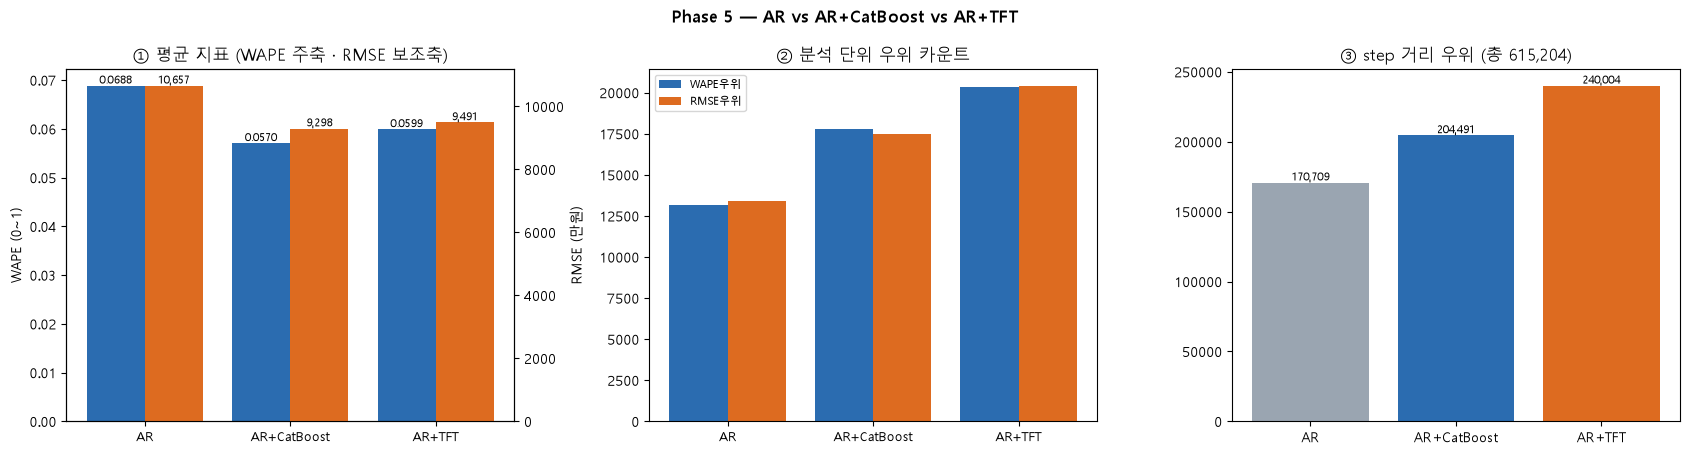


[phase5] 저장 완료: C:\Users\equip\Desktop\homework\apartment_prediction2\ml_pipeline\final\output_final\AR_vs_catboost_vs_tft


In [22]:
# ===== Phase 5. AR vs AR+CatBoost vs AR+TFT 3-way 성능 평가 =====
MODELS3 = [("AR", "pred_AR"), ("AR+CatBoost", "pred_ARCB"), ("AR+TFT", "pred_ARTFT")]
names = [n for n, _ in MODELS3]

_rows = []
for v in WIN_ITEMS.values():
    for it in v:
        r = {"윈도우": it["윈도우"], "단지": it["단지"]}
        for name, key in MODELS3:
            r[f"WAPE_{name}"] = wape(it["yte"], it[key])
            r[f"RMSE_{name}"] = rmse(it["yte"], it[key])
        _rows.append(r)
cmp_df = pd.DataFrame(_rows)

# ① 평균 지표
avg3 = pd.DataFrame({
    "모델": names,
    "평균WAPE": [cmp_df[f"WAPE_{n}"].mean() for n in names],
    "평균RMSE": [cmp_df[f"RMSE_{n}"].mean() for n in names],
})
print("① 3-way 평균 점예측 지표")
print(avg3.to_string(index=False, float_format=lambda x: f"{x:,.4f}"))

# ② 분석 단위 우위 카운트(3종 중 최저)
wW = cmp_df[[f"WAPE_{n}" for n in names]].values.argmin(axis=1)
wR = cmp_df[[f"RMSE_{n}" for n in names]].values.argmin(axis=1)
win3 = pd.DataFrame({
    "모델": names,
    "WAPE우위": [int((wW == i).sum()) for i in range(3)],
    "RMSE우위": [int((wR == i).sum()) for i in range(3)],
})
n_cases = len(cmp_df)
print(f"\n② 분석 단위 우위 카운트 (총 {n_cases:,}개, 3종 중 최저)")
print(win3.to_string(index=False))

# ③ step별 거리 우위
H = CFG.HORIZON
sw3 = np.zeros(3, dtype=int)
sw_total = 0
for v in WIN_ITEMS.values():
    for it in v:
        y = it["yte"]
        dist = np.vstack([np.abs(y - it[key]) for _, key in MODELS3])
        for wi in np.argmin(dist, axis=0):
            sw3[wi] += 1
        sw_total += len(y)
swdf = pd.DataFrame({"모델": names, "step거리우위": sw3.tolist(),
                     "비율": (sw3 / max(sw_total, 1)).tolist()})
print(f"\n③ step별 거리 우위 (총 {sw_total:,} step)")
print(swdf.to_string(index=False, float_format=lambda x: f"{x:,.3f}"))

# 저장 (output_final/AR_vs_catboost_vs_tft)
_CMP_DIR = log_dir("AR_vs_catboost_vs_tft")
cmp_df.to_csv(os.path.join(_CMP_DIR, "per_analysis_3way.csv"), index=False, encoding="utf-8-sig")
avg3.to_csv(os.path.join(_CMP_DIR, "avg_metrics_3way.csv"), index=False, encoding="utf-8-sig")
win3.to_csv(os.path.join(_CMP_DIR, "win_counts_3way.csv"), index=False, encoding="utf-8-sig")
swdf.to_csv(os.path.join(_CMP_DIR, "stepwise_wins_3way.csv"), index=False, encoding="utf-8-sig")

# 시각화 (① 이중축 평균 WAPE/RMSE · ② 우위 · ③ step 거리)
_cols = ["#9aa5b1", "#2b6cb0", "#dd6b20"]
fig, ax = plt.subplots(1, 3, figsize=(17, 4.6))
xpos = np.arange(3)
ax0 = ax[0]; ax0r = ax0.twinx()
ax0.bar(xpos - 0.2, avg3["평균WAPE"], 0.4, color="#2b6cb0", label="WAPE(주축)")
ax0r.bar(xpos + 0.2, avg3["평균RMSE"], 0.4, color="#dd6b20", label="RMSE(보조축)")
ax0.set_xticks(xpos); ax0.set_xticklabels(names, fontsize=9)
ax0.set_ylabel("WAPE (0~1)"); ax0r.set_ylabel("RMSE (만원)")
ax0.set_title("① 평균 지표 (WAPE 주축 · RMSE 보조축)")
for i, val in enumerate(avg3["평균WAPE"]):
    ax0.text(i - 0.2, val, f"{val:.4f}", ha="center", va="bottom", fontsize=8)
for i, val in enumerate(avg3["평균RMSE"]):
    ax0r.text(i + 0.2, val, f"{val:,.0f}", ha="center", va="bottom", fontsize=8)
ax[1].bar(xpos - 0.2, win3["WAPE우위"], 0.4, color="#2b6cb0", label="WAPE우위")
ax[1].bar(xpos + 0.2, win3["RMSE우위"], 0.4, color="#dd6b20", label="RMSE우위")
ax[1].set_xticks(xpos); ax[1].set_xticklabels(names, fontsize=9)
ax[1].set_title("② 분석 단위 우위 카운트"); ax[1].legend(fontsize=8)
ax[2].bar(names, sw3, color=_cols)
ax[2].set_title(f"③ step 거리 우위 (총 {sw_total:,})")
for i, val in enumerate(sw3):
    ax[2].text(i, val, f"{val:,}", ha="center", va="bottom", fontsize=8)
fig.suptitle("Phase 5 — AR vs AR+CatBoost vs AR+TFT", fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(_CMP_DIR, "compare_3way.png"), dpi=120, bbox_inches="tight")
plt.show()
print(f"\n[phase5] 저장 완료: {_CMP_DIR}")


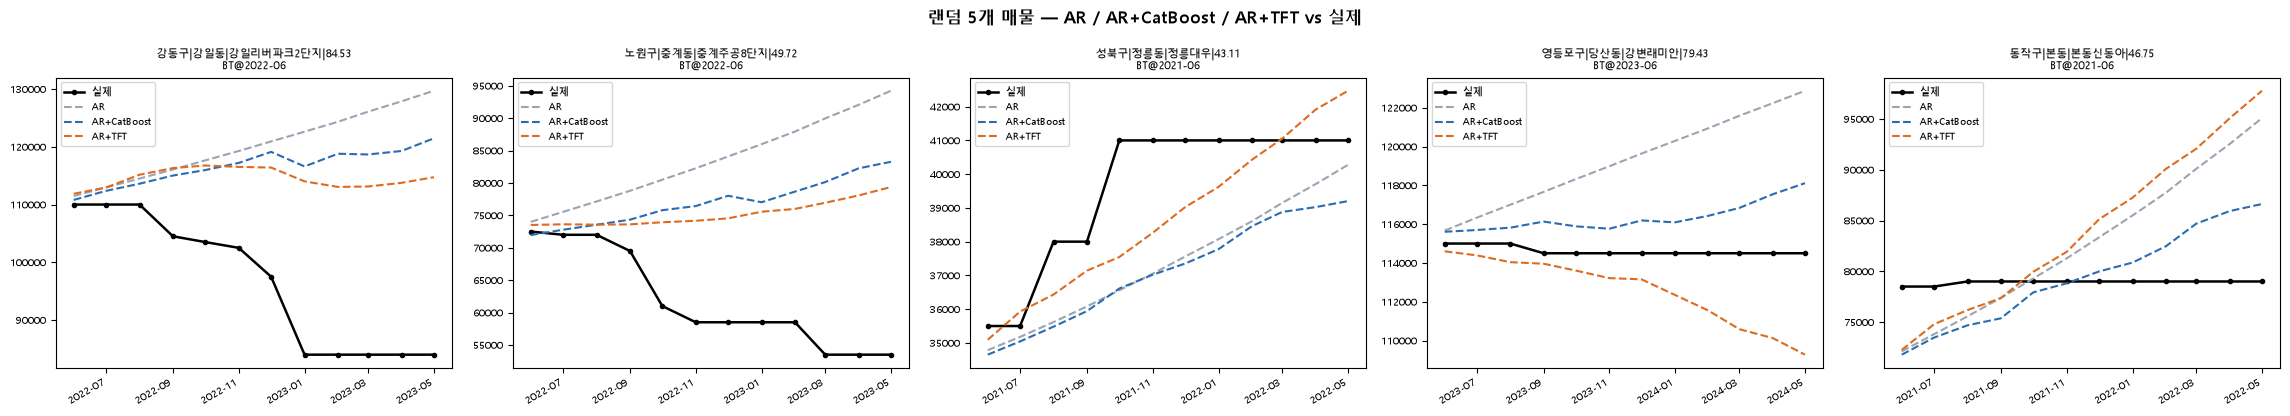

In [23]:
# ===== Phase 5+. 랜덤 5개(윈도우×매물): AR / AR+CatBoost / AR+TFT vs 실제 =====
_all_items = [it for v in WIN_ITEMS.values() for it in v]
rng = np.random.default_rng(7)
pick = rng.choice(len(_all_items), size=min(5, len(_all_items)), replace=False)
fig, axes = plt.subplots(1, len(pick), figsize=(4.6 * len(pick), 4.2), squeeze=False)
for ax, idx in zip(axes[0], pick):
    it = _all_items[idx]
    x = it["dates"]
    ax.plot(x, it["yte"], "-o", color="black", lw=1.8, ms=3, label="실제")
    ax.plot(x, it["pred_AR"], "--", color="#9aa5b1", lw=1.5, label="AR")
    ax.plot(x, it["pred_ARCB"], "--", color="#2b6cb0", lw=1.5, label="AR+CatBoost")
    ax.plot(x, it["pred_ARTFT"], "--", color="#dd6b20", lw=1.5, label="AR+TFT")
    ax.set_title(f"{it['단지']}\n{it['윈도우']}", fontsize=8)
    ax.tick_params(labelsize=7)
    ax.legend(fontsize=7)
    for lab in ax.get_xticklabels():
        lab.set_rotation(30); lab.set_ha("right")
fig.suptitle("랜덤 5개 매물 — AR / AR+CatBoost / AR+TFT vs 실제", fontweight="bold")
plt.tight_layout()
_CMP_DIR = log_dir("AR_vs_catboost_vs_tft")
plt.savefig(os.path.join(_CMP_DIR, "random5_3way.png"), dpi=120, bbox_inches="tight")
plt.show()


## Phase 6 — 변수 영향 해석 (CatBoost SHAP · TFT VSN)

AR h-step 잔차(`resid_target`)를 보정하는 두 모델이 **어떤 변수에 의존해 보정하는지** 분석한다.
- **CatBoost SHAP**: 윈도우별로 학습세트를 표본 추출해 `ShapValues` 계산 → 변수별 평균 |기여도|(중요도)와 평균 부호(영향 방향).
- **TFT VSN(Variable Selection Network)**: `interpret_output` 으로 encoder/decoder/static 변수 선택 가중치 추출 → 특히 **decoder_variables = 예측(미래 horizon)에 영향을 준 known reals**.
- 산출물은 모두 `output_final/shap_catboost`, `output_final/vsn_tft` 에 저장하고, 최하단 셀에서 두 관점을 종합해 "어떤 변수가 어떤 영향을 미쳤는지" 텍스트로 해석한다.


[shap] BT@2025-06 상위 변수: base_drift(↓(잔차 -)), depth1__ecos__cd_91d_rate(↓(잔차 -)), depth1__ecos__cpi_housing(↓(잔차 -)), depth1__ecos__m2_avg(↓(잔차 -)), h_step(↑(잔차 +)), depth3__policy__ltv_tightness(↑(잔차 +)), depth3__reb__apt_jeonse_index(↓(잔차 -)), depth2__reb__apt_monthly_rent_supply_demand(↓(잔차 -))
[shap] BT@2024-06 상위 변수: base_drift(↓(잔차 -)), h_step(↓(잔차 -)), origin_last(↓(잔차 -)), depth1__ecos__m2_avg(↓(잔차 -)), depth1__ecos__cd_91d_rate(↓(잔차 -)), depth3__reb__apt_sale_index(↓(잔차 -)), origin_mom12(↑(잔차 +)), depth1__ecos__cpi_housing(↓(잔차 -))
[shap] BT@2023-06 상위 변수: base_drift(↓(잔차 -)), h_step(↑(잔차 +)), origin_last(↓(잔차 -)), depth1__ecos__m2_avg(↓(잔차 -)), depth1__ecos__mortgage_rate_new(↓(잔차 -)), depth3__reb__apt_sale_index(↓(잔차 -)), origin_mom12(↑(잔차 +)), depth2__reb__apt_sale_supply_demand(↓(잔차 -))
[shap] BT@2022-06 상위 변수: base_drift(↓(잔차 -)), h_step(↓(잔차 -)), depth1__ecos__m2_avg(↑(잔차 +)), origin_last(↓(잔차 -)), depth1__ecos__mortgage_rate_new(↑(잔차 +)), origin_mom12(↓(잔차 -)), depth3__

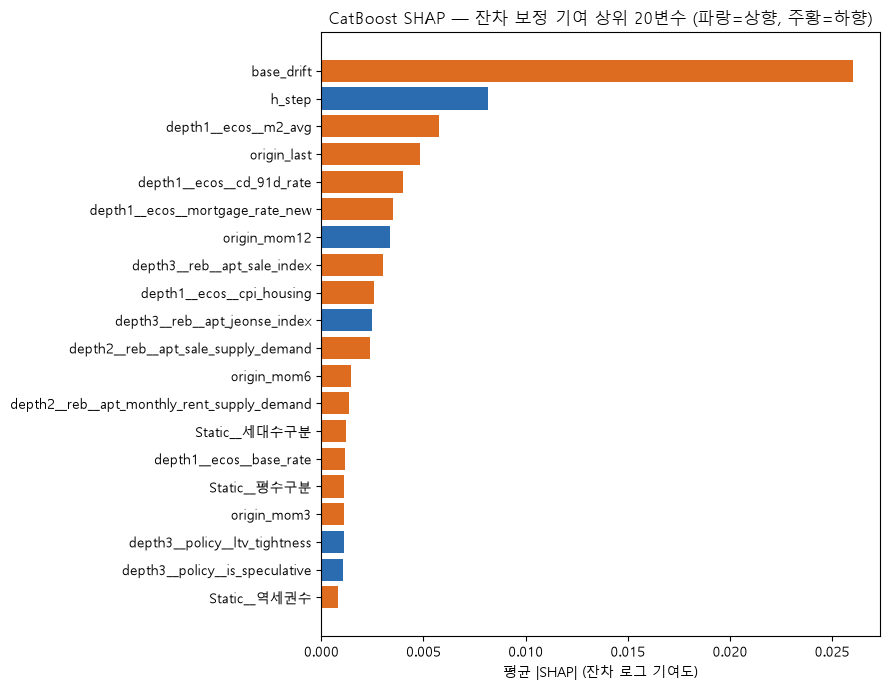


[phase6-A] CatBoost SHAP 저장: C:\Users\equip\Desktop\homework\apartment_prediction2\ml_pipeline\final\output_final\shap_catboost
                                 변수  평균중요도    평균방향         부호
                         base_drift 0.0260 -0.0029 ↓(잔차 하향보정)
                             h_step 0.0082  0.0001 ↑(잔차 상향보정)
               depth1__ecos__m2_avg 0.0057 -0.0001 ↓(잔차 하향보정)
                        origin_last 0.0048 -0.0007 ↓(잔차 하향보정)
          depth1__ecos__cd_91d_rate 0.0040 -0.0005 ↓(잔차 하향보정)
    depth1__ecos__mortgage_rate_new 0.0035 -0.0003 ↓(잔차 하향보정)
                       origin_mom12 0.0033  0.0004 ↑(잔차 상향보정)
        depth3__reb__apt_sale_index 0.0030 -0.0003 ↓(잔차 하향보정)
          depth1__ecos__cpi_housing 0.0026 -0.0000 ↓(잔차 하향보정)
      depth3__reb__apt_jeonse_index 0.0025  0.0003 ↑(잔차 상향보정)
depth2__reb__apt_sale_supply_demand 0.0024 -0.0002 ↓(잔차 하향보정)
                        origin_mom6 0.0015 -0.0001 ↓(잔차 하향보정)


In [24]:
# ===== Phase 6-A. CatBoost SHAP — 윈도우별 변수 기여도/방향 =====
_SHAP_DIR = log_dir("shap_catboost")
_shap_frames = []
for w in BT_WINDOWS:
    ts = WIN_TRAINSETS[w["name"]]
    if ts is None or len(ts) == 0:
        continue
    n = min(len(ts), CFG.SHAP_SAMPLE_ROWS)
    samp = ts.sample(n=n, random_state=CFG.CB_RANDOM_SEED) if len(ts) > n else ts
    X = _prep_features(samp)
    y = samp["resid_target"].values
    ci = [X.columns.get_loc(c) for c in CAT_FEATS]
    cb_w = CB_BY_WINDOW[w["name"]]
    shap = cb_w.get_feature_importance(Pool(X, y, cat_features=ci), type="ShapValues")
    shap = np.asarray(shap)[:, :-1]                       # 마지막 열(기대값) 제거
    feat_names = list(X.columns)
    imp = np.abs(shap).mean(axis=0)                       # 변수별 평균 |기여도| = 중요도
    direction = shap.mean(axis=0)                         # 변수별 평균 부호 = 영향 방향
    dfw = pd.DataFrame({"윈도우": w["name"], "변수": feat_names,
                        "중요도": imp, "방향": direction})
    dfw["부호"] = np.where(dfw["방향"] >= 0, "↑(잔차 +)", "↓(잔차 -)")
    dfw = dfw.sort_values("중요도", ascending=False).reset_index(drop=True)
    dfw.to_csv(os.path.join(_SHAP_DIR, f"shap_{w['name']}.csv"), index=False, encoding="utf-8-sig")
    _shap_frames.append(dfw)
    top = dfw.head(8)
    print(f"[shap] {w['name']} 상위 변수: " +
          ", ".join(f"{r['변수']}({r['부호']})" for _, r in top.iterrows()))

shap_all = pd.concat(_shap_frames, ignore_index=True)
# 윈도우 평균 중요도/방향 집계
shap_summary = (shap_all.groupby("변수")
                .agg(평균중요도=("중요도", "mean"), 평균방향=("방향", "mean"))
                .reset_index().sort_values("평균중요도", ascending=False).reset_index(drop=True))
shap_summary["부호"] = np.where(shap_summary["평균방향"] >= 0, "↑(잔차 상향보정)", "↓(잔차 하향보정)")
shap_summary.to_csv(os.path.join(_SHAP_DIR, "shap_summary_allwindows.csv"),
                    index=False, encoding="utf-8-sig")

# 상위 20개 막대그래프 (방향에 따라 색)
topN = shap_summary.head(20).iloc[::-1]
colors = ["#2b6cb0" if d >= 0 else "#dd6b20" for d in topN["평균방향"]]
plt.figure(figsize=(9, 7))
plt.barh(topN["변수"], topN["평균중요도"], color=colors)
plt.xlabel("평균 |SHAP| (잔차 로그 기여도)")
plt.title("CatBoost SHAP — 잔차 보정 기여 상위 20변수 (파랑=상향, 주황=하향)")
plt.tight_layout()
plt.savefig(os.path.join(_SHAP_DIR, "shap_top20.png"), dpi=120, bbox_inches="tight")
plt.show()
print(f"\n[phase6-A] CatBoost SHAP 저장: {_SHAP_DIR}")
print(shap_summary.head(12).to_string(index=False, float_format=lambda x: f"{x:,.4f}"))


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


[vsn] BT@2025-06 decoder 상위: h_step(0.20), base_drift(0.15), origin_mom6(0.10), depth3__reb__apt_jeonse_index(0.05), depth2__reb__apt_sale_supply_demand(0.05)


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


[vsn] BT@2024-06 decoder 상위: base_drift(0.56), depth2__reb__apt_sale_supply_demand(0.07), origin_mom12(0.04), h_step(0.04), origin_last(0.03)


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


[vsn] BT@2023-06 decoder 상위: base_drift(0.52), origin_mom12(0.07), depth2__reb__apt_sale_supply_demand(0.05), h_step(0.04), origin_mom6(0.03)


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


[vsn] BT@2022-06 decoder 상위: base_drift(0.40), depth2__reb__apt_sale_supply_demand(0.08), h_step(0.07), origin_mom12(0.06), depth2__reb__apt_monthly_rent_supply_demand(0.04)
[vsn] BT@2021-06 decoder 상위: base_drift(0.41), h_step(0.11), depth3__reb__apt_sale_index(0.04), depth1__ecos__mortgage_rate_new(0.04), depth1__ecos__unemployment_rate(0.04)


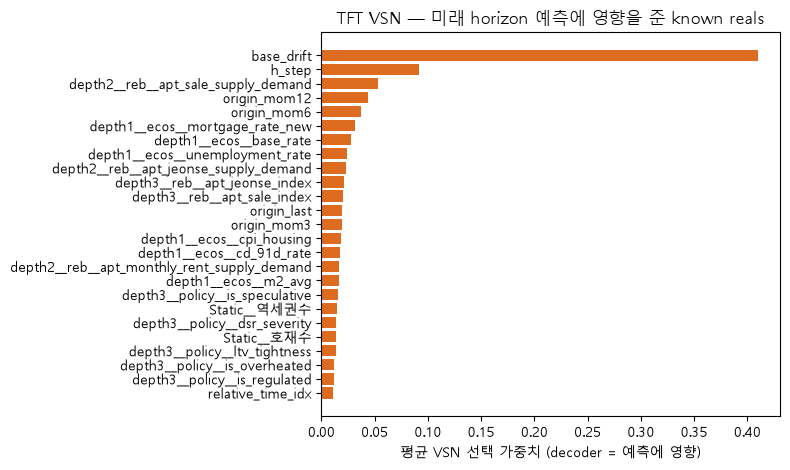


[phase6-B] TFT VSN 저장: C:\Users\equip\Desktop\homework\apartment_prediction2\ml_pipeline\final\output_final\vsn_tft
                                         변수  선택가중치
                                 base_drift 0.4102
                                     h_step 0.0920
        depth2__reb__apt_sale_supply_demand 0.0536
                               origin_mom12 0.0437
                                origin_mom6 0.0374
            depth1__ecos__mortgage_rate_new 0.0313
                    depth1__ecos__base_rate 0.0275
            depth1__ecos__unemployment_rate 0.0239
      depth2__reb__apt_jeonse_supply_demand 0.0235
              depth3__reb__apt_jeonse_index 0.0218
                depth3__reb__apt_sale_index 0.0205
                                origin_last 0.0195
                                origin_mom3 0.0193
                  depth1__ecos__cpi_housing 0.0182
                  depth1__ecos__cd_91d_rate 0.0175
depth2__reb__apt_monthly_rent_supply_demand 0.0170
                

In [25]:
# ===== Phase 6-B. TFT VSN — Variable Selection Network 변수 선택 가중치 =====
_VSN_DIR = log_dir("vsn_tft")


def _vsn_weights(interp, key, names):
    """interpret_output 결과에서 변수 선택 가중치 추출 → 합=1 정규화."""
    v = np.asarray(interp[key].detach().cpu().numpy(), dtype=float).ravel()
    names = list(names)
    if len(v) != len(names):                       # 길이 불일치 시 generic 이름 폴백
        names = [f"var_{i}" for i in range(len(v))]
    s = v.sum()
    return names, (v / s if s > 0 else v)


_vsn_dec_frames = []
for w in BT_WINDOWS:
    pack = TFT_BY_WINDOW.get(w["name"])
    if pack is None:
        continue
    model, tds = pack
    try:
        model.eval()
        dl = tds.to_dataloader(train=False, batch_size=CFG.TFT_BATCH, num_workers=0)
        raw = model.predict(dl, mode="raw", return_x=True)
        interp = model.interpret_output(raw.output, reduction="sum")
        for key, names in [("encoder_variables", model.encoder_variables),
                           ("decoder_variables", model.decoder_variables),
                           ("static_variables", model.static_variables)]:
            nm, wt = _vsn_weights(interp, key, names)
            dfk = pd.DataFrame({"윈도우": w["name"], "구분": key, "변수": nm, "선택가중치": wt})
            dfk = dfk.sort_values("선택가중치", ascending=False).reset_index(drop=True)
            dfk.to_csv(os.path.join(_VSN_DIR, f"vsn_{key}_{w['name']}.csv"),
                       index=False, encoding="utf-8-sig")
            if key == "decoder_variables":
                _vsn_dec_frames.append(dfk)
        top = _vsn_dec_frames[-1].head(5)
        print(f"[vsn] {w['name']} decoder 상위: " +
              ", ".join(f"{r['변수']}({r['선택가중치']:.2f})" for _, r in top.iterrows()))
    except Exception as e:
        print(f"[vsn] {w['name']} 추출 실패: {type(e).__name__}: {e}")

if _vsn_dec_frames:
    vsn_dec = pd.concat(_vsn_dec_frames, ignore_index=True)
    vsn_dec_summary = (vsn_dec.groupby("변수")["선택가중치"].mean()
                       .reset_index().sort_values("선택가중치", ascending=False).reset_index(drop=True))
    vsn_dec_summary.to_csv(os.path.join(_VSN_DIR, "vsn_decoder_summary_allwindows.csv"),
                           index=False, encoding="utf-8-sig")
    top = vsn_dec_summary.iloc[::-1]
    plt.figure(figsize=(8, 4.8))
    plt.barh(top["변수"], top["선택가중치"], color="#dd6b20")
    plt.xlabel("평균 VSN 선택 가중치 (decoder = 예측에 영향)")
    plt.title("TFT VSN — 미래 horizon 예측에 영향을 준 known reals")
    plt.tight_layout()
    plt.savefig(os.path.join(_VSN_DIR, "vsn_decoder_top.png"), dpi=120, bbox_inches="tight")
    plt.show()
    print(f"\n[phase6-B] TFT VSN 저장: {_VSN_DIR}")
    print(vsn_dec_summary.to_string(index=False, float_format=lambda x: f"{x:,.4f}"))
else:
    vsn_dec_summary = pd.DataFrame(columns=["변수", "선택가중치"])
    print("[phase6-B] VSN 추출 결과 없음")


In [26]:
# ===== Phase 6-C. 종합 해석 — 어떤 변수가 어떤 영향을 미쳤는가 =====
# CatBoost SHAP(세부 변수·방향)와 TFT VSN(known reals 선택)을 나란히 비교·서술한다.
_ANA_DIR = log_dir("explainability_summary")

print("=" * 78)
print("■ 종합 변수 영향 해석  (AR 잔차 보정 관점)")
print("=" * 78)

# ── 1) CatBoost SHAP: 상위 기여 변수와 영향 방향 ──
print("\n[1] CatBoost — 잔차 보정에 가장 크게 기여한 변수 (평균 |SHAP|)")
cb_top = shap_summary.head(10).copy()
for rank, (_, r) in enumerate(cb_top.iterrows(), 1):
    eff = "예측을 상향(가격↑) 보정" if r["평균방향"] >= 0 else "예측을 하향(가격↓) 보정"
    print(f"   {rank:2d}. {r['변수']:<28s} 중요도 {r['평균중요도']:.4f} → 평균적으로 {eff}")

# ── 2) TFT VSN: 미래 예측(decoder)에 영향을 준 known reals ──
print("\n[2] TFT VSN — 미래 horizon 예측에 영향을 준 known reals (decoder 선택 가중치)")
if len(vsn_dec_summary):
    for rank, (_, r) in enumerate(vsn_dec_summary.head(10).iterrows(), 1):
        print(f"   {rank:2d}. {r['변수']:<20s} 선택가중치 {r['선택가중치']:.4f}")
else:
    print("   (VSN 결과 없음)")

# ── 3) 두 모델 공통 시사점 ──
print("\n[3] 종합 시사점")
_cb_origin = cb_top[cb_top["변수"].isin(["base_drift", "origin_last", "origin_mom3",
                                          "origin_mom6", "origin_mom12", "h_step"])]
if len(_cb_origin):
    print("   · 원점 추세(base_drift/origin_*)·예측구간(h_step)이 SHAP 상위에 → "
          "AR 점예측의 모멘텀/구간 길이가 잔차 보정의 핵심.")
_cb_macro = cb_top[cb_top["변수"].str.startswith("depth")]
if len(_cb_macro):
    print("   · 거시/지역 depth 변수(" + ", ".join(_cb_macro["변수"].head(3)) +
          " 등)가 상위 → 매물 외부 시장환경이 잔차에 유의미.")
_cb_static = cb_top[cb_top["변수"].str.startswith("Static__")]
if len(_cb_static):
    print("   · 정적 단지속성(" + ", ".join(_cb_static["변수"].head(3)) +
          " 등) → 단지 고유특성이 보정 방향을 좌우.")
if len(vsn_dec_summary):
    _vd = vsn_dec_summary.iloc[0]
    print(f"   · TFT는 decoder에서 '{_vd['변수']}'(가중치 {_vd['선택가중치']:.2f})를 가장 비중 있게 선택 → "
          "TFT의 미래 보정도 동일 신호에 의존.")

# 종합표 저장
merged = shap_summary.rename(columns={"평균중요도": "CatBoost_중요도", "평균방향": "CatBoost_방향"})
merged.to_csv(os.path.join(_ANA_DIR, "explainability_catboost_shap.csv"),
              index=False, encoding="utf-8-sig")
if len(vsn_dec_summary):
    vsn_dec_summary.rename(columns={"선택가중치": "TFT_decoder_가중치"}).to_csv(
        os.path.join(_ANA_DIR, "explainability_tft_vsn.csv"), index=False, encoding="utf-8-sig")
print(f"\n[phase6-C] 종합 해석 저장: {_ANA_DIR}")
print("=" * 78)


■ 종합 변수 영향 해석  (AR 잔차 보정 관점)

[1] CatBoost — 잔차 보정에 가장 크게 기여한 변수 (평균 |SHAP|)
    1. base_drift                   중요도 0.0260 → 평균적으로 예측을 하향(가격↓) 보정
    2. h_step                       중요도 0.0082 → 평균적으로 예측을 상향(가격↑) 보정
    3. depth1__ecos__m2_avg         중요도 0.0057 → 평균적으로 예측을 하향(가격↓) 보정
    4. origin_last                  중요도 0.0048 → 평균적으로 예측을 하향(가격↓) 보정
    5. depth1__ecos__cd_91d_rate    중요도 0.0040 → 평균적으로 예측을 하향(가격↓) 보정
    6. depth1__ecos__mortgage_rate_new 중요도 0.0035 → 평균적으로 예측을 하향(가격↓) 보정
    7. origin_mom12                 중요도 0.0033 → 평균적으로 예측을 상향(가격↑) 보정
    8. depth3__reb__apt_sale_index  중요도 0.0030 → 평균적으로 예측을 하향(가격↓) 보정
    9. depth1__ecos__cpi_housing    중요도 0.0026 → 평균적으로 예측을 하향(가격↓) 보정
   10. depth3__reb__apt_jeonse_index 중요도 0.0025 → 평균적으로 예측을 상향(가격↑) 보정

[2] TFT VSN — 미래 horizon 예측에 영향을 준 known reals (decoder 선택 가중치)
    1. base_drift           선택가중치 0.4102
    2. h_step               선택가중치 0.0920
    3. depth2__reb__apt_sale_supply_demand 선택가중치 0.0536
    4. origin_mo

## Phase 7 — Student-t Fat-tail 블록 부트스트랩 + 현실성 필터 (5종 모델 밴드 비교)

`scenario_rolling_pipeline.ipynb` 의 Phase 5 와 동일한 엔진으로, **이미 학습/예측이 끝난 상위 셀의 결과**
(`WIN_ITEMS`, `WIN_TRAINSETS`, `CB_BY_WINDOW`, `TFT_BY_WINDOW`)만 재사용해 **부트스트랩만** 수행한다.

- **시나리오 수 자동산정** : 경험분포 극단충격(상위 `EXTREME_QUANTILE` 분위)이 `EXTREME_K_MIN`회 이상,
  신뢰 `CONFIDENCE` 로 표집되도록 이항 하드조건 $F_{\text{Binom}}(k_{\min}-1;N,p)\le 1-c$ 를 만족하는 최소 $N$.
- **Student-t($\nu$) fat-tail** : 경험 혁신풀에 확률 `TAIL_PROB` 로 t-꼬리 블록을 주입.
- **현실성 필터** : 월간변동률 $|e^{\Delta\log P}-1|>$ `REALISM_MAX_MOM`(=0.25, 월 25%↑) 경로 제거.

**대상 5종** : RandomWalk · SeasonalNaive · AR · AR+CatBoost · AR+TFT (각 + 부트스트랩 + 현실성필터).

**메모리·재수행 안전 구조 (3-셀 분할)** — 전체 단지×5폴드를 한 셀에서 돌리면 마지막 폴드에서 OOM 나므로 분할:
- **7-B①** 풀 사전계산 → `phase7_pools.pkl` 로 **캐시**. 재수행 시 캐시가 있으면 즉시 로드(재계산 생략).
  강제 재계산은 `FORCE_RECOMPUTE_POOLS=True`.
- **7-B②** **윈도우(폴드) 1개씩** 밴드 계산 → `per_analysis_band_metrics__{윈도우}.csv` 저장 → 즉시 메모리 해제(gc).
  이미 저장된 폴드는 건너뛰므로, 중간에 죽어도 **재수행하면 남은 폴드만 이어서** 진행한다.
- **7-B③** 폴드별 CSV 만 읽어 종합 요약·그래프 산출(메모리 부담 없음).

**산출** : ① P50 기준 RMSE·WAPE 평균(윈도우별/전체), ② 전체 생성 시나리오 RMSE·WAPE 평균,
③ 밴드지표(PICP80·Pinball·IntervalScore80) 평균, ④ WAPE 최우수 5 / 최저 5 분석 Fan Chart.
모든 산출물은 `output_final/bootstrap_compare/` 에 저장한다.


In [27]:
# ===== Phase 7-A. 밴드 지표 + Student-t 꼬리 블록 부트스트랩 엔진 (ref 벡터화 동일) =====
def mean_pinball(y_true, q_preds: dict) -> float:
    y = np.asarray(y_true, float)
    out = []
    for q, p in q_preds.items():
        e = y - np.asarray(p, float)
        out.append(np.mean(np.maximum(q * e, (q - 1.0) * e)))
    return float(np.mean(out))


def winkler_score(y_true, lower, upper, alpha: float) -> float:
    y = np.asarray(y_true, float); L = np.asarray(lower, float); U = np.asarray(upper, float)
    s = (U - L).astype(float)
    below = y < L; above = y > U
    s[below] += (2.0 / alpha) * (L[below] - y[below])
    s[above] += (2.0 / alpha) * (y[above] - U[above])
    return float(np.mean(s))


def coverage(y_true, lower, upper) -> float:
    y = np.asarray(y_true, float); L = np.asarray(lower, float); U = np.asarray(upper, float)
    return float(np.mean((y >= L) & (y <= U)))


def build_residual_pool(resid_pool: np.ndarray) -> dict:
    arr = np.asarray(resid_pool, float); arr = arr[np.isfinite(arr)]
    pool = {"empirical": arr}
    if CFG.FAT_TAIL and len(arr) >= 10:
        try:
            df, loc, scale = stats.t.fit(arr, f0=CFG.T_DF_INIT)
        except Exception:
            df, loc, scale = 1e6, float(arr.mean()), float(arr.std() + 1e-9)
        pool["t_model"] = (float(df), float(loc), float(scale))
    return pool


def required_N_hard(p_rare, k_min, confidence, hard_floor) -> int:
    if p_rare <= 0:
        return hard_floor
    N = k_min
    while stats.binom.cdf(k_min - 1, N, p_rare) > (1 - confidence):
        N += 100
        if N > 10_000_000:
            break
    return max(N, hard_floor)


def compute_n_scenarios(pool: dict, block: int):
    abs_r = np.abs(pool["empirical"])
    if len(abs_r) == 0:
        return max(CFG.N_BOOTSTRAP, CFG.HARD_FLOOR_N), 0.0, 0.0
    q_thresh = np.quantile(abs_r, CFG.EXTREME_QUANTILE)
    p_step = float((abs_r > q_thresh).mean())
    p_block = 1.0 - (1.0 - p_step) ** block
    N = required_N_hard(p_block, CFG.EXTREME_K_MIN, CFG.CONFIDENCE,
                        max(CFG.N_BOOTSTRAP, CFG.HARD_FLOOR_N))
    return N, p_step, p_block


def block_bootstrap_innovations(pool, horizon, n_boot, block, rng):
    """⚡ 벡터화 블록 부트스트랩 → (n_boot, horizon) 혁신행렬 (ref 동일)."""
    emp = pool["empirical"]
    n_emp = len(emp)
    n_blocks = int(np.ceil(horizon / block))
    out = np.empty((n_boot, n_blocks, block), float)
    if ("t_model" in pool) and CFG.FAT_TAIL:
        fat_mask = rng.random((n_boot, n_blocks)) < CFG.TAIL_PROB
    else:
        fat_mask = np.zeros((n_boot, n_blocks), bool)
    emp_sel = ~fat_mask
    n_emp_blk = int(emp_sel.sum())
    if n_emp_blk and n_emp > 0:
        max_start = max(1, n_emp - block + 1)
        starts = rng.integers(0, max_start, size=n_emp_blk)
        idx = starts[:, None] + np.arange(block)[None, :]
        idx = np.minimum(idx, n_emp - 1)
        out[emp_sel] = emp[idx]
    elif n_emp_blk:
        out[emp_sel] = 0.0
    n_fat_blk = int(fat_mask.sum())
    if n_fat_blk:
        df, loc, scale = pool["t_model"]
        out[fat_mask] = stats.t.rvs(df, loc=loc, scale=scale,
                                    size=(n_fat_blk, block), random_state=rng)
    return out.reshape(n_boot, n_blocks * block)[:, :horizon]


def realism_keep_mask(ensemble_log, origin_log, max_mom):
    anchor = np.full((ensemble_log.shape[0], 1), origin_log, float)
    full = np.concatenate([anchor, ensemble_log], axis=1)
    mom = np.exp(np.diff(full, axis=1)) - 1.0
    return np.all(np.abs(mom) <= max_mom, axis=1)


def make_bands(point_log, resid_pool, origin_log, seed_offset=0, quantiles=None) -> dict:
    H = len(point_log)
    rng = np.random.default_rng(CFG.BOOTSTRAP_SEED + seed_offset)
    pool = build_residual_pool(resid_pool)
    N, p_step, p_block = compute_n_scenarios(pool, CFG.BLOCK_SIZE)
    innov = block_bootstrap_innovations(pool, H, N, CFG.BLOCK_SIZE, rng)
    ens_log = point_log[None, :] + np.cumsum(innov, axis=1)
    n_drop = 0
    if CFG.REALISM_DROP:
        keep = realism_keep_mask(ens_log, origin_log, CFG.REALISM_MAX_MOM)
        n_drop = int((~keep).sum())
        if keep.sum() >= 20:
            ens_log = ens_log[keep]
        else:
            n_drop = 0
    ens_price = to_price_space(ens_log)
    qs_list = quantiles if quantiles is not None else CFG.QUANTILES
    qs = {q: np.quantile(ens_price, q, axis=0) for q in qs_list}
    return {"q": qs, "ensemble": ens_price, "n_keep": ens_price.shape[0],
            "n_drop": n_drop, "point": to_price_space(point_log),
            "n_scenarios": int(N), "p_rare_step": p_step, "p_rare_block": p_block}


def error_increment_pool(resid_df: pd.DataFrame, post_err: np.ndarray) -> np.ndarray:
    """보정 후 h스텝 오차의 origin별 1스텝 증분 풀(벡터화 groupby-diff). 평균 0 중심화."""
    tmp = resid_df[GROUP_KEYS + [HSTEP_COL]].copy()
    realized = resid_df[CFG.TIME_COL].dt.to_period("M")
    tmp["origin"] = (realized - resid_df[HSTEP_COL].astype(int)).astype(str)
    tmp["post"] = np.asarray(post_err, float)
    tmp = tmp.sort_values(GROUP_KEYS + ["origin", HSTEP_COL])
    grp = tmp.groupby(GROUP_KEYS + ["origin"], sort=False)["post"]
    d = grp.diff()
    first = grp.cumcount() == 0
    d = d.to_numpy()
    d[first.to_numpy()] = tmp["post"].to_numpy()[first.to_numpy()]
    return d - np.nanmean(d)


def baseline_increment_pool(panel: pd.DataFrame, tr_end, model: str) -> np.ndarray:
    """RandomWalk / SeasonalNaive 의 h스텝 예측오차 1스텝 증분 풀 (모델적합 없음)."""
    H = CFG.HORIZON
    incs = []
    sub = panel[panel[CFG.TIME_COL] <= tr_end]
    for _, g in sub.groupby(GROUP_KEYS, sort=False):
        g = g.sort_values(CFG.TIME_COL)
        y = g[CFG.TARGET_COL].astype(float).values
        n = len(g)
        if n < CFG.MIN_TRAIN_MONTHS + 1 or np.any(y <= 0):
            continue
        z = np.log(y) if CFG.LOG_TARGET else y
        for t0 in range(CFG.MIN_TRAIN_MONTHS, n - 1, CFG.ORIGIN_STRIDE):
            z_tr = z[:t0]
            hmax = min(H, n - 1 - t0)
            if hmax < 1:
                continue
            if model == "RandomWalk":
                fc = np.repeat(z_tr[-1], hmax)
            else:  # SeasonalNaive
                fc = forecast_seasonal_naive(z_tr, hmax, CFG.SEASONAL_PERIOD)
            err = z[t0:t0 + hmax] - fc
            keep = np.abs(err) <= CFG.ERR_CLIP_LOG
            err = err[keep]
            if len(err) == 0:
                continue
            incs.append(np.diff(err, prepend=0.0))
    if not incs:
        return np.zeros(1)
    pool = np.concatenate(incs)
    return pool - np.nanmean(pool)


def ensemble_point_errors(ens_price: np.ndarray, y_true: np.ndarray):
    """전체 생성 시나리오 각각의 WAPE·RMSE 평균(시나리오 전체에 대한 오차)."""
    y = np.asarray(y_true, float)
    denom = np.abs(y).sum()
    wape_s = np.abs(ens_price - y).sum(axis=1) / denom if denom > 0 else np.full(ens_price.shape[0], np.nan)
    rmse_s = np.sqrt(((ens_price - y) ** 2).mean(axis=1))
    return float(np.nanmean(wape_s)), float(np.nanmean(rmse_s))


print("[phase7-A] 부트스트랩 엔진 준비: make_bands, baseline_increment_pool, error_increment_pool, "
      "mean_pinball, winkler_score, coverage, ensemble_point_errors")


[phase7-A] 부트스트랩 엔진 준비: make_bands, baseline_increment_pool, error_increment_pool, mean_pinball, winkler_score, coverage, ensemble_point_errors


In [31]:
# ===== Phase 7-B①. 부트스트랩 풀 사전계산 (디스크 캐시 · 증분 · 절대 전체재계산 안 함) =====
# 가장 무거운 단계(panel 1회 순회 + TFT 학습세트 예측)를 1회만 계산해 pkl 로 캐시한다.
#  · 캐시(phase7_pools.pkl)가 일부/스테일이어도 KeyError 없이 부분재사용 + 누락 윈도우만 증분 계산.
#  · 모델계(AR/CB/TFT) 풀은 이미 메모리에 로드된 모델로 빠르게 산출 → 무거운 재계산 회피.
#  · RW/SN(panel 스캔)만 '신규 윈도우'에 한해 수행. 강제 전체재계산은 FORCE_RECOMPUTE_POOLS=True.
import pickle, gc, hashlib

_BOOT_DIR = log_dir("bootstrap_compare")
ALPHA = CFG.PI_ALPHA
# 7종 비교: AR계열 3종 + 베이스라인 2종 + 순수모델 2종(CatBoost·TFT)
MODELS_BOOT = ["RandomWalk", "SeasonalNaive", "AR", "AR+CatBoost", "AR+TFT", "CatBoost", "TFT"]
_eval_gids = {it["단지"] for w in BT_WINDOWS for it in WIN_ITEMS[w["name"]]}
_POOLS_PKL = os.path.join(_BOOT_DIR, "phase7_pools.pkl")
FORCE_RECOMPUTE_POOLS = False        # True → 캐시 무시하고 풀 전체 재계산


def _compute_baseline_boot(panel, eval_gids, windows=None):
    """RandomWalk·SeasonalNaive 의 점예측(윈도우 원점=tr_end)과 잔차증분 풀을
    panel(학습구간)을 그룹별 1회 순회하여 산출. groupby(...).indices 로 정렬복사 회피.
    windows=None 이면 전체 BT_WINDOWS, 아니면 주어진 윈도우 부분집합만 계산(증분캐시용)."""
    windows = windows if windows is not None else BT_WINDOWS
    H = CFG.HORIZON; m = CFG.SEASONAL_PERIOD
    POOL = {w["name"]: {"RandomWalk": [], "SeasonalNaive": []} for w in windows}
    POINT = {}
    tcol = panel[CFG.TIME_COL].values
    yall = pd.to_numeric(panel[CFG.TARGET_COL], errors="coerce").astype(float).values
    gidx = panel.groupby(GROUP_KEYS, sort=False).indices   # {key: 위치배열} (정렬 take 없음)
    tr_ends = [(w["name"], np.datetime64(pd.Timestamp(w["tr_end"]))) for w in windows]
    for keyvals, pos in gidx.items():
        gid = "|".join(str(x) for x in (keyvals if isinstance(keyvals, tuple) else (keyvals,)))
        if gid not in eval_gids:
            continue
        t = tcol[pos]; y = yall[pos]
        order = np.argsort(t, kind="stable")
        t = t[order]; y = y[order]
        if not np.all(np.isfinite(y)) or np.any(y <= 0):
            continue
        z = np.log(y) if CFG.LOG_TARGET else y
        for wn, tend in tr_ends:
            z_w = z[t <= tend]
            n = len(z_w)
            if n < CFG.MIN_TRAIN_MONTHS:
                continue
            POINT[(wn, gid)] = {"RandomWalk": np.repeat(z_w[-1], H),
                                "SeasonalNaive": forecast_seasonal_naive(z_w, H, m)}
            for t0 in range(CFG.MIN_TRAIN_MONTHS, n - 1, CFG.ORIGIN_STRIDE):
                z_tr = z_w[:t0]
                hmax = min(H, n - 1 - t0)
                if hmax < 1:
                    continue
                fcs = {"RandomWalk": np.repeat(z_tr[-1], hmax),
                       "SeasonalNaive": forecast_seasonal_naive(z_tr, hmax, m)}
                for name, fc in fcs.items():
                    err = z_w[t0:t0 + hmax] - fc
                    err = err[np.abs(err) <= CFG.ERR_CLIP_LOG]
                    if len(err):
                        POOL[wn][name].append(np.diff(err, prepend=0.0))
    for wn in POOL:
        for name in POOL[wn]:
            arr = np.concatenate(POOL[wn][name]) if POOL[wn][name] else np.zeros(1)
            POOL[wn][name] = arr - np.nanmean(arr)
    return POOL, POINT


def _tft_trainset_pool(model, tds, ts, wname, cap=600):
    """TFT 학습세트 잔차(resid_target − TFT예측)의 증분 풀. 실패 시 None. (panel 미접근)"""
    d = ts.copy()
    d[HSTEP_COL] = d[HSTEP_COL].astype(int)
    realized = pd.to_datetime(d[CFG.TIME_COL]).dt.to_period("M")
    d["_origin"] = (realized - d[HSTEP_COL]).astype(str)
    d["_gid"] = d[GROUP_KEYS].astype(str).agg("|".join, axis=1)
    metas = [(gid, origin, feat.sort_values(HSTEP_COL))
             for (gid, origin), feat in d.groupby(["_gid", "_origin"], sort=False)]
    if len(metas) > cap:
        sel = np.random.default_rng(CFG.BOOTSTRAP_SEED).choice(len(metas), cap, replace=False)
        metas = [metas[i] for i in sel]
    items = [{"단지": f"{gid}@@{origin}", "윈도우": wname, "feat_raw": feat.reset_index(drop=True)}
             for (gid, origin, feat) in metas]
    sid2pred = predict_tft(model, tds, items)
    parts = []
    for (gid, origin, feat) in metas:
        rhat = sid2pred.get(f"{gid}@@{origin}@{wname}")
        if rhat is None:
            continue
        rhat = np.asarray(rhat, float).ravel()
        hs = feat[HSTEP_COL].astype(int).values
        pr = np.array([rhat[h - 1] if 0 <= h - 1 < len(rhat) else np.nan for h in hs])
        f2 = feat.copy()
        f2["_post"] = feat["resid_target"].values - pr
        parts.append(f2)
    if not parts:
        return None
    post_df = pd.concat(parts, ignore_index=True)
    post_df = post_df[np.isfinite(post_df["_post"].values)]
    if len(post_df) < 10:
        return None
    return error_increment_pool(post_df, post_df["_post"].values)


def _build_window_pool(wn):
    """메모리의 모델(CB_BY_WINDOW/TFT_BY_WINDOW)과 WIN_TRAINSETS로 한 윈도우의 잔차증분 풀 산출.
    panel 미접근 · 재학습 없음(추론만) → 가볍다. RW/SN 은 BL_POOL[wn] 있으면 재사용, 없으면 폴백."""
    ts = WIN_TRAINSETS[wn]
    cb = CB_BY_WINDOW[wn]
    pool_ar = error_increment_pool(ts, ts["resid_target"].values)
    post_cb = ts["resid_target"].values - cb.predict(_prep_features(ts))
    pool_cb = error_increment_pool(ts, post_cb)
    pool_tft = None
    try:
        pool_tft = _tft_trainset_pool(TFT_BY_WINDOW[wn][0], TFT_BY_WINDOW[wn][1], ts, wn)
    except Exception as e:
        print(f"  [phase7-B①] {wn} TFT 풀 실패({type(e).__name__}) → AR+CatBoost 풀 대체")
    if pool_tft is None:
        pool_tft = pool_cb
    if wn in BL_POOL:
        pool_rw, pool_sn = BL_POOL[wn]["RandomWalk"], BL_POOL[wn]["SeasonalNaive"]
    else:                                                # 폴백: RW=학습세트 증분, SN=AR풀
        _z = np.log(pd.to_numeric(ts[CFG.TARGET_COL], errors="coerce").astype(float).values) \
            if CFG.LOG_TARGET else pd.to_numeric(ts[CFG.TARGET_COL], errors="coerce").astype(float).values
        pool_rw = error_increment_pool(ts, _z - ts["origin_last"].astype(float).values)
        pool_sn = pool_ar
    print(f"[phase7-B①] {wn} 풀: RW={len(pool_rw):,} SN={len(pool_sn):,} "
          f"AR={len(pool_ar):,} CB={len(pool_cb):,} TFT={len(pool_tft):,}")
    return {"RandomWalk": pool_rw, "SeasonalNaive": pool_sn,
            "AR": pool_ar, "AR+CatBoost": pool_cb, "AR+TFT": pool_tft}


# ---- 캐시 로드(부분/스테일 허용) → 누락된 윈도우만 증분 계산(무거운 재계산 회피) ----
_c = {}
if (not FORCE_RECOMPUTE_POOLS) and os.path.exists(_POOLS_PKL):
    with open(_POOLS_PKL, "rb") as f:
        _c = pickle.load(f)
    print(f"[phase7-B①] 캐시 로드: {_POOLS_PKL}")
BL_POOL  = dict(_c.get("BL_POOL")  or {})
BL_POINT = dict(_c.get("BL_POINT") or {})
POOLS    = dict(_c.get("POOLS")    or {})
_bl_ok   = bool(_c.get("_bl_ok", False))
if _c.get("PURE_POOLS") is not None and not ("PURE_POOLS" in globals() and PURE_POOLS):
    PURE_POOLS = _c["PURE_POOLS"]

_win_names = [w["name"] for w in BT_WINDOWS]
_need_bl   = [w for w in BT_WINDOWS if w["name"] not in BL_POOL]        # 베이스라인 누락 윈도우(무거움)
_need_pool = [w["name"] for w in BT_WINDOWS if w["name"] not in POOLS]  # 모델풀 누락 윈도우(가볍)

# 1) 무거운 RW/SN 베이스라인: 누락 윈도우가 있을 때만 panel 스캔(신규 윈도우만)
if _need_bl:
    try:
        _bp, _bpt = _compute_baseline_boot(panel_full, _eval_gids, windows=_need_bl)
        BL_POOL.update(_bp); BL_POINT.update(_bpt); _bl_ok = True
        print(f"[phase7-B①] RW/SN 베이스라인 신규 산출 {len(_need_bl)}개 윈도우 (누적 점예측 {len(BL_POINT):,}건)")
    except MemoryError:
        print("  [phase7-B①] RW/SN panel 산출 OOM → 해당 윈도우 폴백(RW=학습세트 증분, SN=AR풀)")
else:
    print("[phase7-B①] RW/SN 베이스라인 캐시 완전 재사용(panel 스캔 생략)")

# 2) 모델계(AR/CB/TFT) 풀: 누락 윈도우만 메모리 모델로 재산출(이미 있는 윈도우는 캐시 그대로)
for wn in _need_pool:
    POOLS[wn] = _build_window_pool(wn)
if not _need_pool and not _need_bl:
    print("[phase7-B①] 모든 윈도우 풀 캐시 재사용 → 재계산 전혀 없음")
else:
    print(f"[phase7-B①] 증분 완료: 모델풀 신규 {len(_need_pool)}개 · 베이스라인 신규 {len(_need_bl)}개 윈도우")

# 3) 현재 윈도우만 남긴 캐시 재저장(스테일 키 정리 · 다음 실행 즉시 로드)
if _need_pool or _need_bl:
    BL_POOL  = {k: v for k, v in BL_POOL.items() if k in _win_names}
    BL_POINT = {k: v for k, v in BL_POINT.items() if (k[0] if isinstance(k, tuple) else k) in _win_names}
    POOLS    = {k: v for k, v in POOLS.items() if k in _win_names}
    with open(_POOLS_PKL, "wb") as f:
        pickle.dump({"BL_POOL": BL_POOL, "BL_POINT": BL_POINT, "POOLS": POOLS, "_bl_ok": _bl_ok,
                     "PURE_POOLS": globals().get("PURE_POOLS")}, f)
    print(f"[phase7-B①] 풀 캐시 갱신 저장: {_POOLS_PKL}")

# ---- 순수 CatBoost/TFT 풀: Phase4.5-A 가 산출한 PURE_POOLS(고유 학습잔차 증분풀) 사용 ----
#   (순수모델 고유 변동성 구조로 밴드 폭 산정. PURE_POOLS 없으면 AR+계열 풀로 폴백.)
_pure_ok = "PURE_POOLS" in globals() and bool(PURE_POOLS)
for w in BT_WINDOWS:
    wn = w["name"]
    _wp = POOLS[wn]                                   # 위 단계에서 모든 현재 윈도우 보장(KeyError 없음)
    _fb_cb = _wp.get("AR+CatBoost", _wp.get("AR"))    # 폴백 안전화
    _fb_tft = _wp.get("AR+TFT", _fb_cb)
    if _pure_ok and wn in PURE_POOLS:
        _wp["CatBoost"] = PURE_POOLS[wn].get("CatBoost", _fb_cb)
        _wp["TFT"]      = PURE_POOLS[wn].get("TFT", _fb_tft)
    else:
        _wp.setdefault("CatBoost", _fb_cb)
        _wp.setdefault("TFT", _fb_tft)
print(f"[phase7-B①] 순수 CatBoost/TFT 풀 연결({'PURE_POOLS 고유잔차' if _pure_ok else 'AR+계열 폴백'}) → 7종 준비")
gc.collect()


[phase7-B①] 캐시 로드: C:\Users\equip\Desktop\homework\apartment_prediction2\ml_pipeline\final\output_final\bootstrap_compare\phase7_pools.pkl
[phase7-B①] RW/SN 베이스라인 신규 산출 1개 윈도우 (누적 점예측 60,933건)


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


[phase7-B①] BT@2025-06 풀: RW=1,498,854 SN=1,498,854 AR=1,498,203 CB=1,498,203 TFT=3,726
[phase7-B①] 증분 완료: 모델풀 신규 1개 · 베이스라인 신규 1개 윈도우
[phase7-B①] 풀 캐시 갱신 저장: C:\Users\equip\Desktop\homework\apartment_prediction2\ml_pipeline\final\output_final\bootstrap_compare\phase7_pools.pkl
[phase7-B①] 순수 CatBoost/TFT 풀 연결(PURE_POOLS 고유잔차) → 7종 준비


17449

In [34]:
# ===== [검증] 순수 CatBoost/TFT 가 '순수 풀'로 부트스트랩되는지 점검 =====
#  ① POOLS[wn]["CatBoost"/"TFT"] 가 PURE_POOLS 의 동일 객체인지(identity)
#  ② AR+계열 풀과 실제로 다른 배열인지(별칭 아님)  ③ 풀 통계(크기·표준편차) 비교
print(f"PURE_POOLS 존재: {'PURE_POOLS' in globals() and bool(PURE_POOLS)}")
_rows = []
for w in BT_WINDOWS:
    wn = w["name"]
    for pure_name, ar_name in [("CatBoost", "AR+CatBoost"), ("TFT", "AR+TFT")]:
        used = POOLS[wn].get(pure_name)
        purep = (PURE_POOLS.get(wn, {}) or {}).get(pure_name) if "PURE_POOLS" in globals() else None
        arp = POOLS[wn].get(ar_name)
        is_pure = purep is not None and used is purep          # 순수풀 객체와 동일?
        is_alias = used is arp                                  # AR+풀 별칭?
        diff_from_ar = (used is not None and arp is not None and
                        not (isinstance(used, np.ndarray) and isinstance(arp, np.ndarray)
                             and used.shape == arp.shape and np.array_equal(used, arp)))
        _rows.append({
            "윈도우": wn, "모델": pure_name,
            "순수풀적용": "✅" if is_pure else ("⚠️폴백(AR+)" if is_alias else "❓"),
            "n_used": (len(used) if used is not None else 0),
            "std_used": (float(np.std(used)) if used is not None and len(used) else np.nan),
            "std_AR+": (float(np.std(arp)) if arp is not None and len(arp) else np.nan),
            "AR과다름": "다름" if diff_from_ar else "동일",
        })
_chk = pd.DataFrame(_rows)
print(_chk.to_string(index=False, float_format=lambda x: f"{x:.5f}"))
_ok = (_chk["순수풀적용"] == "✅").all()
print(f"\n→ 결론: {'✅ 모든 윈도우에서 순수 CatBoost·TFT 풀로 부트스트랩됨' if _ok else '⚠️ 일부 윈도우가 AR+ 폴백 — Phase4.5-A 재실행 또는 캐시(phase7_pools.pkl) 삭제 필요'}")


PURE_POOLS 존재: True
       윈도우       모델 순수풀적용  n_used  std_used  std_AR+ AR과다름
BT@2025-06 CatBoost     ✅ 1498203   0.02180  0.02339    다름
BT@2025-06      TFT     ✅    3726   0.02014  0.01905    다름
BT@2024-06 CatBoost     ✅ 1359873   0.02095  0.02025    다름
BT@2024-06      TFT     ✅    3776   0.02011  0.02046    다름
BT@2023-06 CatBoost     ✅ 1223790   0.02122  0.02147    다름
BT@2023-06      TFT     ✅    3704   0.01805  0.01868    다름
BT@2022-06 CatBoost     ✅ 1089309   0.02137  0.02169    다름
BT@2022-06      TFT     ✅    3247   0.02045  0.02032    다름
BT@2021-06 CatBoost     ✅  957788   0.02050  0.02289    다름
BT@2021-06      TFT     ✅    3296   0.01854  0.02033    다름

→ 결론: ✅ 모든 윈도우에서 순수 CatBoost·TFT 풀로 부트스트랩됨


In [33]:
# ===== Phase 7-B②. 윈도우(폴드)별 밴드 — 모델 단위 증분 저장·재수행 가능 =====
# 각 윈도우 CSV 에 "아직 없는 모델"만 계산해 합산 저장 → 기존 5종 결과 재사용, 누락 2종(순수 CatBoost/TFT)만 추가.
#  · 점예측은 모두 상위 셀 결과(WIN_ITEMS/BL_POINT/POOLS)만 재사용(panel·재학습 없음).
#
# ⚡ 속도개선(핵심): make_bands 가 매 호출마다 Student-t 적합(stats.t.fit, Nelder-Mead 최적화)을
#    수행하는데, 잔차풀 pools[mdl] 은 (윈도우·모델)당 단지와 무관하게 동일하다.
#    → t-적합 + 시나리오수(N) 산정을 (윈도우·모델)당 1회만 사전계산해 모든 단지에 재사용.
H = CFG.HORIZON

# 추가지표용 분위수 그리드 ----------------------------------------------------
#  · Pinball99 : 0.01~0.99(0.01 간격, 99개) 분위수 평균 핀볼손실
#  · PICP100   : P0(최저)~P100(최고) 구간 포함률 (전체 시나리오 범위 커버리지)
#  · IntervalScore99 : [P01,P99] 80→98% 구간 Winkler(alpha=0.02)
_PIN99_QS = [round(0.01 * k, 2) for k in range(1, 100)]          # 0.01..0.99
_BAND_QS = sorted(set([0.0, 1.0, 0.01, 0.99, 0.1, 0.5, 0.9] + _PIN99_QS))
ALPHA99 = 0.02                                                    # IntervalScore99 명목 98%


def _seed_for(mdl, gid, wn):
    """커널 재시작과 무관하게 안정적인 시드(재수행 시 동일 밴드 보장)."""
    return int(hashlib.md5(f"{mdl}|{gid}|{wn}".encode("utf-8")).hexdigest(), 16) % 100000


def build_point_logs(wn, it):
    """단지 1건의 7종 점예측(로그공간) — 상위 셀 결과만 사용(재학습 없음).
    순수 CatBoost/TFT 점예측은 Phase4.5-A 가 WIN_ITEMS 에 저장한 pred_pureCB/pred_pureTFT(가격공간) 재사용."""
    cb = CB_BY_WINDOW[wn]; last = it["last"]
    pt = BL_POINT.get((wn, it["단지"])) if _bl_ok else None
    def _to_log(v):
        v = np.asarray(v, float)
        return np.log(v) if CFG.LOG_TARGET else v
    return {
        "RandomWalk":  pt["RandomWalk"] if pt else np.repeat(last, H),
        "SeasonalNaive": pt["SeasonalNaive"] if pt else np.repeat(last, H),
        "AR":          it["base_log"],
        "AR+CatBoost": it["base_log"] + cb.predict(it["Xprep"]),
        "AR+TFT":      _to_log(it["pred_ARTFT"]),
        "CatBoost":    _to_log(it["pred_pureCB"]) if "pred_pureCB" in it else it["base_log"],
        "TFT":         _to_log(it["pred_pureTFT"]) if "pred_pureTFT" in it else it["base_log"],
    }


def make_bands_fast(point_log, pre_pool, N, origin_log, seed_offset=0, quantiles=None):
    """make_bands 와 수치 동일하되, t-적합(build_residual_pool)·N산정을 미리 받아 생략한 버전."""
    H = len(point_log)
    rng = np.random.default_rng(CFG.BOOTSTRAP_SEED + seed_offset)
    innov = block_bootstrap_innovations(pre_pool, H, N, CFG.BLOCK_SIZE, rng)
    ens_log = point_log[None, :] + np.cumsum(innov, axis=1)
    n_drop = 0
    if CFG.REALISM_DROP:
        keep = realism_keep_mask(ens_log, origin_log, CFG.REALISM_MAX_MOM)
        n_drop = int((~keep).sum())
        if keep.sum() >= 20:
            ens_log = ens_log[keep]
        else:
            n_drop = 0
    ens_price = to_price_space(ens_log)
    qs_list = quantiles if quantiles is not None else CFG.QUANTILES
    qs = {q: np.quantile(ens_price, q, axis=0) for q in qs_list}
    return {"q": qs, "ensemble": ens_price, "n_keep": ens_price.shape[0],
            "n_drop": n_drop, "n_scenarios": int(N)}


# ---- 윈도우별: 기존 CSV 에 없는 모델만 계산해 합산 저장 ----
_pending = []
for w in BT_WINDOWS:
    _csv = os.path.join(_BOOT_DIR, f"per_analysis_band_metrics__{w['name']}.csv")
    _prev = pd.read_csv(_csv, encoding="utf-8-sig") if os.path.exists(_csv) else None
    _done_m = set(_prev["모델"].unique()) if _prev is not None else set()
    if [m for m in MODELS_BOOT if m not in _done_m]:
        _pending.append(w["name"])
print(f"[phase7-B②] 추가계산 필요한 폴드 {len(_pending)}/{len(BT_WINDOWS)} — 저장된 모델 재사용, 누락모델만 계산·합산")

_t_all = time.time()
for w in BT_WINDOWS:
    wn = w["name"]
    _csv = os.path.join(_BOOT_DIR, f"per_analysis_band_metrics__{wn}.csv")
    prev = pd.read_csv(_csv, encoding="utf-8-sig") if os.path.exists(_csv) else None
    done_m = set(prev["모델"].unique()) if prev is not None else set()
    todo = [m for m in MODELS_BOOT if m not in done_m]
    if not todo:
        print(f"[phase7-B②] {wn} 7종 모두 저장됨 → 건너뜀")
        continue
    _t0 = time.time()
    pools = POOLS[wn]
    # ⚡ (윈도우·모델)당 t-적합·N 1회 사전계산 → 모든 단지 재사용 (누락모델만)
    PRE = {}
    for mdl in todo:
        _pp = build_residual_pool(pools[mdl])
        _N, _, _ = compute_n_scenarios(_pp, CFG.BLOCK_SIZE)
        PRE[mdl] = (_pp, _N)
    rows_w = []
    items = WIN_ITEMS[wn]; n_it = len(items)
    for j, it in enumerate(items):
        y = it["yte"]; last = it["last"]
        plogs = build_point_logs(wn, it)
        for mdl in todo:
            plog = np.asarray(plogs[mdl], float)
            pre_pool, N = PRE[mdl]
            seed_off = _seed_for(mdl, it["단지"], wn)
            b = make_bands_fast(plog, pre_pool, N, origin_log=last, seed_offset=seed_off,
                                quantiles=_BAND_QS)
            qd = b["q"]
            P10, P50, P90 = qd[0.1], qd[0.5], qd[0.9]
            P0, P100 = qd[0.0], qd[1.0]
            P01, P99 = qd[0.01], qd[0.99]
            ew, er = ensemble_point_errors(b["ensemble"], y)
            rows_w.append({
                "모델": mdl, "윈도우": wn, "단지": it["단지"],
                "WAPE_P50": wape(y, P50), "RMSE_P50": rmse(y, P50),
                "WAPE_시나리오평균": ew, "RMSE_시나리오평균": er,
                "PICP80": coverage(y, P10, P90),
                "PICP100": coverage(y, P0, P100),
                "Pinball": mean_pinball(y, {0.1: P10, 0.5: P50, 0.9: P90}),
                "Pinball99": mean_pinball(y, {q: qd[q] for q in _PIN99_QS}),
                "IntervalScore80": winkler_score(y, P10, P90, ALPHA),
                "IntervalScore99": winkler_score(y, P01, P99, ALPHA99),
                "n_scen": b["n_scenarios"],
                "drop%": 100 * b["n_drop"] / max(1, b["n_keep"] + b["n_drop"]),
            })
        if (j + 1) % 200 == 0 or (j + 1) == n_it:
            _el = time.time() - _t0
            _eta_in = _el / (j + 1) * (n_it - j - 1)
            print(f"    {wn} [추가 {todo}] 진행 {j+1:,}/{n_it:,} | 경과 {_el:5.1f}s | ETA {_eta_in:5.1f}s", flush=True)
    new_df = pd.DataFrame(rows_w)
    merged = pd.concat([prev, new_df], ignore_index=True) if prev is not None else new_df
    merged.to_csv(_csv, index=False, encoding="utf-8-sig")
    print(f"[phase7-B②] {wn} 추가 {len(todo)}종({todo}) 계산·합산 저장 "
          f"(총 {len(merged):,}건, {time.time()-_t0:.1f}s): {os.path.basename(_csv)}", flush=True)
    del rows_w, new_df, merged, prev, PRE, b
    gc.collect()
print(f"[phase7-B②] 완료 (총 {(time.time()-_t_all)/60:.1f}분) — 7종")


[phase7-B②] 추가계산 필요한 폴드 4/5 — 저장된 모델 재사용, 누락모델만 계산·합산
    BT@2025-06 [추가 ['RandomWalk', 'SeasonalNaive', 'AR', 'AR+CatBoost', 'AR+TFT', 'CatBoost', 'TFT']] 진행 200/10,559 | 경과 117.2s | ETA 6070.8s
    BT@2025-06 [추가 ['RandomWalk', 'SeasonalNaive', 'AR', 'AR+CatBoost', 'AR+TFT', 'CatBoost', 'TFT']] 진행 400/10,559 | 경과 130.2s | ETA 3305.8s
    BT@2025-06 [추가 ['RandomWalk', 'SeasonalNaive', 'AR', 'AR+CatBoost', 'AR+TFT', 'CatBoost', 'TFT']] 진행 600/10,559 | 경과 142.9s | ETA 2372.0s
    BT@2025-06 [추가 ['RandomWalk', 'SeasonalNaive', 'AR', 'AR+CatBoost', 'AR+TFT', 'CatBoost', 'TFT']] 진행 800/10,559 | 경과 155.8s | ETA 1901.0s
    BT@2025-06 [추가 ['RandomWalk', 'SeasonalNaive', 'AR', 'AR+CatBoost', 'AR+TFT', 'CatBoost', 'TFT']] 진행 1,000/10,559 | 경과 168.8s | ETA 1613.6s
    BT@2025-06 [추가 ['RandomWalk', 'SeasonalNaive', 'AR', 'AR+CatBoost', 'AR+TFT', 'CatBoost', 'TFT']] 진행 1,200/10,559 | 경과 181.6s | ETA 1416.1s
    BT@2025-06 [추가 ['RandomWalk', 'SeasonalNaive', 'AR', 'AR+CatBoost', 'AR+TFT', 'CatBoos

[phase7-B③] 밴드 분석 352,506건 취합 (5/5 윈도우)

=== ① P50 기준 RMSE·WAPE 평균 (윈도우별) ===
                          WAPE_P50    RMSE_P50
모델            윈도우                             
AR            BT@2020-06    0.0709  7,504.2281
              BT@2021-06    0.0844 11,373.7226
              BT@2022-06    0.1096 15,395.7229
              BT@2023-06    0.0495  6,057.4840
              BT@2024-06    0.0367  6,285.5316
AR+CatBoost   BT@2020-06    0.0862  9,581.7239
              BT@2021-06    0.0592  8,195.1333
              BT@2022-06    0.0711  9,987.3684
              BT@2023-06    0.0325  4,247.7237
              BT@2024-06    0.0483  8,696.4810
AR+TFT        BT@2020-06    0.0761  7,834.8081
              BT@2021-06    0.0632  8,652.1927
              BT@2022-06    0.0550  7,916.0577
              BT@2023-06    0.0420  5,761.2188
              BT@2024-06    0.0411  7,540.7125
CatBoost      BT@2020-06    0.0827  8,658.4168
              BT@2021-06    0.0436  6,332.2284
              BT@2022-06    0

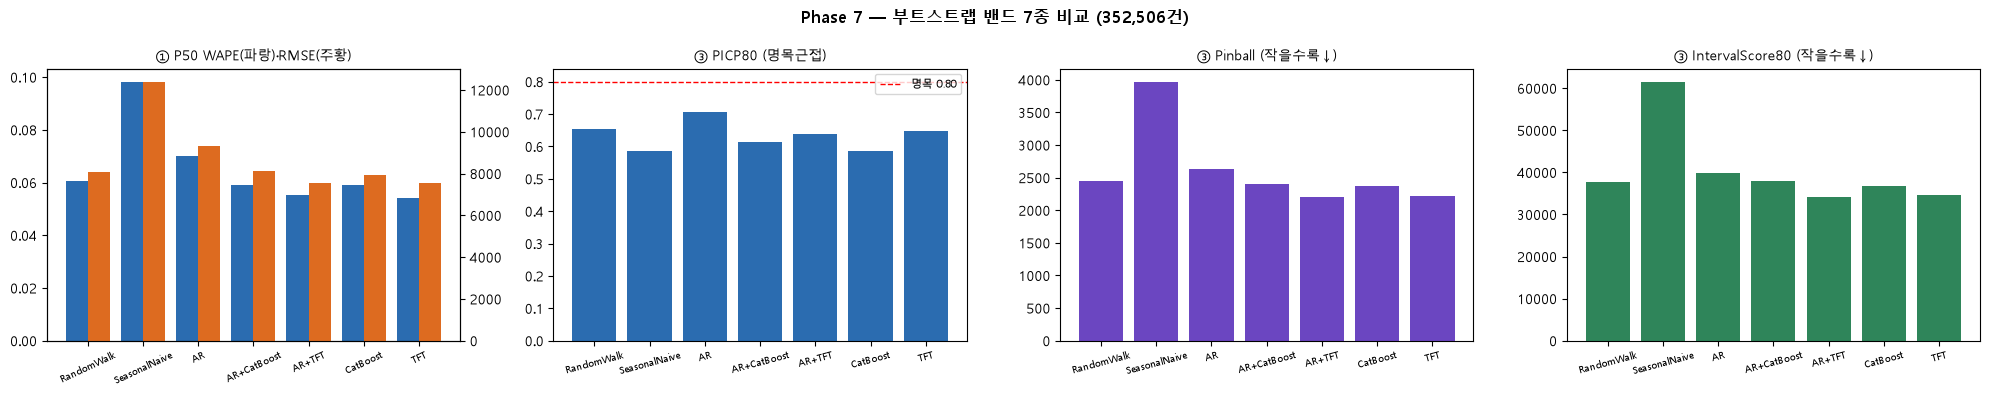

[phase7-B③] 비교 그래프 저장: C:\Users\equip\Desktop\homework\apartment_prediction2\ml_pipeline\final\output_final\bootstrap_compare


In [ ]:
# ===== Phase 7-B③. 폴드별 로그 취합 → 종합 요약·그래프 =====
# 저장된 윈도우별 CSV 만 읽어 합산하므로 메모리 부담 없이 언제든 재수행 가능.
def _safe_to_csv(df, path, **kw):
    """대상 파일이 Excel 등으로 잠겨 PermissionError 가 나면 타임스탬프 대체파일로 저장."""
    try:
        df.to_csv(path, **kw)
        return path
    except PermissionError:
        base, ext = os.path.splitext(path)
        alt = f"{base}__{time.strftime('%Y%m%d_%H%M%S')}{ext}"
        df.to_csv(alt, **kw)
        print(f"  [저장경고] '{os.path.basename(path)}' 잠김(열려있음) → 대체저장: {os.path.basename(alt)}")
        return alt

_parts = []
for w in BT_WINDOWS:
    _csv = os.path.join(_BOOT_DIR, f"per_analysis_band_metrics__{w['name']}.csv")
    if os.path.exists(_csv):
        _parts.append(pd.read_csv(_csv, encoding="utf-8-sig"))
    else:
        print(f"  [phase7-B③] 경고: {w['name']} 로그 없음 → Phase 7-B② 먼저 수행 필요")
boot_df = pd.concat(_parts, ignore_index=True)
_safe_to_csv(boot_df, os.path.join(_BOOT_DIR, "per_analysis_band_metrics.csv"), index=False, encoding="utf-8-sig")
print(f"[phase7-B③] 밴드 분석 {len(boot_df):,}건 취합 ({len(_parts)}/{len(BT_WINDOWS)} 윈도우)")

# ① P50 기준 RMSE·WAPE 평균 (윈도우별)
p50_win = boot_df.groupby(["모델", "윈도우"])[["WAPE_P50", "RMSE_P50"]].mean()
print("\n=== ① P50 기준 RMSE·WAPE 평균 (윈도우별) ===")
print(p50_win.to_string(float_format=lambda x: f"{x:,.4f}"))
_safe_to_csv(p50_win, os.path.join(_BOOT_DIR, "p50_metrics_by_window.csv"), encoding="utf-8-sig")

# ② 전체 시나리오 평균 + ③ 밴드지표 평균
_agg = dict(
    WAPE_P50=("WAPE_P50", "mean"), RMSE_P50=("RMSE_P50", "mean"),
    WAPE_시나리오평균=("WAPE_시나리오평균", "mean"), RMSE_시나리오평균=("RMSE_시나리오평균", "mean"),
    PICP80=("PICP80", "mean"), Pinball=("Pinball", "mean"),
    IntervalScore80=("IntervalScore80", "mean"),
    n_scen=("n_scen", "mean"), drop_pct=("drop%", "mean"))
# 상위 셀(7-B②)이 추가한 지표가 CSV에 있을 때만 집계(구버전 CSV 호환)
for _m in ["PICP100", "Pinball99", "IntervalScore99"]:
    if _m in boot_df.columns:
        _agg[_m] = (_m, "mean")
summary = boot_df.groupby("모델").agg(**_agg).reindex(MODELS_BOOT)
print("\n=== ②③ 모델별 종합 (P50 / 전체시나리오 / 밴드지표 평균) ===")
print(summary.to_string(float_format=lambda x: f"{x:,.4f}"))
_safe_to_csv(summary, os.path.join(_BOOT_DIR, "summary_by_model.csv"), encoding="utf-8-sig")

_log_txt = (f"[Phase 7] 부트스트랩 밴드 7종 — 전체 아파트×평형 × {len(BT_WINDOWS)}윈도우\n"
            f"분석×모델 {len(boot_df):,}건 | PICP 명목={1-ALPHA:.2f} | RW/SN산출={'정상' if _bl_ok else '폴백'}\n\n"
            + summary.round(4).to_string() + "\n")
try:
    with open(os.path.join(_BOOT_DIR, "summary.log"), "w", encoding="utf-8") as f:
        f.write(_log_txt)
except PermissionError:
    _alt = os.path.join(_BOOT_DIR, f"summary__{time.strftime('%Y%m%d_%H%M%S')}.log")
    with open(_alt, "w", encoding="utf-8") as f:
        f.write(_log_txt)
    print(f"  [저장경고] 'summary.log' 잠김 → 대체저장: {os.path.basename(_alt)}")
print(f"[phase7-B③] 요약 저장: {_BOOT_DIR}")

# 시각화: 모델별 (P50 WAPE/RMSE · PICP80 · Pinball · IntervalScore80 · PICP100 · Pinball99/IS99)
_has99 = all(_m in summary.columns for _m in ["PICP100", "Pinball99", "IntervalScore99"])
_ncol = 6 if _has99 else 4
fig, ax = plt.subplots(1, _ncol, figsize=(5 * _ncol, 4))
xb = np.arange(len(MODELS_BOOT))
axr = ax[0].twinx()
ax[0].bar(xb - 0.2, summary["WAPE_P50"], 0.4, color="#2b6cb0", label="WAPE")
axr.bar(xb + 0.2, summary["RMSE_P50"], 0.4, color="#dd6b20", label="RMSE")
ax[0].set_xticks(xb); ax[0].set_xticklabels(MODELS_BOOT, fontsize=7, rotation=25)
ax[0].set_title("① P50 WAPE(파랑)·RMSE(주황)", fontsize=10)
ax[1].bar(MODELS_BOOT, summary["PICP80"], color="#2b6cb0")
ax[1].axhline(1 - ALPHA, color="red", ls="--", lw=1, label=f"명목 {1-ALPHA:.2f}")
ax[1].set_title("③ PICP80 (명목근접)", fontsize=10); ax[1].legend(fontsize=8)
ax[1].tick_params(axis="x", labelsize=7, rotation=15)
ax[2].bar(MODELS_BOOT, summary["Pinball"], color="#6b46c1")
ax[2].set_title("③ Pinball (작을수록↓)", fontsize=10); ax[2].tick_params(axis="x", labelsize=7, rotation=15)
ax[3].bar(MODELS_BOOT, summary["IntervalScore80"], color="#2f855a")
ax[3].set_title("③ IntervalScore80 (작을수록↓)", fontsize=10); ax[3].tick_params(axis="x", labelsize=7, rotation=15)
if _has99:
    ax[4].bar(MODELS_BOOT, summary["PICP100"], color="#2b6cb0")
    ax[4].axhline(1.0, color="red", ls="--", lw=1, label="명목 1.00")
    ax[4].set_title("③ PICP100 (전체범위 커버리지)", fontsize=10); ax[4].legend(fontsize=8)
    ax[4].tick_params(axis="x", labelsize=7, rotation=15)
    axr5 = ax[5].twinx()
    ax[5].bar(xb - 0.2, summary["Pinball99"], 0.4, color="#6b46c1", label="Pinball99")
    axr5.bar(xb + 0.2, summary["IntervalScore99"], 0.4, color="#2f855a", label="IS99")
    ax[5].set_xticks(xb); ax[5].set_xticklabels(MODELS_BOOT, fontsize=7, rotation=25)
    ax[5].set_title("③ Pinball99(보라)·IS99(초록) ↓", fontsize=10)
fig.suptitle(f"Phase 7 — 부트스트랩 밴드 7종 비교 ({len(boot_df):,}건)", fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(_BOOT_DIR, "phase7_model_compare.png"), dpi=120, bbox_inches="tight")
plt.show()
print(f"[phase7-B③] 비교 그래프 저장: {_BOOT_DIR}")


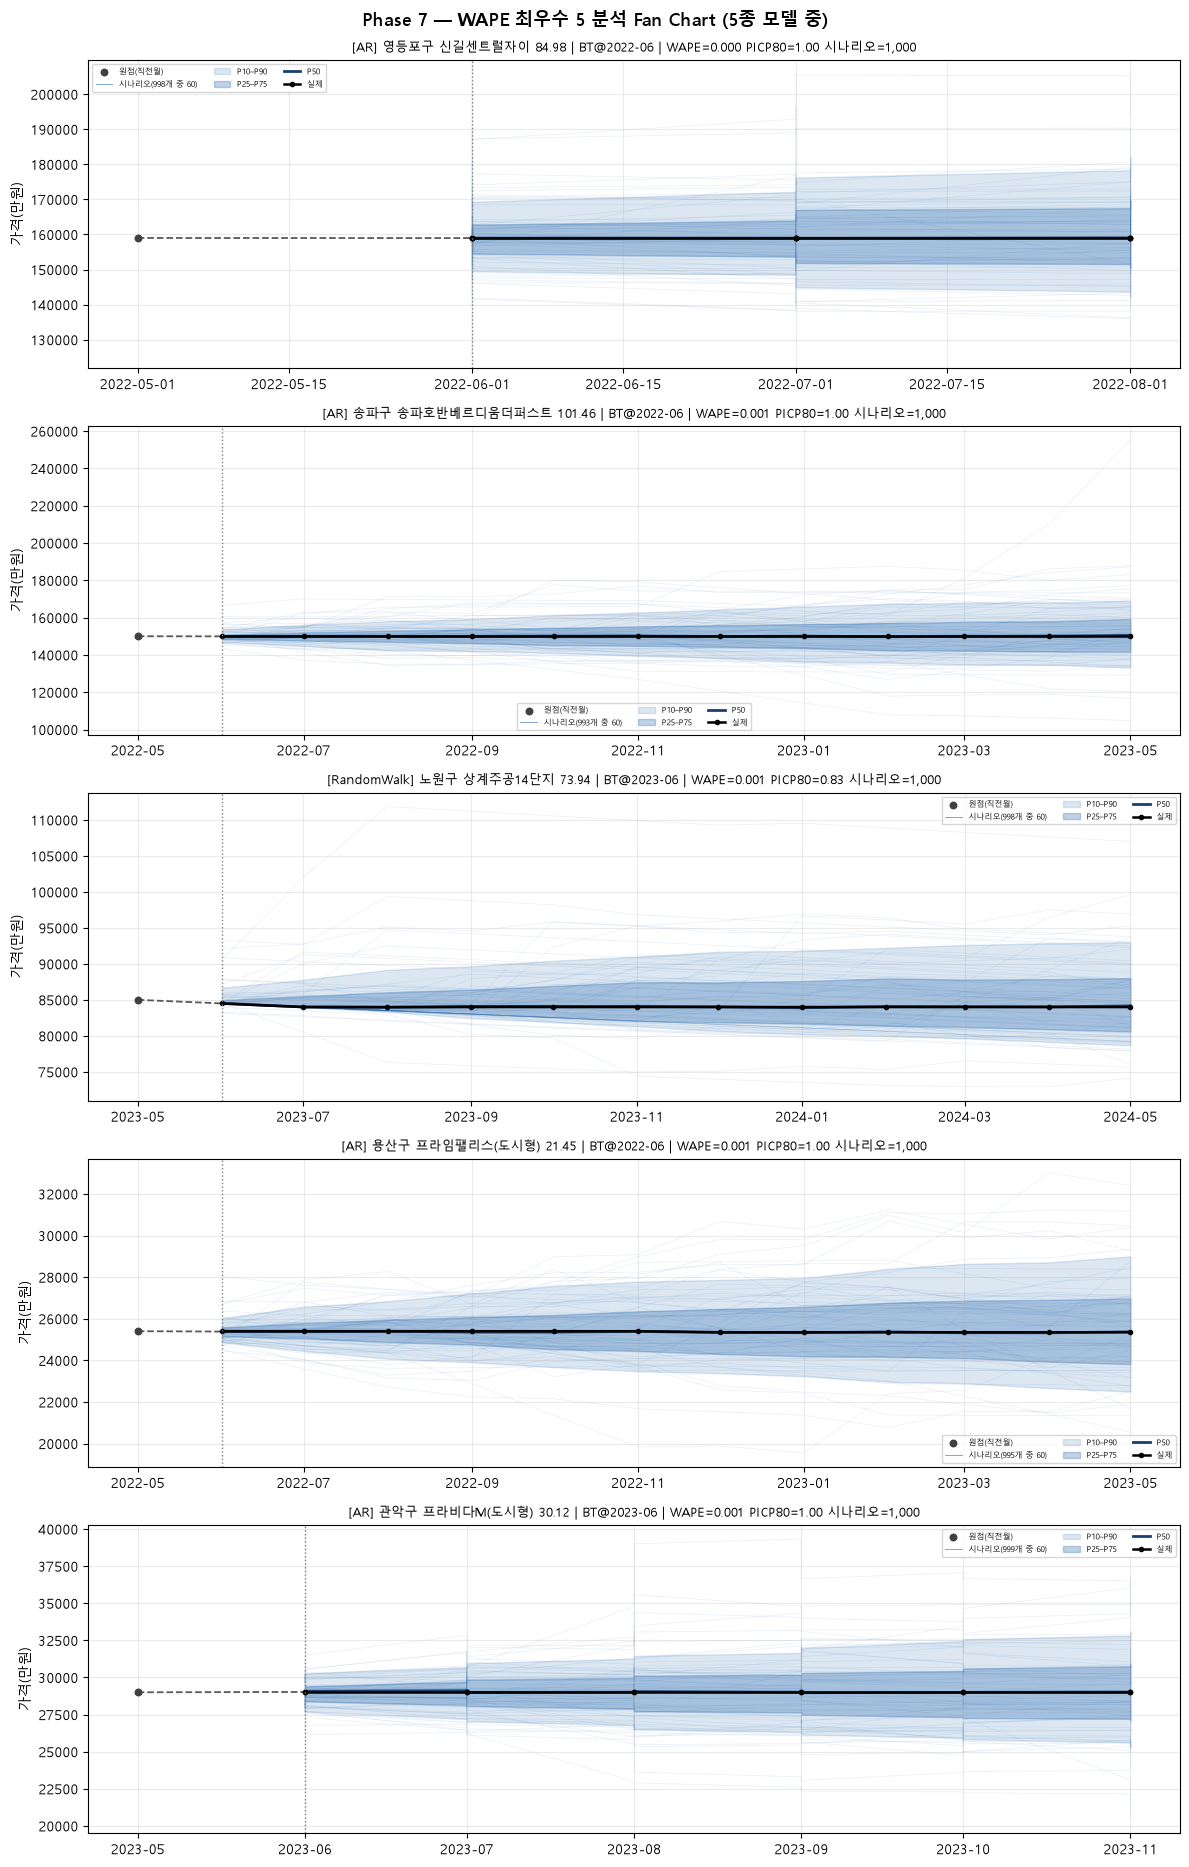

[phase7-C] WAPE 최우수 5 Fan Chart 저장: C:\Users\equip\Desktop\homework\apartment_prediction2\ml_pipeline\final\output_final\bootstrap_compare\fanchart_best5.png


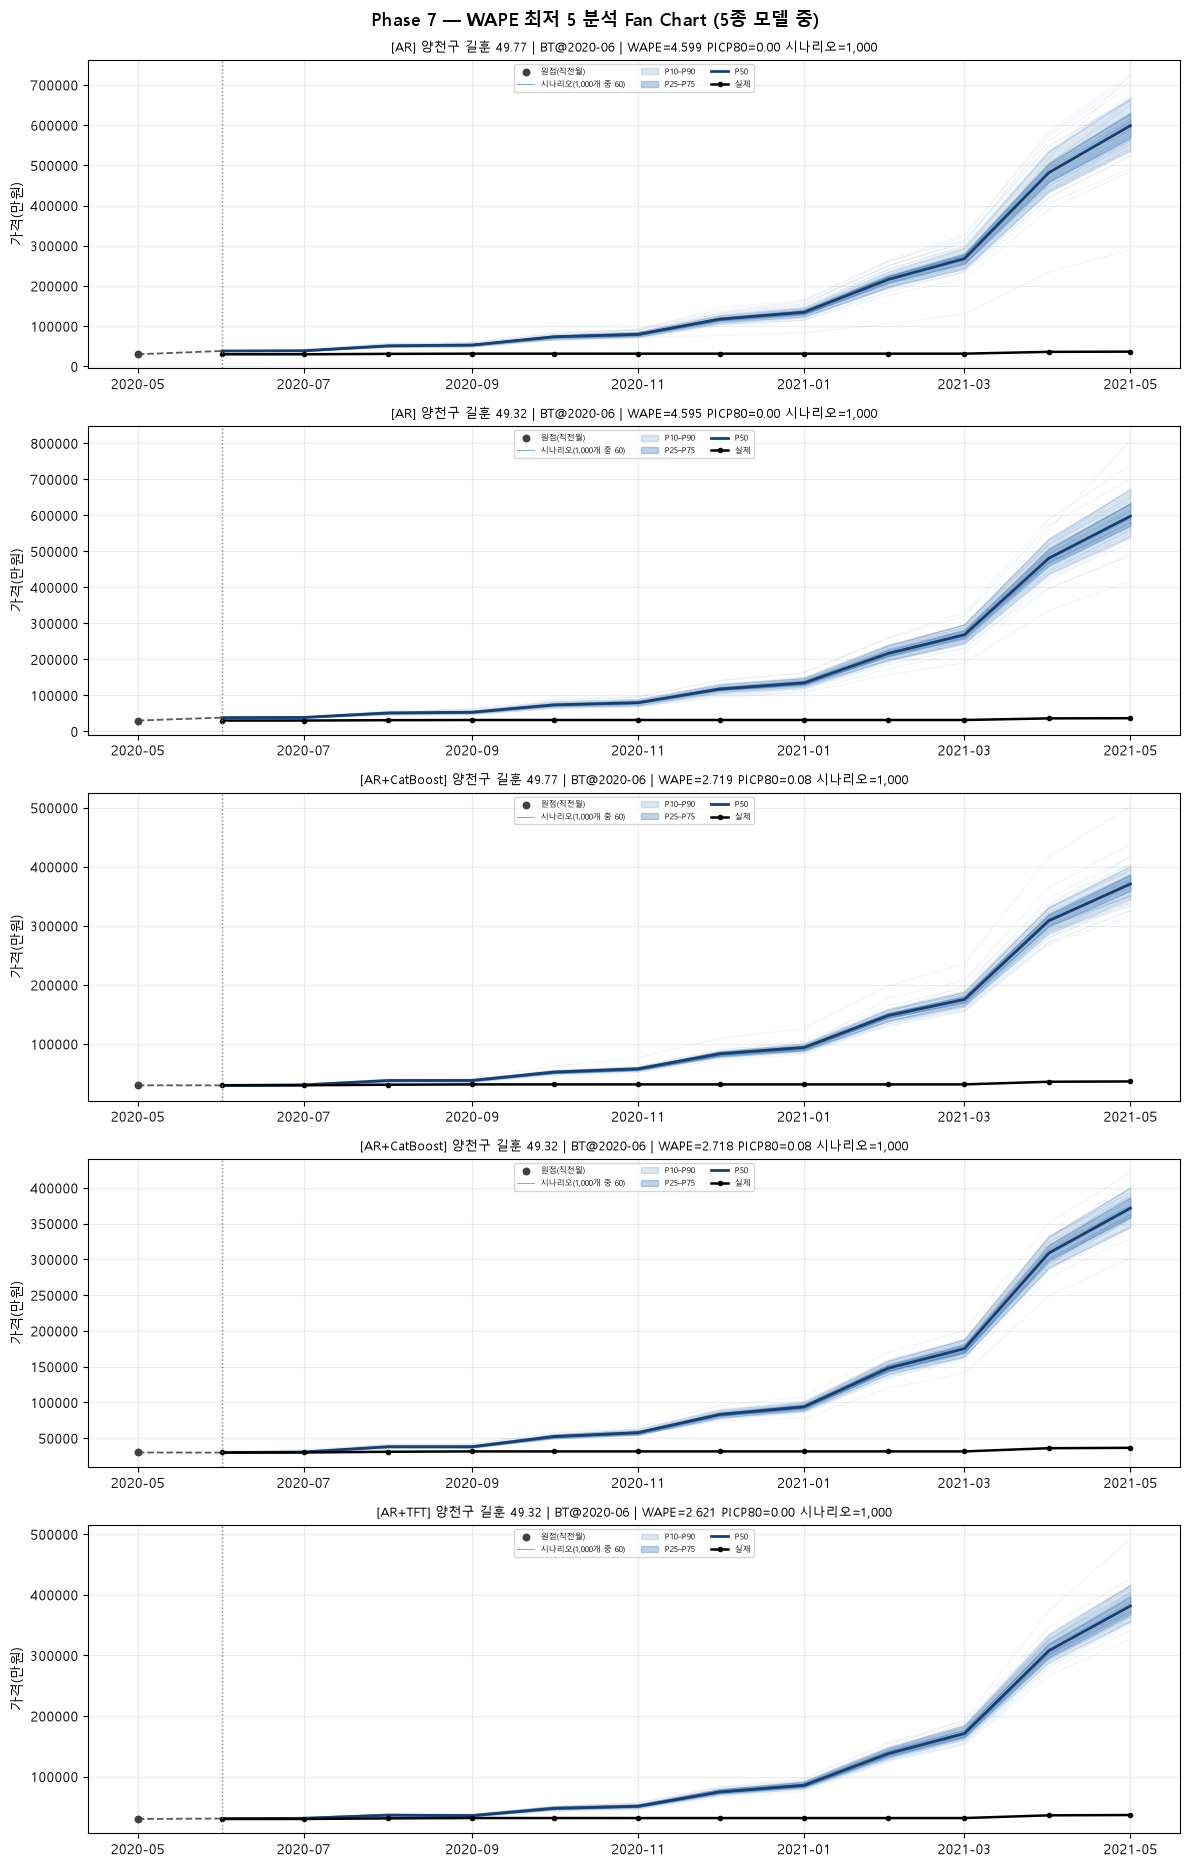

[phase7-C] WAPE 최저 5 Fan Chart 저장: C:\Users\equip\Desktop\homework\apartment_prediction2\ml_pipeline\final\output_final\bootstrap_compare\fanchart_worst5.png
[phase7-C] 최우수/최저 5 메타 저장: C:\Users\equip\Desktop\homework\apartment_prediction2\ml_pipeline\final\output_final\bootstrap_compare


In [ ]:
# ===== Phase 7-C. WAPE 최우수 5 / 최저 5 분석 Fan Chart (panel 미접근) =====
# 팬차트 레코드는 boot_df(취합본)의 (모델/윈도우/단지) 로 WIN_ITEMS 에서 재구성 → ANALYSES 불필요(메모리↓).
FAN_QS = [0.1, 0.25, 0.5, 0.75, 0.9]
_fan_rng = np.random.default_rng(CFG.BOOTSTRAP_SEED + 707)
_item_lut = {(w["name"], it["단지"]): it for w in BT_WINDOWS for it in WIN_ITEMS[w["name"]]}

_order = boot_df["WAPE_P50"].values
_best_idx = list(np.argsort(_order)[:5])               # WAPE 최소 = 최우수
_worst_idx = list(np.argsort(_order)[::-1][:5])        # WAPE 최대 = 최저


def _rebuild_record(row):
    """boot_df 한 행 → 팬차트용 레코드(point_log/origin_log/seed/dates/y) 재구성."""
    wn = row["윈도우"]; gid = row["단지"]; mdl = row["모델"]
    it = _item_lut[(wn, gid)]
    plog = np.asarray(build_point_logs(wn, it)[mdl], float)
    return {"모델": mdl, "윈도우": wn, "단지": gid,
            "point_log": plog, "origin_log": it["last"],
            "seed": _seed_for(mdl, gid, wn), "dates": it["dates"], "y": it["yte"]}


def _draw_fan(ax, rec, b, title):
    x = pd.to_datetime(rec["dates"]); y = rec["y"]
    ens = b["ensemble"]; qmap = b["q"]
    # 원점(직전월) 앵커 — panel 조회 없이 it["last"](로그) 로 복원
    anchor_x = x[0] - pd.DateOffset(months=1)
    anchor_y = float(np.exp(rec["origin_log"])) if CFG.LOG_TARGET else float(rec["origin_log"])
    ax.plot([anchor_x, x[0]], [anchor_y, qmap[0.5][0]], color="0.35", lw=1.3, ls="--")
    ax.scatter([anchor_x], [anchor_y], color="0.25", s=22, zorder=5, label="원점(직전월)")
    m_show = min(60, ens.shape[0])
    sel = _fan_rng.choice(ens.shape[0], m_show, replace=False)
    ax.plot(x, ens[sel].T, color="#2b6cb0", lw=0.5, alpha=0.10)
    ax.plot([], [], color="#2b6cb0", lw=0.7, alpha=0.6, label=f"시나리오({ens.shape[0]:,}개 중 {m_show})")
    for (lo, hi), al in zip([(0.1, 0.9), (0.25, 0.75)], [0.16, 0.30]):
        ax.fill_between(x, qmap[lo], qmap[hi], color="#2b6cb0", alpha=al,
                        label=f"P{int(lo*100)}–P{int(hi*100)}")
    ax.plot(x, qmap[0.5], color="#1a3e6e", lw=2.0, label="P50")
    ax.plot(x, y, color="black", lw=1.8, marker="o", ms=3.0, label="실제")
    ax.axvline(x[0], color="gray", ls=":", lw=1.0)
    ax.set_title(title, fontsize=9)
    ax.set_ylabel("가격(만원)"); ax.grid(alpha=0.25); ax.legend(fontsize=6, ncol=3, loc="best")


for tag, idxs, label in [("best", _best_idx, "WAPE 최우수 5"), ("worst", _worst_idx, "WAPE 최저 5")]:
    fig, axes = plt.subplots(len(idxs), 1, figsize=(12, 3.8 * len(idxs)))
    if len(idxs) == 1:
        axes = [axes]
    for ax, ridx in zip(axes, idxs):
        row = boot_df.iloc[ridx]
        rec = _rebuild_record(row)
        b = make_bands(rec["point_log"], POOLS[rec["윈도우"]][rec["모델"]],
                       origin_log=rec["origin_log"], seed_offset=rec["seed"], quantiles=FAN_QS)
        kv = rec["단지"].split("|")
        ttl = (f"[{rec['모델']}] {kv[0]} {kv[2] if len(kv)>2 else ''} {kv[-1]} | {rec['윈도우']} | "
               f"WAPE={row['WAPE_P50']:.3f} PICP80={row['PICP80']:.2f} 시나리오={int(row['n_scen']):,}")
        _draw_fan(ax, rec, b, ttl)
    fig.suptitle(f"Phase 7 — {label} 분석 Fan Chart (5종 모델 중)", fontsize=13, fontweight="bold")
    plt.tight_layout(rect=[0, 0, 1, 0.99])
    _png = os.path.join(_BOOT_DIR, f"fanchart_{tag}5.png")
    plt.savefig(_png, dpi=120, bbox_inches="tight")
    plt.show()
    print(f"[phase7-C] {label} Fan Chart 저장: {_png}")

# 최우수/최저 분석 메타 저장
pd.concat([
    boot_df.iloc[_best_idx].assign(구분="best"),
    boot_df.iloc[_worst_idx].assign(구분="worst"),
]).to_csv(os.path.join(_BOOT_DIR, "best_worst5_analyses.csv"), index=False, encoding="utf-8-sig")
print(f"[phase7-C] 최우수/최저 5 메타 저장: {_BOOT_DIR}")


## Phase 8 — 순수 TFT VSN (저장된 .pt 캐시에서 재학습 없이 추출)

Phase 6-B 의 VSN은 **AR+TFT(잔차 보정)** 모델 기준이다. 여기서는 **순수 TFT**(`pure_target` = 원점 대비 로그성장을 직접 학습) 모델의
Variable Selection Network 가중치를 **저장된 `pure_tft_*.pt` 캐시**에서 로드해 추출한다.

- **재학습 없음**: `load_tft_pure()` 로 동일 데이터셋 구조를 재현 후 가중치만 로드 → `interpret_output()` 추론 1회.
- 5개 백테스트 윈도우 각각에 대해 encoder/decoder/static VSN 가중치를 산출하고, decoder(미래 horizon 예측에 영향을 준 known reals)를 종합한다.
- 산출물은 `output_final/vsn_tft_pure/` 에 저장(기존 AR+TFT VSN 결과 `vsn_tft/` 와 분리).


GPU available: False, used: False


[tft-pure] BT@2025-06 캐시 로드 series=1,500: pure_tft_AR_BT@2025-06.pt


TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


[phase8] BT@2025-06 순수TFT decoder 상위: h_step(0.19), depth3__policy__ltv_tightness(0.12), depth2__reb__apt_sale_supply_demand(0.07), origin_last(0.06), origin_mom6(0.05)


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


...

[tft-pure] BT@2023-06 캐시 로드 series=1,500: pure_tft_AR_BT@2023-06.pt
[phase8] BT@2023-06 순수TFT decoder 상위: h_step(0.21), origin_mom6(0.08), depth3__policy__is_overheated(0.08), depth1__ecos__cd_91d_rate(0.06), depth2__reb__apt_sale_supply_demand(0.06)


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


[tft-pure] BT@2022-06 캐시 로드 series=1,500: pure_tft_AR_BT@2022-06.pt
[phase8] BT@2022-06 순수TFT decoder 상위: h_step(0.25), depth1__ecos__m2_avg(0.10), depth2__reb__apt_monthly_rent_supply_demand(0.09), depth2__reb__apt_jeonse_supply_demand(0.08), depth3__policy__is_overheated(0.05)


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


[tft-pure] BT@2021-06 캐시 로드 series=1,500: pure_tft_AR_BT@2021-06.pt
[phase8] BT@2021-06 순수TFT decoder 상위: h_step(0.16), depth1__ecos__base_rate(0.13), depth2__reb__apt_jeonse_supply_demand(0.12), depth2__reb__apt_sale_supply_demand(0.06), origin_last(0.05)


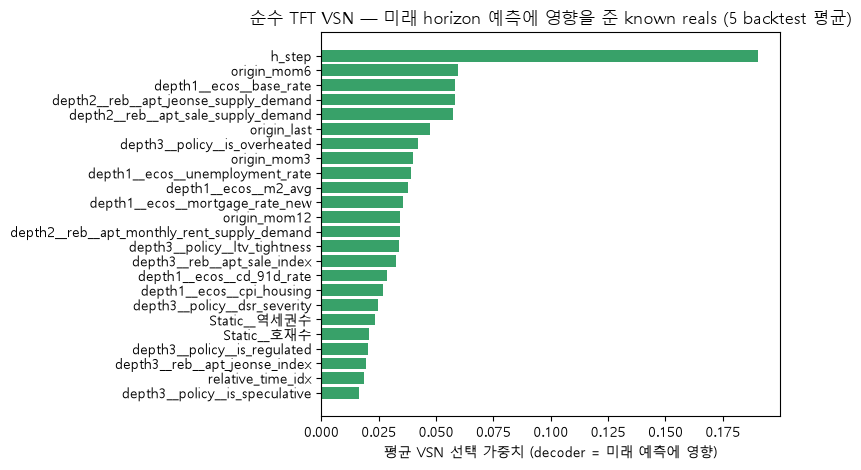


[phase8] 순수 TFT VSN 저장: C:\Users\equip\Desktop\homework\apartment_prediction2\ml_pipeline\final\output_final\vsn_tft_pure
                                         변수  선택가중치
                                     h_step 0.1904
                                origin_mom6 0.0594
                    depth1__ecos__base_rate 0.0581
      depth2__reb__apt_jeonse_supply_demand 0.0581
        depth2__reb__apt_sale_supply_demand 0.0572
                                origin_last 0.0473
              depth3__policy__is_overheated 0.0422
                                origin_mom3 0.0400
            depth1__ecos__unemployment_rate 0.0392
                       depth1__ecos__m2_avg 0.0380
            depth1__ecos__mortgage_rate_new 0.0356
                               origin_mom12 0.0345
depth2__reb__apt_monthly_rent_supply_demand 0.0343
              depth3__policy__ltv_tightness 0.0338
                depth3__reb__apt_sale_index 0.0324
                  depth1__ecos__cd_91d_rate 0.0286
          

In [35]:
# ===== Phase 8. 순수 TFT VSN — 저장된 pure_tft_*.pt 캐시에서 재학습 없이 추출 =====
# AR+TFT(잔차보정) VSN(Phase 6-B)과 별개로, "순수 TFT"(원점대비 로그성장 직접학습) 모델의
# Variable Selection Network 가중치를 캐시 가중치에서 로드해 추출한다(재학습 없음 · 추론 1회).
import gc

_VSN_PURE_DIR = log_dir("vsn_tft_pure")
_bstar_tag = B_STAR.replace("-", "").replace("/", "")
_PTFT_DIR = log_dir(f"{_bstar_tag}_tft")


def _vsn_weights_pure(interp, key, names):
    """interpret_output 결과 → 변수 선택 가중치(합=1 정규화). 길이 불일치 시 generic 이름 폴백."""
    v = np.asarray(interp[key].detach().cpu().numpy(), dtype=float).ravel()
    names = list(names)
    if len(v) != len(names):
        names = [f"var_{i}" for i in range(len(v))]
    s = v.sum()
    return names, (v / s if s > 0 else v)


_vsn_pure_dec_frames = []
for w in BT_WINDOWS:
    wn = w["name"]
    _path = os.path.join(_PTFT_DIR, f"pure_tft_{_bstar_tag}_{wn}.pt")
    if not os.path.exists(_path):
        print(f"[phase8] {wn} 순수 TFT 캐시 없음 → 건너뜀: {os.path.basename(_path)}")
        continue
    model_p = tds_p = None
    try:
        model_p, tds_p = load_tft_pure(WIN_TRAINSETS[wn], wn, _path)   # 재학습 없이 가중치 로드
        model_p.eval()
        dl = tds_p.to_dataloader(train=False, batch_size=CFG.TFT_BATCH, num_workers=0)
        raw = model_p.predict(dl, mode="raw", return_x=True)
        interp = model_p.interpret_output(raw.output, reduction="sum")
        for key, mnames in [("encoder_variables", model_p.encoder_variables),
                            ("decoder_variables", model_p.decoder_variables),
                            ("static_variables", model_p.static_variables)]:
            nm, wt = _vsn_weights_pure(interp, key, mnames)
            dfk = pd.DataFrame({"윈도우": wn, "구분": key, "변수": nm, "선택가중치": wt})
            dfk = dfk.sort_values("선택가중치", ascending=False).reset_index(drop=True)
            dfk.to_csv(os.path.join(_VSN_PURE_DIR, f"vsn_pure_{key}_{wn}.csv"),
                       index=False, encoding="utf-8-sig")
            if key == "decoder_variables":
                _vsn_pure_dec_frames.append(dfk)
        top = _vsn_pure_dec_frames[-1].head(5)
        print(f"[phase8] {wn} 순수TFT decoder 상위: " +
              ", ".join(f"{r['변수']}({r['선택가중치']:.2f})" for _, r in top.iterrows()))
    except Exception as e:
        print(f"[phase8] {wn} 순수 TFT VSN 추출 실패: {type(e).__name__}: {e}")
    finally:
        del model_p, tds_p
        gc.collect()

# ---- 5개 윈도우 decoder 종합(미래 horizon 예측에 영향을 준 known reals) ----
if _vsn_pure_dec_frames:
    vsn_pure_dec = pd.concat(_vsn_pure_dec_frames, ignore_index=True)
    vsn_pure_dec_summary = (vsn_pure_dec.groupby("변수")["선택가중치"].mean()
                            .reset_index().sort_values("선택가중치", ascending=False)
                            .reset_index(drop=True))
    vsn_pure_dec_summary.to_csv(os.path.join(_VSN_PURE_DIR, "vsn_pure_decoder_summary_allwindows.csv"),
                                index=False, encoding="utf-8-sig")
    top = vsn_pure_dec_summary.iloc[::-1]
    plt.figure(figsize=(8, 4.8))
    plt.barh(top["변수"], top["선택가중치"], color="#38a169")
    plt.xlabel("평균 VSN 선택 가중치 (decoder = 미래 예측에 영향)")
    plt.title("순수 TFT VSN — 미래 horizon 예측에 영향을 준 known reals (5 backtest 평균)")
    plt.tight_layout()
    plt.savefig(os.path.join(_VSN_PURE_DIR, "vsn_pure_decoder_top.png"), dpi=120, bbox_inches="tight")
    plt.show()
    print(f"\n[phase8] 순수 TFT VSN 저장: {_VSN_PURE_DIR}")
    print(vsn_pure_dec_summary.to_string(index=False, float_format=lambda x: f"{x:,.4f}"))
else:
    vsn_pure_dec_summary = pd.DataFrame(columns=["변수", "선택가중치"])
    print("[phase8] 순수 TFT VSN 추출 결과 없음 (pure_tft_*.pt 캐시 확인 필요)")


## Phase 9 — 순수 TFT baseline (bootstrap 통과 전 점예측) 저장

부트스트랩 밴드를 적용하기 **이전**의 순수 TFT 점예측(가격공간)을 캐시에서 추출해 저장한다.
- 데이터 출처: `WIN_ITEMS[wn][i]["pred_pureTFT"]` — Phase 4.5-A 가 캐시된 `pure_tft_*.pt` 로 산출한 점예측(재학습 없음).
- 산출물: `output_final/pure_tft_baseline/` 에 long-format CSV + 재사용용 pickle.


In [ ]:
# ===== Phase 9. 순수 TFT baseline(부트스트랩 전 점예측) 캐시 추출·저장 =====
# WIN_ITEMS 에 이미 적재된 순수 TFT 점예측(pred_pureTFT, 가격공간)을 그대로 저장한다(재학습/재추론 없음).
#  · pred_pureTFT 는 Phase 4.5-A 가 캐시(pure_tft_*.pt)로 산출한 '원점대비 로그성장 직접예측'의 가격복원값.
#  · 이 값이 곧 '부트스트랩 밴드 적용 이전'의 순수 TFT baseline(점예측)이다.
import pickle as _pickle

_PTFT_BL_DIR = log_dir("pure_tft_baseline")
H = CFG.HORIZON

_rows = []
_point = {}                                   # {(윈도우, 단지): pred_pureTFT(H,)} — 프로그램 재사용용
_n_items = _n_have = 0
for w in BT_WINDOWS:
    wn = w["name"]
    for it in WIN_ITEMS.get(wn, []):
        _n_items += 1
        pred = it.get("pred_pureTFT")
        if pred is None:
            continue
        pred = np.asarray(pred, float).ravel()
        if pred.size != H or not np.all(np.isfinite(pred)):
            continue
        _n_have += 1
        gid = it["단지"]
        _point[(wn, gid)] = pred
        parts = gid.split("|")
        gu, dong, danji, pyung = (parts + ["", "", "", ""])[:4]
        yte = np.asarray(it.get("yte", [np.nan] * H), float).ravel()
        dates = pd.to_datetime(it.get("dates", pd.NaT))
        base_price = np.asarray(it.get("before_price", [np.nan] * H), float).ravel()
        for h in range(H):
            _rows.append({
                "윈도우": wn, "구": gu, "동": dong, "단지명": danji, "평형": pyung, "단지": gid,
                "h_step": h + 1,
                "예측월": (dates[h] if h < len(dates) else pd.NaT),
                "순수TFT_baseline가": pred[h],
                "실제가": (yte[h] if h < len(yte) else np.nan),
                "AR기준가": (base_price[h] if h < len(base_price) else np.nan),
            })

pure_tft_baseline = pd.DataFrame(_rows)
_long_path = os.path.join(_PTFT_BL_DIR, "pure_tft_baseline_long.csv")
pure_tft_baseline.to_csv(_long_path, index=False, encoding="utf-8-sig")
with open(os.path.join(_PTFT_BL_DIR, "pure_tft_baseline_point.pkl"), "wb") as f:
    _pickle.dump(_point, f)

# 윈도우별 요약(케이스 수 + 실제가 대비 WAPE) ----------------------------------
_sum_rows = []
for wn, sub in pure_tft_baseline.groupby("윈도우", sort=False):
    _v = sub.dropna(subset=["실제가"])
    _wape = (np.abs(_v["실제가"] - _v["순수TFT_baseline가"]).sum() / np.abs(_v["실제가"]).sum()
             if len(_v) and np.abs(_v["실제가"]).sum() > 0 else np.nan)
    _sum_rows.append({"윈도우": wn, "분석케이스": sub["단지"].nunique(),
                      "행수(케이스×H)": len(sub), "baseline_WAPE": _wape})
pure_tft_baseline_summary = pd.DataFrame(_sum_rows)
pure_tft_baseline_summary.to_csv(os.path.join(_PTFT_BL_DIR, "pure_tft_baseline_summary.csv"),
                                 index=False, encoding="utf-8-sig")

print(f"[phase9] 순수 TFT baseline 추출(재학습 없음): 케이스 {_n_have:,}/{_n_items:,} "
      f"(점예측 {len(_point):,}건 · 행 {len(pure_tft_baseline):,})")
print(f"[phase9] 저장: {_PTFT_BL_DIR}")
print("  - pure_tft_baseline_long.csv   (윈도우×단지×h 점예측)")
print("  - pure_tft_baseline_point.pkl  ({(윈도우,단지): 점예측(H,)})")
print("  - pure_tft_baseline_summary.csv")
print()
print(pure_tft_baseline_summary.to_string(index=False, float_format=lambda x: f"{x:,.4f}"))
